In [1]:
# ============================================================
# CANADIAN INDUSTRY ROTATION
# Building an Employment-Based Portfolio Strategy
# ============================================================

print("Canadian Industry Rotation")
print("Employment-Based Portfolio Strategy")

Canadian Industry Rotation
Employment-Based Portfolio Strategy


In [2]:
# ============================================================
# INTRODUCTION
# ============================================================

print("""
This project investigates whether changes in Canadian industry
employment can be used to identify industry strength, economic
rotation, and potential portfolio allocation signals.

The analysis uses monthly Canadian employment data covering
1987 to 2026 across major industries.

Our objective is to move beyond descriptive employment analysis
and develop a systematic framework that:

1. Measures industry strength and momentum
2. Detects changes in economic conditions
3. Identifies industry rotation
4. Creates an employment-based portfolio strategy
5. Tests the strategy historically
6. Investigates whether employment changes can provide
   early signals of industry turning points

Main research question:

Can employment dynamics help identify which Canadian industries
are becoming stronger or weaker before the change becomes obvious?
""")


This project investigates whether changes in Canadian industry
employment can be used to identify industry strength, economic
rotation, and potential portfolio allocation signals.

The analysis uses monthly Canadian employment data covering
1987 to 2026 across major industries.

Our objective is to move beyond descriptive employment analysis
and develop a systematic framework that:

1. Measures industry strength and momentum
2. Detects changes in economic conditions
3. Identifies industry rotation
4. Creates an employment-based portfolio strategy
5. Tests the strategy historically
6. Investigates whether employment changes can provide
   early signals of industry turning points

Main research question:

Can employment dynamics help identify which Canadian industries
are becoming stronger or weaker before the change becomes obvious?



In [4]:
# ============================================================
# RESEARCH HYPOTHESIS
# ============================================================

print("RESEARCH HYPOTHESIS")
print("=" * 60)

print("""
H0 (Null Hypothesis):
Changes in Canadian industry employment do not provide
useful information for systematically ranking industries
or constructing a portfolio strategy.

H1 (Alternative Hypothesis):
Changes in Canadian industry employment contain useful
information that can be used to rank industries, identify
industry rotation, and construct a systematic portfolio strategy.

Research Objective:
Develop an employment-based Industry Strength Score and
evaluate whether it can generate meaningful industry
rotation signals.
""")

RESEARCH HYPOTHESIS

H0 (Null Hypothesis):
Changes in Canadian industry employment do not provide
useful information for systematically ranking industries
or constructing a portfolio strategy.

H1 (Alternative Hypothesis):
Changes in Canadian industry employment contain useful
information that can be used to rank industries, identify
industry rotation, and construct a systematic portfolio strategy.

Research Objective:
Develop an employment-based Industry Strength Score and
evaluate whether it can generate meaningful industry
rotation signals.



In [26]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

print("Libraries imported successfully.")

Libraries imported successfully.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Python is ready!")

Python is ready!


In [28]:

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("14100291.csv")

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset loaded successfully.
Rows: 109200
Columns: 17


In [29]:
# ============================================================
# INITIAL DATASET INSPECTION
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109200 entries, 0 to 109199
Data columns (total 17 columns):
 #   Column                                                 Non-Null Count   Dtype  
---  ------                                                 --------------   -----  
 0   REF_DATE                                               109200 non-null  object 
 1   GEO                                                    109200 non-null  object 
 2   DGUID                                                  109200 non-null  object 
 3   Labour force characteristics                           109200 non-null  object 
 4   North American Industry Classification System (NAICS)  109200 non-null  object 
 5   Statistics                                             109200 non-null  object 
 6   UOM                                                    109200 non-null  object 
 7   UOM_ID                                                 109200 non-null  int64  
 8   SCALAR_FACTOR                     

In [15]:
# ============================================================
# DATASET PREVIEW
# ============================================================

display(df.head())

,REF_DATE,GEO,DGUID,Labour force characteristics,North American Industry Classification System (NAICS),Statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1987-01,Canada,2021A000011124,Labour force,"Total, all industries",Estimate,Persons in thousands,428,thousands,3,v13682054,1.1.1.1,13376.2,NaN,NaN,NaN,1
1,1987-01,Canada,2021A000011124,Labour force,Goods-producing sector,Estimate,Persons in thousands,428,thousands,3,v13682055,1.1.2.1,3915.3,NaN,NaN,NaN,1
2,1987-01,Canada,2021A000011124,Labour force,"Agriculture [111-112, 1100, 1151-1152]",Estimate,Persons in thousands,428,thousands,3,v13682056,1.1.3.1,495.9,NaN,NaN,NaN,1
3,1987-01,Canada,2021A000011124,Labour force,"Forestry, fishing, mining, quarrying, oil and ...",Estimate,Persons in thousands,428,thousands,3,v13682057,1.1.4.1,326.2,NaN,NaN,NaN,1
4,1987-01,Canada,2021A000011124,Labour force,Utilities [22],Estimate,Persons in thousands,428,thousands,3,v13682058,1.1.5.1,116.9,NaN,NaN,NaN,1


In [16]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
REF_DATE,109200,476,2026-08,312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEO,109200,1,Canada,109200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DGUID,109200,1,2021A000011124,109200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Labour force characteristics,109200,4,Labour force,28000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
North American Industry Classification System (NAICS),109200,20,"Total, all industries",5600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Statistics,109200,4,Estimate,37128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UOM,109200,2,Persons in thousands,82600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UOM_ID,109200.0,NaN,NaN,NaN,381.961538,81.128229,239.0,428.0,428.0,428.0,428.0
SCALAR_FACTOR,109200,2,thousands,82600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCALAR_ID,109200.0,NaN,NaN,NaN,2.269231,1.28775,0.0,3.0,3.0,3.0,3.0


In [17]:
# ============================================================
# CONVERT DATE COLUMN
# ============================================================

df["Date"] = pd.to_datetime(df["REF_DATE"] + "-01")

print("Date conversion complete.")
print("Start:", df["Date"].min())
print("End:", df["Date"].max())

Date conversion complete.
Start: 1987-01-01 00:00:00
End: 2026-08-01 00:00:00


In [18]:
# ============================================================
# CREATE EMPLOYMENT DATASET
# ============================================================

employment = df[
    df["Labour force characteristics"] == "Employment"
].copy()

employment = employment.sort_values("Date")

print("Employment dataset created.")
print("Rows:", employment.shape[0])
print("Columns:", employment.shape[1])

Employment dataset created.
Rows: 26600
Columns: 18


In [19]:
# ============================================================
# KEEP ONLY EMPLOYMENT ESTIMATES
# ============================================================

employment_est = employment[
    employment["Statistics"] == "Estimate"
].copy()

print("Employment estimate dataset created.")
print("Rows:", employment_est.shape[0])
print("Unique statistics:", employment_est["Statistics"].unique())

Employment estimate dataset created.
Rows: 9044
Unique statistics: ['Estimate']


In [20]:
# ============================================================
# CHECK INDUSTRY CATEGORIES
# ============================================================

industries = employment_est["North American Industry Classification System (NAICS)"].unique()

print("Number of industry categories:", len(industries))
print("\nIndustry categories:")
for industry in industries:
    print("-", industry)

Number of industry categories: 19

Industry categories:
- Total, all industries
- Public administration [91]
- Other services (except public administration) [81]
- Accommodation and food services [72]
- Information, culture and recreation [51, 71]
- Health care and social assistance [62]
- Business, building and other support services [55-56]
- Professional, scientific and technical services [54]
- Finance, insurance, real estate, rental and leasing [52-53]
- Educational services [61]
- Wholesale and retail trade [41, 44-45]
- Transportation and warehousing [48-49]
- Agriculture [111-112, 1100, 1151-1152]
- Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]
- Utilities [22]
- Goods-producing sector
- Manufacturing [31-33]
- Services-producing sector
- Construction [23]


In [21]:
# ============================================================
# KEEP ONLY INDIVIDUAL INDUSTRIES
# ============================================================

aggregate_industries = [
    "Total, all industries",
    "Goods-producing sector",
    "Services-producing sector"
]

industry_data = employment_est[
    ~employment_est[
        "North American Industry Classification System (NAICS)"
    ].isin(aggregate_industries)
].copy()

print("Industry dataset created.")
print("Rows:", industry_data.shape[0])
print(
    "Number of industries:",
    industry_data[
        "North American Industry Classification System (NAICS)"
    ].nunique()
)

Industry dataset created.
Rows: 7616
Number of industries: 16


In [22]:
# ============================================================
# CREATE INDUSTRY-BY-MONTH EMPLOYMENT MATRIX
# ============================================================

industry_col = "North American Industry Classification System (NAICS)"

industry_matrix = industry_data.pivot_table(
    index="Date",
    columns=industry_col,
    values="VALUE",
    aggfunc="first"
)

industry_matrix = industry_matrix.sort_index()

print("Industry matrix created.")
print("Rows (months):", industry_matrix.shape[0])
print("Columns (industries):", industry_matrix.shape[1])

display(industry_matrix.head())

Industry matrix created.
Rows (months): 476
Columns (industries): 16


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
1987-01-01,718.3,464.0,266.2,685.6,756.3,750.3,285.4,1120.1,516.5,2002.8,634.6,464.2,761.8,623.3,113.4,1939.2
1987-02-01,714.5,462.4,279.9,694.8,760.2,745.5,284.8,1126.0,505.8,2002.1,640.8,471.8,770.0,615.2,112.9,1944.6
1987-03-01,726.6,464.2,280.7,704.4,758.7,752.0,281.8,1128.1,505.7,2017.8,636.5,475.1,766.0,623.6,113.3,1947.5
1987-04-01,728.6,464.2,278.8,710.3,755.0,757.5,284.0,1140.2,506.8,2020.6,638.3,480.9,765.0,626.8,114.2,1958.3
1987-05-01,725.6,465.9,276.7,718.4,767.5,762.1,283.5,1137.7,510.4,2049.5,628.7,487.1,760.8,625.4,113.4,1972.9


In [23]:
# ============================================================
# CALCULATE 12-MONTH EMPLOYMENT GROWTH
# ============================================================

growth_12m = industry_matrix.pct_change(periods=12) * 100

print("12-month employment growth calculated.")
print("Shape:", growth_12m.shape)

display(growth_12m.tail())

12-month employment growth calculated.
Shape: (476, 16)


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,0.290872,0.216263,-0.999714,-1.312656,-1.604044,-0.912078,3.264450,4.132404,0.659833,-1.078608,0.321750,-0.194766,-1.517047,0.479616,10.516252,0.498711
2026-05-01,2.969697,1.746725,1.179554,0.692444,-1.449816,-2.065015,1.689890,4.261896,0.982545,0.301353,1.969873,-0.079598,0.441519,3.377181,6.009913,-2.139538
2026-06-01,3.383136,0.850112,1.468664,-0.342319,-1.964319,-2.020605,2.107450,3.678629,1.669737,-1.074448,3.468884,-0.267353,0.746448,4.174839,2.439024,-2.384268
2026-07-01,2.538679,1.362142,5.128586,1.542258,-2.709012,-0.553186,0.892591,4.383562,4.003316,-0.793694,2.720474,0.435170,-0.313354,2.716546,1.565435,-1.661747
2026-08-01,1.315343,-2.315025,1.716738,0.838536,-1.734356,-1.008280,-0.090443,4.468461,5.863463,1.199934,3.399066,1.299480,-1.083989,4.417521,-4.628502,-1.827668


In [24]:
# ============================================================
# CALCULATE 3-MONTH EMPLOYMENT GROWTH
# ============================================================

growth_3m = industry_matrix.pct_change(periods=3) * 100

print("3-month employment growth calculated.")
print("Shape:", growth_3m.shape)

display(growth_3m.tail())

3-month employment growth calculated.
Shape: (476, 16)


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,-0.483871,-4.414191,1.108518,-1.433014,-0.611524,-1.005025,0.349243,0.751778,-3.173524,-0.449537,-1.453856,0.588887,1.156627,0.128676,-0.516351,-1.098424
2026-05-01,1.710425,-1.812052,1.996477,0.927461,0.386639,-0.916566,0.882353,1.200229,0.379180,0.865061,1.917385,1.097297,-0.151624,0.892288,-2.839296,-1.679374
2026-06-01,3.855775,-2.970297,3.885663,-0.110287,0.420248,0.101861,-1.798458,1.026556,0.432260,-0.198085,0.530169,0.780468,-0.119360,1.409219,-7.405314,-0.905541
2026-07-01,2.328755,-6.862322,2.019619,1.831230,0.463051,0.988156,-1.653132,0.712708,2.785907,0.495622,2.206543,1.626220,-1.484834,3.084267,-6.459054,0.084394
2026-08-01,0.386782,-7.639485,-1.079447,0.261685,-0.549312,0.836621,-3.381924,0.473065,1.888736,0.895881,0.631313,0.911128,-1.542519,1.110008,-8.474576,0.922352


In [25]:
# ============================================================
# DATA QUALITY CHECK
# ============================================================

print("DATA QUALITY CHECK")
print("=" * 60)

# 1. Missing employment values
missing_values = industry_data["VALUE"].isna().sum()

# 2. Duplicate industry-month observations
duplicates = industry_data.duplicated(
    subset=["Date", industry_col]
).sum()

# 3. Number of expected observations
expected_rows = (
    industry_matrix.shape[0] *
    industry_matrix.shape[1]
)

actual_rows = industry_matrix.notna().sum().sum()

# 4. Missing industry-month observations
missing_industry_months = industry_matrix.isna().sum().sum()

# 5. Date continuity
expected_months = pd.date_range(
    industry_matrix.index.min(),
    industry_matrix.index.max(),
    freq="MS"
)

missing_months = expected_months.difference(industry_matrix.index)

print("Missing employment values:", missing_values)
print("Duplicate industry-month rows:", duplicates)
print("Expected industry-month observations:", expected_rows)
print("Actual non-missing observations:", actual_rows)
print("Missing industry-month observations:", missing_industry_months)
print("Missing calendar months:", len(missing_months))

if len(missing_months) > 0:
    print("\nMissing months:")
    print(missing_months)

print("\nData quality check complete.")

DATA QUALITY CHECK
Missing employment values: 0
Duplicate industry-month rows: 0
Expected industry-month observations: 7616
Actual non-missing observations: 7616
Missing industry-month observations: 0
Missing calendar months: 0

Data quality check complete.


In [26]:
# ============================================================
# CALCULATE RELATIVE INDUSTRY STRENGTH
# ============================================================

# Average growth across all 16 industries
avg_growth_3m = growth_3m.mean(axis=1)
avg_growth_12m = growth_12m.mean(axis=1)

# Each industry's growth relative to the industry universe
relative_3m = growth_3m.sub(avg_growth_3m, axis=0)
relative_12m = growth_12m.sub(avg_growth_12m, axis=0)

print("Relative industry strength calculated.")
print("3-month relative strength shape:", relative_3m.shape)
print("12-month relative strength shape:", relative_12m.shape)

display(relative_12m.tail())

Relative industry strength calculated.
3-month relative strength shape: (476, 16)
12-month relative strength shape: (476, 16)


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,-0.506706,-0.581314,-1.797292,-2.110234,-2.401622,-1.709656,2.466873,3.334827,-0.137745,-1.876185,-0.475827,-0.992344,-2.314625,-0.317961,9.718675,-0.298867
2026-05-01,1.726658,0.503686,-0.063485,-0.550595,-2.692855,-3.308054,0.446851,3.018857,-0.260494,-0.941686,0.726834,-1.322637,-0.801520,2.134142,4.766874,-3.382577
2026-06-01,2.387285,-0.145739,0.472813,-1.338170,-2.960170,-3.016456,1.111600,2.682779,0.673887,-2.070299,2.473033,-1.263204,-0.249402,3.178988,1.443174,-3.380119
2026-07-01,1.210068,0.033531,3.799976,0.213647,-4.037622,-1.881796,-0.436019,3.054951,2.674706,-2.122304,1.391864,-0.893441,-1.641964,1.387936,0.236825,-2.990357
2026-08-01,0.575950,-3.054417,0.977346,0.099143,-2.473749,-1.747672,-0.829836,3.729069,5.124071,0.460542,2.659673,0.560088,-1.823382,3.678128,-5.367894,-2.567060


In [27]:
# ============================================================
# STANDARDIZE RELATIVE INDUSTRY STRENGTH
# ============================================================

# Cross-sectional z-scores for each month
relative_3m_z = relative_3m.apply(
    lambda row: (row - row.mean()) / row.std(),
    axis=1
)

relative_12m_z = relative_12m.apply(
    lambda row: (row - row.mean()) / row.std(),
    axis=1
)

print("Relative strength signals standardized.")
print("3-month z-score shape:", relative_3m_z.shape)
print("12-month z-score shape:", relative_12m_z.shape)

display(relative_12m_z.tail())

Relative strength signals standardized.
3-month z-score shape: (476, 16)
12-month z-score shape: (476, 16)


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,-0.166498,-0.191014,-0.590571,-0.693401,-0.789148,-0.561775,0.810589,1.095789,-0.045261,-0.616495,-0.156352,-0.326074,-0.760562,-0.104479,3.193456,-0.098204
2026-05-01,0.779260,0.227319,-0.028651,-0.248490,-1.215316,-1.492962,0.201669,1.362444,-0.117564,-0.424993,0.328028,-0.596921,-0.361735,0.963162,2.151344,-1.526595
2026-06-01,1.103860,-0.067388,0.218625,-0.618758,-1.368757,-1.394783,0.513994,1.240494,0.311599,-0.957288,1.143509,-0.584095,-0.115321,1.469937,0.667311,-1.562938
2026-07-01,0.547280,0.015165,1.718623,0.096627,-1.826103,-0.851084,-0.197199,1.381669,1.209695,-0.959859,0.629501,-0.404078,-0.742614,0.627724,0.107109,-1.352455
2026-08-01,0.203200,-1.077622,0.344815,0.034979,-0.872758,-0.616592,-0.292772,1.315644,1.807812,0.162483,0.938353,0.197603,-0.643303,1.297672,-1.893835,-0.905679


In [28]:
# ============================================================
# BUILD INDUSTRY STRENGTH SCORE
# ============================================================

# Weight the longer-term signal more heavily
industry_strength_score = (
    0.40 * relative_3m_z +
    0.60 * relative_12m_z
)

print("Industry Strength Score calculated.")
print("Shape:", industry_strength_score.shape)

display(industry_strength_score.tail())

Industry Strength Score calculated.
Shape: (476, 16)


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,-0.052949,-1.116984,0.117746,-0.622495,-0.460620,-0.429254,0.755730,1.034320,-0.698297,-0.313781,-0.305830,0.137713,0.028596,0.147802,1.954352,-0.176048
2026-05-01,0.863759,-0.459362,0.459566,0.026621,-0.705775,-1.239355,0.284013,1.069994,-0.049224,-0.096854,0.651301,-0.134611,-0.345205,0.743706,0.405773,-1.474347
2026-06-01,1.264036,-0.485889,0.737480,-0.377961,-0.746572,-0.811031,0.042710,0.911991,0.263484,-0.594548,0.777650,-0.220514,-0.077291,1.108360,-0.725437,-1.066468
2026-07-01,0.622945,-0.930752,1.284232,0.285732,-1.051662,-0.396125,-0.358538,0.906532,1.081793,-0.527541,0.655864,-0.042225,-0.663184,0.772683,-0.821424,-0.818329
2026-08-01,0.289143,-1.524955,0.183102,0.171913,-0.478379,-0.144130,-0.499400,0.967850,1.447574,0.331035,0.762091,0.354093,-0.470094,1.040043,-2.123472,-0.306414


In [29]:
# ============================================================
# RANK INDUSTRIES BY STRENGTH
# ============================================================

industry_rank = industry_strength_score.rank(
    axis=1,
    ascending=False,
    method="min"
)

print("Industry strength rankings calculated.")
print("Shape:", industry_rank.shape)

display(industry_rank.tail())

Industry strength rankings calculated.
Shape: (476, 16)


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,8.0,16.0,6.0,14.0,13.0,12.0,3.0,2.0,15.0,11.0,10.0,5.0,7.0,4.0,1.0,9.0
2026-05-01,2.0,13.0,5.0,8.0,14.0,15.0,7.0,1.0,9.0,10.0,4.0,11.0,12.0,3.0,6.0,16.0
2026-06-01,1.0,11.0,5.0,10.0,14.0,15.0,7.0,3.0,6.0,12.0,4.0,9.0,8.0,2.0,13.0,16.0
2026-07-01,6.0,15.0,1.0,7.0,16.0,10.0,9.0,3.0,2.0,11.0,5.0,8.0,12.0,4.0,14.0,13.0
2026-08-01,7.0,15.0,8.0,9.0,13.0,10.0,14.0,3.0,1.0,6.0,4.0,5.0,12.0,2.0,16.0,11.0


In [30]:
# ============================================================
# FINAL CLEAN DATASET SUMMARY
# ============================================================

print("FINAL CLEAN DATASET")
print("=" * 60)

print("Source: Statistics Canada")
print("Frequency: Monthly")
print("Period:", industry_matrix.index.min().strftime("%Y-%m"),
      "to", industry_matrix.index.max().strftime("%Y-%m"))
print("Industries:", industry_matrix.shape[1])
print("Months:", industry_matrix.shape[0])
print("Observations:", industry_matrix.size)

print("\nCleaning decisions:")
print("- Kept Labour force characteristic = Employment")
print("- Kept Statistics = Estimate")
print("- Removed aggregate industry sectors")
print("- Verified no missing employment values")
print("- Verified no duplicate industry-month observations")
print("- Verified complete monthly coverage")

FINAL CLEAN DATASET
Source: Statistics Canada
Frequency: Monthly
Period: 1987-01 to 2026-08
Industries: 16
Months: 476
Observations: 7616

Cleaning decisions:
- Kept Labour force characteristic = Employment
- Kept Statistics = Estimate
- Removed aggregate industry sectors
- Verified no missing employment values
- Verified no duplicate industry-month observations
- Verified complete monthly coverage


In [31]:
# ============================================================
# CHECK FOR EXTREME EMPLOYMENT GROWTH
# ============================================================

print("EXTREME GROWTH CHECK")
print("=" * 60)

# Flatten the growth matrices and remove NaN values
growth_3m_values = growth_3m.stack().dropna()
growth_12m_values = growth_12m.stack().dropna()

print("3-month growth:")
print("Minimum:", round(growth_3m_values.min(), 2), "%")
print("Maximum:", round(growth_3m_values.max(), 2), "%")
print("Mean:", round(growth_3m_values.mean(), 2), "%")
print("Standard deviation:", round(growth_3m_values.std(), 2), "%")

print("\n12-month growth:")
print("Minimum:", round(growth_12m_values.min(), 2), "%")
print("Maximum:", round(growth_12m_values.max(), 2), "%")
print("Mean:", round(growth_12m_values.mean(), 2), "%")
print("Standard deviation:", round(growth_12m_values.std(), 2), "%")

EXTREME GROWTH CHECK
3-month growth:
Minimum: -50.61 %
Maximum: 56.75 %
Mean: 0.36 %
Standard deviation: 2.6 %

12-month growth:
Minimum: -49.98 %
Maximum: 41.87 %
Mean: 1.39 %
Standard deviation: 4.52 %


In [32]:
# ============================================================
# LOCATE EXTREME GROWTH OBSERVATIONS
# ============================================================

print("EXTREME GROWTH OBSERVATIONS")
print("=" * 60)

# Largest absolute 3-month movements
extreme_3m = (
    growth_3m.stack()
    .rename("Growth_3M")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print("\nLargest absolute 3-month movements:")
display(extreme_3m)

# Largest absolute 12-month movements
extreme_12m = (
    growth_12m.stack()
    .rename("Growth_12M")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print("\nLargest absolute 12-month movements:")
display(extreme_12m)

EXTREME GROWTH OBSERVATIONS

Largest absolute 3-month movements:


Date        North American Industry Classification System (NAICS)
2020-07-01  Accommodation and food services [72]                     56.745640
2020-08-01  Accommodation and food services [72]                     55.339655
2020-04-01  Accommodation and food services [72]                     50.605445
2020-05-01  Accommodation and food services [72]                     47.541385
2020-03-01  Accommodation and food services [72]                     25.868882
2020-04-01  Other services (except public administration) [81]       25.834617
            Information, culture and recreation [51, 71]             25.619729
2020-05-01  Information, culture and recreation [51, 71]             24.875112
2020-09-01  Accommodation and food services [72]                     24.833966
2020-05-01  Other services (except public administration) [81]       24.259900
Name: Growth_3M, dtype: float64


Largest absolute 12-month movements:


Date        North American Industry Classification System (NAICS)
2020-04-01  Accommodation and food services [72]                     49.979426
2020-05-01  Accommodation and food services [72]                     46.742280
2021-04-01  Accommodation and food services [72]                     41.872326
2021-05-01  Accommodation and food services [72]                     34.587284
2021-01-01  Accommodation and food services [72]                     30.581065
2020-06-01  Accommodation and food services [72]                     30.400330
2020-04-01  Other services (except public administration) [81]       28.230616
2020-05-01  Other services (except public administration) [81]       27.189848
2020-04-01  Information, culture and recreation [51, 71]             26.825896
2022-02-01  Information, culture and recreation [51, 71]             26.264350
Name: Growth_12M, dtype: float64

In [33]:
# ============================================================
# EXTREME VALUE DECISION
# ============================================================

print("EXTREME VALUE REVIEW")
print("=" * 60)

print("""
Extreme employment-growth observations were identified,
with the largest movements concentrated around 2020-2021.

These observations are retained because they represent
meaningful changes in the employment environment rather
than confirmed data-quality errors.

No observations were deleted, winsorized, or capped.

This preserves genuine economic shocks for the subsequent
industry-strength and portfolio backtesting analysis.
""")

EXTREME VALUE REVIEW

Extreme employment-growth observations were identified,
with the largest movements concentrated around 2020-2021.

These observations are retained because they represent
meaningful changes in the employment environment rather
than confirmed data-quality errors.

No observations were deleted, winsorized, or capped.

This preserves genuine economic shocks for the subsequent
industry-strength and portfolio backtesting analysis.



In [34]:
# ============================================================
# CHECK SEASONALITY
# ============================================================

print("SEASONALITY CHECK")
print("=" * 60)

# Average employment growth by calendar month
seasonal_3m = growth_3m.groupby(growth_3m.index.month).mean()
seasonal_12m = growth_12m.groupby(growth_12m.index.month).mean()

print("\nAverage 3-month growth by calendar month:")
display(
    seasonal_3m.round(2)
)

print("\nAverage 12-month growth by calendar month:")
display(
    seasonal_12m.round(2)
)

SEASONALITY CHECK

Average 3-month growth by calendar month:


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
1,-0.28,-0.13,0.90,0.45,0.58,0.46,0.18,0.64,0.31,-0.15,0.10,1.03,0.10,0.54,0.27,0.24
2,0.30,-0.25,0.69,0.48,0.42,0.47,0.07,0.56,0.35,-0.17,-0.04,0.88,0.29,0.47,0.49,0.32
3,-0.23,-0.45,0.32,0.42,0.11,0.30,0.20,0.43,0.20,-0.30,0.17,0.92,0.30,0.33,0.19,0.13
4,-0.56,-0.74,0.16,0.01,0.10,0.32,-0.01,0.37,-0.04,-0.46,-0.44,0.76,0.33,-0.01,0.20,-0.17
5,-1.00,-0.71,0.37,0.18,0.17,0.42,0.02,0.36,0.12,-0.30,-0.35,0.84,0.31,-0.01,0.20,-0.34
6,0.27,-0.58,0.62,0.47,0.48,0.62,-0.05,0.63,0.39,-0.16,0.01,0.84,0.30,0.10,0.22,0.13
7,2.28,-0.50,0.95,1.05,0.69,0.66,0.42,0.78,0.73,0.38,0.82,1.08,0.21,0.61,0.04,0.77
8,2.30,-0.50,0.72,1.08,0.37,0.48,0.11,0.83,0.59,0.31,0.88,1.09,0.31,0.69,-0.14,0.77
9,1.37,-0.26,0.53,0.76,0.65,0.42,0.24,0.71,0.54,0.31,0.58,1.10,0.45,0.55,0.42,0.46



Average 12-month growth by calendar month:


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
1,1.53,-1.52,2.58,2.35,1.95,1.80,0.58,2.54,1.52,-0.17,0.63,3.85,1.30,1.53,1.27,1.15
2,1.43,-1.54,2.45,2.29,1.92,1.81,0.56,2.53,1.57,-0.19,0.57,3.81,1.30,1.57,1.34,1.12
3,1.35,-1.65,2.41,2.25,1.97,1.76,0.69,2.53,1.53,-0.21,0.64,3.81,1.32,1.54,1.33,1.11
4,2.00,-1.64,2.50,2.32,1.98,1.76,0.70,2.54,1.58,-0.12,0.77,3.79,1.33,1.52,1.24,1.20
5,1.91,-1.65,2.54,2.26,1.93,1.73,0.67,2.56,1.61,-0.18,0.83,3.76,1.32,1.58,1.26,1.11
6,1.57,-1.78,2.51,2.16,1.89,1.72,0.72,2.52,1.55,-0.23,0.71,3.82,1.33,1.54,1.09,1.06
7,1.49,-1.85,2.53,2.19,1.91,1.74,0.61,2.51,1.49,-0.23,0.66,3.75,1.29,1.53,1.07,1.07
8,1.47,-1.85,2.47,2.18,1.89,1.70,0.51,2.50,1.54,-0.19,0.64,3.72,1.27,1.50,1.02,1.04
9,1.41,-1.72,2.58,2.19,1.93,1.77,0.58,2.44,1.36,-0.21,0.61,3.78,1.34,1.39,1.24,1.08


In [35]:
# ============================================================
# SEASONALLY ADJUST 3-MONTH EMPLOYMENT GROWTH
# ============================================================

# Create a copy so the original 3-month growth remains unchanged
growth_3m_sa = growth_3m.copy()

# Month number for each observation
month_number = growth_3m.index.month

# Calculate an expanding historical seasonal benchmark
# using only information available BEFORE each observation.
for industry in growth_3m.columns:

    temp = pd.DataFrame({
        "growth": growth_3m[industry],
        "month": month_number
    })

    seasonal_mean = (
        temp.groupby("month")["growth"]
        .transform(
            lambda x: x.shift(1).expanding(min_periods=12).mean()
        )
    )

    growth_3m_sa[industry] = (
        growth_3m[industry] - seasonal_mean
    )

print("Seasonally adjusted 3-month growth calculated.")
print("Shape:", growth_3m_sa.shape)

display(growth_3m_sa.tail())

Seasonally adjusted 3-month growth calculated.
Shape: (476, 16)


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,0.082893,-3.769290,0.969293,-1.479875,-0.731525,-1.355235,0.365023,0.392668,-3.217380,0.014283,-1.035992,-0.174372,0.847169,0.144241,-0.734739,-0.955387
2026-05-01,2.783333,-1.135187,1.672295,0.770673,0.223956,-1.375253,0.887160,0.859334,0.269932,1.198242,2.325856,0.265470,-0.472835,0.927612,-3.120753,-1.371110
2026-06-01,3.678194,-2.453919,3.351100,-0.596361,-0.060022,-0.534742,-1.794603,0.405364,0.040301,-0.036494,0.535993,-0.060523,-0.432792,1.346320,-7.825478,-1.060203
2026-07-01,0.053424,-6.528718,1.096152,0.798992,-0.231052,0.332644,-2.128844,-0.064332,2.113111,0.118684,1.419137,0.563306,-1.737727,2.535682,-6.668982,-0.699404
2026-08-01,-1.958411,-7.323098,-1.850165,-0.835902,-0.942840,0.366089,-3.580949,-0.368979,1.330516,0.596536,-0.258208,-0.180742,-1.895816,0.432928,-8.553073,0.159214


In [36]:
# ============================================================
# STANDARDIZE SEASONALLY ADJUSTED 3-MONTH GROWTH
# ============================================================

# Cross-sectional z-score by month
relative_3m_sa = growth_3m_sa.sub(
    growth_3m_sa.mean(axis=1),
    axis=0
)

relative_3m_sa_z = relative_3m_sa.apply(
    lambda row: (row - row.mean()) / row.std(),
    axis=1
)

print("Seasonally adjusted 3-month relative strength standardized.")
print("Shape:", relative_3m_sa_z.shape)

display(relative_3m_sa_z.tail())

Seasonally adjusted 3-month relative strength standardized.
Shape: (476, 16)


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,0.561788,-2.332248,1.227714,-0.612275,-0.050062,-0.518637,0.773744,0.794512,-1.917613,0.510242,-0.278799,0.368512,1.135966,0.607876,-0.052476,-0.218243
2026-05-01,1.648427,-0.946710,0.912614,0.315493,-0.046584,-1.105699,0.392639,0.374210,-0.016135,0.598661,1.345451,-0.019091,-0.508051,0.419429,-2.261700,-1.102955
2026-06-01,1.576857,-0.827399,1.448611,-0.099095,0.111191,-0.074936,-0.568897,0.293658,0.150525,0.120415,0.344874,0.110994,-0.034964,0.662584,-2.933460,-0.280957
2026-07-01,0.233127,-2.251171,0.626684,0.514527,0.125757,0.338513,-0.590527,0.188682,1.010515,0.257758,0.748588,0.425572,-0.442907,1.170005,-2.304111,-0.051013
2026-08-01,-0.145375,-2.073510,-0.106470,0.258069,0.219634,0.690079,-0.728535,0.425887,1.036706,0.772905,0.465699,0.493541,-0.122878,0.714102,-2.515579,0.615726


In [37]:
# ============================================================
# CHECK SIGNAL AVAILABILITY
# ============================================================

print("SIGNAL AVAILABILITY CHECK")
print("=" * 60)

available_3m = relative_3m_sa_z.notna().sum(axis=1)
available_12m = relative_12m_z.notna().sum(axis=1)

print("Minimum industries available for 3-month signal:",
      available_3m.min())

print("Minimum industries available for 12-month signal:",
      available_12m.min())

print("\nMonths with all 16 industries available:")
print(
    (available_3m == 16).sum(),
    "for 3-month signal"
)

print(
    (available_12m == 16).sum(),
    "for 12-month signal"
)

print("\nFirst month with all 16 industries available for 3-month signal:",
      available_3m[available_3m == 16].index.min())

SIGNAL AVAILABILITY CHECK
Minimum industries available for 3-month signal: 0
Minimum industries available for 12-month signal: 0

Months with all 16 industries available:
329 for 3-month signal
464 for 12-month signal

First month with all 16 industries available for 3-month signal: 1999-04-01 00:00:00


In [38]:
# ============================================================
# DEFINE THE STRATEGY SAMPLE
# ============================================================

strategy_start = available_3m[available_3m == 16].index.min()

strategy_dates = industry_matrix.index[
    industry_matrix.index >= strategy_start
]

industry_matrix_strategy = industry_matrix.loc[strategy_dates]
growth_3m_sa_strategy = growth_3m_sa.loc[strategy_dates]
relative_3m_sa_z_strategy = relative_3m_sa_z.loc[strategy_dates]
relative_12m_z_strategy = relative_12m_z.loc[strategy_dates]

print("STRATEGY SAMPLE")
print("=" * 60)

print("Strategy start:", strategy_start.strftime("%Y-%m"))
print("Strategy end:", strategy_dates.max().strftime("%Y-%m"))
print("Number of months:", len(strategy_dates))
print("Number of industries:", industry_matrix_strategy.shape[1])

print("\nMissing values in adjusted 3-month signal:",
      relative_3m_sa_z_strategy.isna().sum().sum())

print("Missing values in 12-month signal:",
      relative_12m_z_strategy.isna().sum().sum())

STRATEGY SAMPLE
Strategy start: 1999-04
Strategy end: 2026-08
Number of months: 329
Number of industries: 16

Missing values in adjusted 3-month signal: 0
Missing values in 12-month signal: 0


In [39]:
# ============================================================
# FINAL INDUSTRY STRENGTH SCORE
# ============================================================

# 40% recent momentum + 60% longer-term momentum
industry_strength_score = (
    0.40 * relative_3m_sa_z_strategy +
    0.60 * relative_12m_z_strategy
)

print("FINAL INDUSTRY STRENGTH SCORE")
print("=" * 60)

print("Weights:")
print("3-month momentum:", "40%")
print("12-month momentum:", "60%")

print("\nScore shape:", industry_strength_score.shape)

display(
    industry_strength_score.tail()
)

FINAL INDUSTRY STRENGTH SCORE
Weights:
3-month momentum: 40%
12-month momentum: 60%

Score shape: (329, 16)


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,0.124816,-1.047507,0.136743,-0.660951,-0.493513,-0.544520,0.795851,0.975279,-0.794202,-0.165800,-0.205331,-0.048240,-0.001951,0.180463,1.895083,-0.146220
2026-05-01,1.126927,-0.242292,0.347855,-0.022897,-0.747823,-1.338057,0.278057,0.967151,-0.076992,-0.015532,0.734997,-0.365789,-0.420261,0.745669,0.386126,-1.357139
2026-06-01,1.293059,-0.371393,0.710619,-0.410893,-0.776778,-0.866844,0.080837,0.861759,0.247170,-0.526207,0.824055,-0.306059,-0.083178,1.146996,-0.772998,-1.050145
2026-07-01,0.421619,-0.891369,1.281847,0.263787,-1.045359,-0.375245,-0.354530,0.904474,1.130023,-0.472812,0.677136,-0.072218,-0.622732,0.844637,-0.857379,-0.831878
2026-08-01,0.063770,-1.475977,0.164301,0.124215,-0.435801,-0.093924,-0.467078,0.959741,1.499370,0.406651,0.749292,0.315979,-0.435133,1.064244,-2.142532,-0.297117


In [40]:
# ============================================================
# CURRENT INDUSTRY RANKINGS
# ============================================================

latest_score = industry_strength_score.iloc[-1].dropna()

current_ranking = (
    latest_score
    .sort_values(ascending=False)
    .to_frame("Strength Score")
)

current_ranking["Rank"] = np.arange(
    1, len(current_ranking) + 1
)

print("CURRENT INDUSTRY STRENGTH RANKINGS")
print("=" * 60)

display(
    current_ranking.round(3)
)


CURRENT INDUSTRY STRENGTH RANKINGS


,Strength Score,Rank
North American Industry Classification System (NAICS),,
"Information, culture and recreation [51, 71]",1.499,1
Transportation and warehousing [48-49],1.064,2
Health care and social assistance [62],0.960,3
Other services (except public administration) [81],0.749,4
Manufacturing [31-33],0.407,5
"Professional, scientific and technical services [54]",0.316,6
"Business, building and other support services [55-56]",0.164,7
Construction [23],0.124,8
Accommodation and food services [72],0.064,9


In [41]:
# ============================================================
# CALCULATE FORWARD 3-MONTH EMPLOYMENT GROWTH
# ============================================================

# Employment growth over the NEXT 3 months
forward_3m_growth = (
    industry_matrix_strategy.shift(-3).div(
        industry_matrix_strategy
    ).sub(1) * 100
)

print("Forward 3-month employment growth calculated.")
print("Shape:", forward_3m_growth.shape)

display(
    forward_3m_growth.head()
)

Forward 3-month employment growth calculated.
Shape: (329, 16)


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
1999-04-01,0.209644,-1.387874,2.022427,-0.236500,2.143231,0.304914,-3.563306,1.113679,0.864277,2.321586,-3.292011,1.462604,0.733874,2.432321,1.312336,0.483594
1999-05-01,1.442255,-2.227117,0.911252,-0.511207,2.110927,-0.093034,-2.299732,1.156515,0.000000,1.823301,-1.907812,2.205637,-1.606733,2.227993,-0.519931,0.717833
1999-06-01,3.170380,-2.497551,-0.578611,0.223390,1.625259,0.981882,0.780945,0.339523,1.685123,1.626128,-0.520760,1.131950,-1.318991,1.138520,1.052632,0.071778
1999-07-01,2.587536,-2.123457,-2.178606,1.804293,0.522006,0.888577,3.301887,1.025215,0.476039,1.170758,0.697906,-0.753522,-1.482618,0.603703,1.468048,0.404804
1999-08-01,1.617104,-0.075094,-0.333726,4.216074,-0.415484,-0.372483,4.197725,2.037140,1.774013,0.847727,0.127768,-1.580381,-0.829445,1.323706,-1.132404,0.049307


In [42]:
# ============================================================
# TEST INDUSTRY STRENGTH PREDICTIVE POWER
# ============================================================

# Align today's strength score with future 3-month growth
score_values = industry_strength_score.stack()
forward_values = forward_3m_growth.stack()

predictive_test = pd.concat(
    [
        score_values.rename("Strength_Score"),
        forward_values.rename("Forward_3M_Growth")
    ],
    axis=1
).dropna()

# Correlation between current strength and future employment growth
correlation = predictive_test["Strength_Score"].corr(
    predictive_test["Forward_3M_Growth"]
)

print("PREDICTIVE POWER TEST")
print("=" * 60)

print("Observations:", len(predictive_test))
print(
    "Correlation between current strength score and "
    "future 3-month employment growth:",
    round(correlation, 4)
)

PREDICTIVE POWER TEST
Observations: 5216
Correlation between current strength score and future 3-month employment growth: -0.0603


In [43]:
# ============================================================
# TEST TOP VS BOTTOM INDUSTRIES
# ============================================================

# Combine current score with future 3-month employment growth
test_data = pd.concat(
    [
        industry_strength_score.stack().rename("Strength_Score"),
        forward_3m_growth.stack().rename("Forward_3M_Growth")
    ],
    axis=1
).dropna()

# Rank industries within each month
test_data["Rank"] = test_data.groupby(
    level=0
)["Strength_Score"].rank(
    ascending=False,
    method="first"
)

# Top 25% and bottom 25%
num_industries = industry_strength_score.shape[1]
top_n = max(1, int(np.ceil(num_industries * 0.25)))
bottom_n = top_n

top_group = test_data[
    test_data["Rank"] <= top_n
]

bottom_group = test_data[
    test_data["Rank"] > num_industries - bottom_n
]

top_mean = top_group["Forward_3M_Growth"].mean()
bottom_mean = bottom_group["Forward_3M_Growth"].mean()
spread = top_mean - bottom_mean

print("TOP VS BOTTOM INDUSTRY TEST")
print("=" * 60)

print("Industries per group:", top_n)
print("Top-group future 3-month growth:",
      round(top_mean, 4), "%")
print("Bottom-group future 3-month growth:",
      round(bottom_mean, 4), "%")
print("Top-minus-bottom spread:",
      round(spread, 4), "%")

TOP VS BOTTOM INDUSTRY TEST
Industries per group: 4
Top-group future 3-month growth: 0.2162 %
Bottom-group future 3-month growth: 0.5197 %
Top-minus-bottom spread: -0.3035 %


In [44]:
# ============================================================
# TEST 12-MONTH FORWARD EMPLOYMENT GROWTH
# ============================================================

# Employment growth over the NEXT 12 months
forward_12m_growth = (
    industry_matrix_strategy.shift(-12)
    .div(industry_matrix_strategy)
    .sub(1) * 100
)

# Align current strength score with future 12-month growth
score_values = industry_strength_score.stack()
forward_12_values = forward_12m_growth.stack()

predictive_12m = pd.concat(
    [
        score_values.rename("Strength_Score"),
        forward_12_values.rename("Forward_12M_Growth")
    ],
    axis=1
).dropna()

correlation_12m = predictive_12m["Strength_Score"].corr(
    predictive_12m["Forward_12M_Growth"]
)

print("12-MONTH PREDICTIVE POWER TEST")
print("=" * 60)

print("Observations:", len(predictive_12m))
print(
    "Correlation between current strength score and "
    "future 12-month employment growth:",
    round(correlation_12m, 4)
)

12-MONTH PREDICTIVE POWER TEST
Observations: 5072
Correlation between current strength score and future 12-month employment growth: -0.0268


In [45]:
# ============================================================
# STATISTICAL SIGNIFICANCE TEST
# ============================================================

from scipy.stats import pearsonr

x = predictive_12m["Strength_Score"]
y = predictive_12m["Forward_12M_Growth"]

correlation, p_value = pearsonr(x, y)

print("12-MONTH RELATIONSHIP SIGNIFICANCE TEST")
print("=" * 60)

print("Correlation:", round(correlation, 4))
print("P-value:", round(p_value, 6))
print("Observations:", len(x))

if p_value < 0.05:
    print("\nResult: Statistically significant at the 5% level.")
else:
    print("\nResult: Not statistically significant at the 5% level.")

12-MONTH RELATIONSHIP SIGNIFICANCE TEST
Correlation: -0.0268
P-value: 0.056229
Observations: 5072

Result: Not statistically significant at the 5% level.


In [46]:
# ============================================================
# TEST RELATIVE FUTURE INDUSTRY PERFORMANCE
# ============================================================

# Future 12-month employment growth
future_growth = forward_12m_growth.copy()

# Cross-sectional average future growth each month
future_avg_growth = future_growth.mean(axis=1)

# Industry performance relative to the future cross-sectional average
future_relative_growth = future_growth.sub(
    future_avg_growth,
    axis=0
)

# Align with current industry strength
relative_test = pd.concat(
    [
        industry_strength_score.stack().rename("Strength_Score"),
        future_relative_growth.stack().rename("Future_Relative_Growth")
    ],
    axis=1
).dropna()

# Correlation
relative_correlation = relative_test[
    "Strength_Score"
].corr(
    relative_test["Future_Relative_Growth"]
)

print("RELATIVE PERFORMANCE TEST")
print("=" * 60)

print("Observations:", len(relative_test))
print(
    "Correlation between current strength and "
    "future relative performance:",
    round(relative_correlation, 4)
)

RELATIVE PERFORMANCE TEST
Observations: 5072
Correlation between current strength and future relative performance: -0.031


In [47]:
# ============================================================
# TOP VS BOTTOM RELATIVE PERFORMANCE
# ============================================================

rotation_test = relative_test.copy()

# Rank industries within each month
rotation_test["Rank"] = rotation_test.groupby(
    level=0
)["Strength_Score"].rank(
    ascending=False,
    method="first"
)

num_industries = industry_strength_score.shape[1]

# Top and bottom 4 industries
top_n = 4
bottom_n = 4

top_group = rotation_test[
    rotation_test["Rank"] <= top_n
]

bottom_group = rotation_test[
    rotation_test["Rank"] > num_industries - bottom_n
]

top_relative_mean = top_group[
    "Future_Relative_Growth"
].mean()

bottom_relative_mean = bottom_group[
    "Future_Relative_Growth"
].mean()

spread = top_relative_mean - bottom_relative_mean

print("ROTATION TEST")
print("=" * 60)

print("Top 4 average future relative growth:",
      round(top_relative_mean, 4), "%")

print("Bottom 4 average future relative growth:",
      round(bottom_relative_mean, 4), "%")

print("Top-minus-bottom spread:",
      round(spread, 4), "%")

ROTATION TEST
Top 4 average future relative growth: -0.2115 %
Bottom 4 average future relative growth: -0.0314 %
Top-minus-bottom spread: -0.1801 %


In [48]:
# ============================================================
# MEASURE INDUSTRY STRENGTH PERSISTENCE
# ============================================================

# Current score vs. score 3 months later
future_score_3m = industry_strength_score.shift(-3)

persistence_data = pd.concat(
    [
        industry_strength_score.stack().rename("Current_Score"),
        future_score_3m.stack().rename("Future_Score_3M")
    ],
    axis=1
).dropna()

persistence_corr_3m = persistence_data[
    "Current_Score"
].corr(
    persistence_data["Future_Score_3M"]
)

print("INDUSTRY STRENGTH PERSISTENCE")
print("=" * 60)

print(
    "3-month score persistence correlation:",
    round(persistence_corr_3m, 4)
)

print("Observations:", len(persistence_data))

INDUSTRY STRENGTH PERSISTENCE
3-month score persistence correlation: 0.4155
Observations: 5216


In [49]:
# ============================================================
# MEASURE TOP-RANK PERSISTENCE
# ============================================================

# Rank industries each month
strength_rank = industry_strength_score.rank(
    axis=1,
    ascending=False,
    method="first"
)

# Identify the top 4 industries each month
top4 = strength_rank <= 4

# Compare today's top 4 with the top 4 three months later
top4_future = top4.shift(-3)

# For each month, calculate the share of today's top 4
# that remain in the top 4 after three months
top4_overlap = (
    (top4 & top4_future).sum(axis=1) / 4
)

top4_overlap = top4_overlap.dropna()

print("TOP-RANK PERSISTENCE")
print("=" * 60)

print(
    "Average top-4 overlap after 3 months:",
    round(top4_overlap.mean() * 100, 2),
    "%"
)

print(
    "Median top-4 overlap:",
    round(top4_overlap.median() * 100, 2),
    "%"
)

print(
    "Observations:",
    len(top4_overlap)
)

TOP-RANK PERSISTENCE
Average top-4 overlap after 3 months: 42.02 %
Median top-4 overlap: 50.0 %
Observations: 329


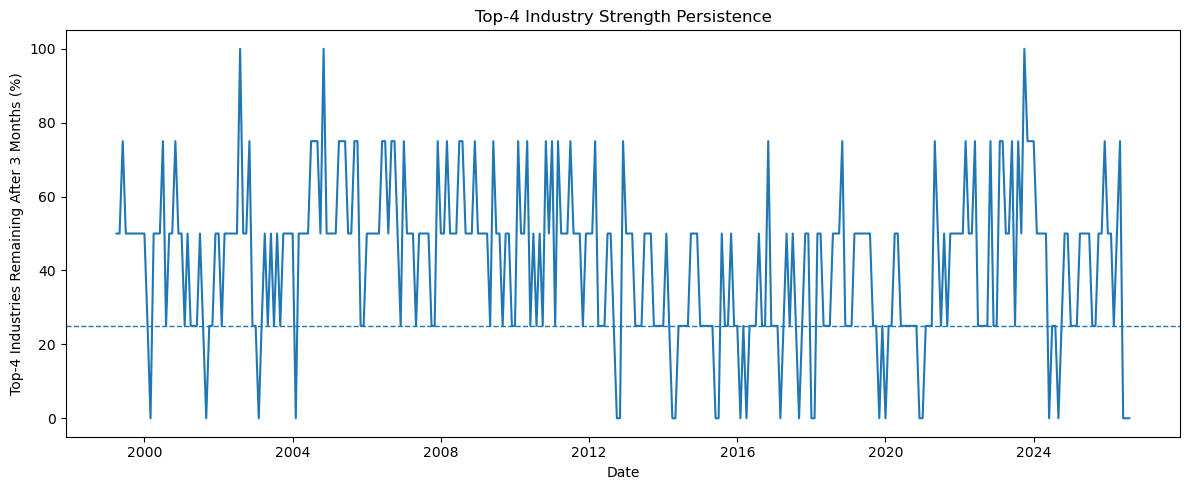

In [50]:
# ============================================================
# VISUALIZE INDUSTRY STRENGTH PERSISTENCE
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    top4_overlap.index,
    top4_overlap * 100
)

plt.axhline(
    25,
    linestyle="--",
    linewidth=1
)

plt.title("Top-4 Industry Strength Persistence")
plt.xlabel("Date")
plt.ylabel("Top-4 Industries Remaining After 3 Months (%)")

plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# CLASSIFY INDUSTRY ROTATION REGIMES
# ============================================================

# Cross-sectional median strength score each month
median_strength = industry_strength_score.median(axis=1)

# Number of industries with positive strength
positive_industries = (
    industry_strength_score > 0
).sum(axis=1)

# Rotation regime classification
rotation_regime = pd.Series(
    index=industry_strength_score.index,
    dtype="object"
)

rotation_regime[
    positive_industries >= 10
] = "Broad Strength"

rotation_regime[
    positive_industries <= 6
] = "Broad Weakness"

rotation_regime[
    (positive_industries > 6) &
    (positive_industries < 10)
] = "Mixed Rotation"

print("ROTATION REGIME CLASSIFICATION")
print("=" * 60)

print("\nRegime counts:")
print(rotation_regime.value_counts())

print("\nRegime percentages:")
print(
    (rotation_regime.value_counts(normalize=True) * 100)
    .round(2)
)

ROTATION REGIME CLASSIFICATION

Regime counts:
Mixed Rotation    236
Broad Strength     62
Broad Weakness     31
Name: count, dtype: int64

Regime percentages:
Mixed Rotation    71.73
Broad Strength    18.84
Broad Weakness     9.42
Name: proportion, dtype: float64


In [52]:
# ============================================================
# COMPARE EMPLOYMENT GROWTH ACROSS REGIMES
# ============================================================

# Average 12-month employment growth across industries
avg_industry_growth_12m = growth_12m.loc[
    strategy_dates
].mean(axis=1)

regime_outcomes = pd.DataFrame({
    "Regime": rotation_regime,
    "Average_12M_Employment_Growth": avg_industry_growth_12m
}).dropna()

regime_summary = (
    regime_outcomes
    .groupby("Regime")["Average_12M_Employment_Growth"]
    .agg(
        ["count", "mean", "median", "std"]
    )
    .round(3)
)

print("EMPLOYMENT CONDITIONS BY ROTATION REGIME")
print("=" * 60)

display(regime_summary)

EMPLOYMENT CONDITIONS BY ROTATION REGIME


,count,mean,median,std
Regime,,,,
Broad Strength,62,0.345,0.875,2.572
Broad Weakness,31,2.218,2.276,1.281
Mixed Rotation,236,1.551,1.540,2.305


In [53]:
# ============================================================
# REGIME TRANSITIONS
# ============================================================

# Previous month's regime
previous_regime = rotation_regime.shift(1)

transition_data = pd.DataFrame({
    "Previous": previous_regime,
    "Current": rotation_regime
}).dropna()

transition_matrix = pd.crosstab(
    transition_data["Previous"],
    transition_data["Current"],
    normalize="index"
) * 100

print("REGIME TRANSITION MATRIX")
print("=" * 60)

display(
    transition_matrix.round(2)
)

REGIME TRANSITION MATRIX


Current,Broad Strength,Broad Weakness,Mixed Rotation
Previous,,,
Broad Strength,33.87,3.23,62.90
Broad Weakness,12.90,16.13,70.97
Mixed Rotation,15.74,10.21,74.04


In [54]:
# ============================================================
# CALCULATE INDUSTRY STRENGTH MOMENTUM
# ============================================================

# Change in the Industry Strength Score over 3 months
strength_momentum = (
    industry_strength_score
    - industry_strength_score.shift(3)
)

print("INDUSTRY STRENGTH MOMENTUM")
print("=" * 60)

print("Shape:", strength_momentum.shape)

display(
    strength_momentum.tail()
)

INDUSTRY STRENGTH MOMENTUM
Shape: (329, 16)


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,0.425104,-2.076687,0.942179,-0.519613,0.228816,-0.533777,0.400124,0.364334,-1.543168,0.856513,-0.750420,0.880661,0.298757,0.707895,0.123816,0.195464
2026-05-01,1.900803,-1.165424,0.785656,0.081349,-0.102568,-1.077742,0.718923,0.464629,-0.269888,0.737839,0.648525,0.207693,-0.617749,0.512632,-1.851911,-0.972767
2026-06-01,2.101594,-0.586474,1.681500,-0.119936,0.241577,-0.343767,-0.624354,0.554340,-0.634313,0.311205,0.797642,0.045536,-0.062351,0.973927,-3.649209,-0.686916
2026-07-01,0.296803,0.156138,1.145104,0.924737,-0.551846,0.169275,-1.150381,-0.070804,1.924225,-0.307012,0.882466,-0.023979,-0.620781,0.664174,-2.752462,-0.685658
2026-08-01,-1.063157,-1.233685,-0.183554,0.147111,0.312022,1.244133,-0.745135,-0.007409,1.576362,0.422183,0.014294,0.681767,-0.014872,0.318575,-2.528658,1.060022


In [55]:
# ============================================================
# IDENTIFY INDUSTRY TURNING POINTS
# ============================================================

# Current strength and its 3-month change
turning_point_score = pd.concat(
    [
        industry_strength_score.stack().rename("Strength_Score"),
        strength_momentum.stack().rename("Strength_Momentum")
    ],
    axis=1
).dropna()

# Classify each industry
def classify_turning_point(row):
    if row["Strength_Score"] > 0 and row["Strength_Momentum"] > 0:
        return "Strengthening"
    elif row["Strength_Score"] > 0 and row["Strength_Momentum"] <= 0:
        return "Strong but Fading"
    elif row["Strength_Score"] <= 0 and row["Strength_Momentum"] > 0:
        return "Weak but Improving"
    else:
        return "Weakening"

turning_point_score["Signal"] = turning_point_score.apply(
    classify_turning_point,
    axis=1
)

print("INDUSTRY TURNING-POINT CLASSIFICATION")
print("=" * 60)

print("\nSignal counts:")
print(
    turning_point_score["Signal"].value_counts()
)

print("\nSignal percentages:")
print(
    (
        turning_point_score["Signal"]
        .value_counts(normalize=True) * 100
    ).round(2)
)

INDUSTRY TURNING-POINT CLASSIFICATION

Signal counts:
Signal
Strengthening         1813
Weakening             1748
Strong but Fading      904
Weak but Improving     751
Name: count, dtype: int64

Signal percentages:
Signal
Strengthening         34.76
Weakening             33.51
Strong but Fading     17.33
Weak but Improving    14.40
Name: proportion, dtype: float64


In [56]:
# ============================================================
# TEST TURNING-POINT SIGNALS
# ============================================================

# Future 12-month relative employment growth
future_relative = future_relative_growth.copy()

# Add turning-point classifications
turning_test = pd.concat(
    [
        turning_point_score["Signal"],
        future_relative.stack().rename("Future_Relative_Growth")
    ],
    axis=1
).dropna()

# Average future relative performance by signal
turning_summary = (
    turning_test
    .groupby("Signal")["Future_Relative_Growth"]
    .agg(
        ["count", "mean", "median", "std"]
    )
    .round(4)
)

print("TURNING-POINT SIGNAL TEST")
print("=" * 60)

display(turning_summary)

TURNING-POINT SIGNAL TEST


,count,mean,median,std
Signal,,,,
Strengthening,1752,-0.2382,-0.0801,3.8335
Strong but Fading,878,0.3368,0.3917,3.6442
Weak but Improving,722,-0.2822,0.1782,4.5447
Weakening,1672,0.1946,0.3903,4.3860


In [57]:
# ============================================================
# TEST WHETHER INDUSTRY STRENGTH MEAN-REVERTS
# ============================================================

# Current strength score vs future change in strength
future_strength_change = (
    industry_strength_score.shift(-12)
    - industry_strength_score
)

mean_reversion_test = pd.concat(
    [
        industry_strength_score.stack().rename("Current_Score"),
        future_strength_change.stack().rename("Future_Score_Change")
    ],
    axis=1
).dropna()

mean_reversion_corr = mean_reversion_test[
    "Current_Score"
].corr(
    mean_reversion_test["Future_Score_Change"]
)

print("MEAN-REVERSION TEST")
print("=" * 60)

print("Observations:", len(mean_reversion_test))
print(
    "Correlation between current strength "
    "and future 12-month score change:",
    round(mean_reversion_corr, 4)
)

MEAN-REVERSION TEST
Observations: 5072
Correlation between current strength and future 12-month score change: -0.7357


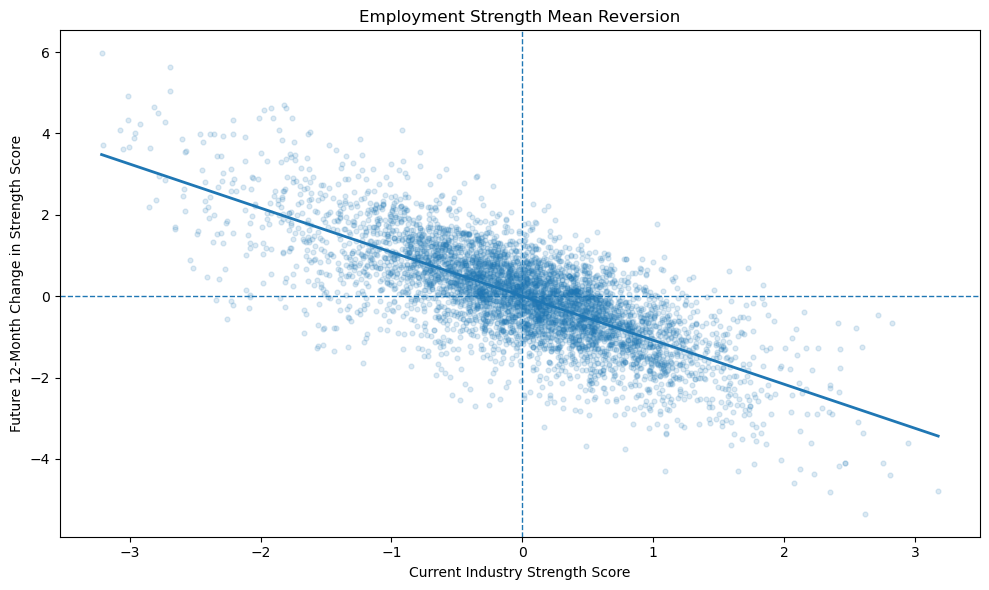

In [58]:
# ============================================================
# VISUALIZE MEAN REVERSION
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    mean_reversion_test["Current_Score"],
    mean_reversion_test["Future_Score_Change"],
    alpha=0.15,
    s=12
)

# Trend line
x = mean_reversion_test["Current_Score"]
y = mean_reversion_test["Future_Score_Change"]

slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.plot(
    x_line,
    y_line,
    linewidth=2
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.title(
    "Employment Strength Mean Reversion"
)
plt.xlabel(
    "Current Industry Strength Score"
)
plt.ylabel(
    "Future 12-Month Change in Strength Score"
)

plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# BUILD MEAN-REVERSION ROTATION SIGNAL
# ============================================================

# Higher signal = greater expected mean-reversion potential
mean_reversion_signal = -industry_strength_score

print("MEAN-REVERSION ROTATION SIGNAL")
print("=" * 60)

print("Shape:", mean_reversion_signal.shape)

display(
    mean_reversion_signal.tail()
)

MEAN-REVERSION ROTATION SIGNAL
Shape: (329, 16)


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,-0.124816,1.047507,-0.136743,0.660951,0.493513,0.544520,-0.795851,-0.975279,0.794202,0.165800,0.205331,0.048240,0.001951,-0.180463,-1.895083,0.146220
2026-05-01,-1.126927,0.242292,-0.347855,0.022897,0.747823,1.338057,-0.278057,-0.967151,0.076992,0.015532,-0.734997,0.365789,0.420261,-0.745669,-0.386126,1.357139
2026-06-01,-1.293059,0.371393,-0.710619,0.410893,0.776778,0.866844,-0.080837,-0.861759,-0.247170,0.526207,-0.824055,0.306059,0.083178,-1.146996,0.772998,1.050145
2026-07-01,-0.421619,0.891369,-1.281847,-0.263787,1.045359,0.375245,0.354530,-0.904474,-1.130023,0.472812,-0.677136,0.072218,0.622732,-0.844637,0.857379,0.831878
2026-08-01,-0.063770,1.475977,-0.164301,-0.124215,0.435801,0.093924,0.467078,-0.959741,-1.499370,-0.406651,-0.749292,-0.315979,0.435133,-1.064244,2.142532,0.297117


In [60]:
# ============================================================
# TEST MEAN-REVERSION SIGNAL
# ============================================================

# Align mean-reversion signal with future 12-month
# relative employment performance
mr_test = pd.concat(
    [
        mean_reversion_signal.stack().rename("MR_Signal"),
        future_relative_growth.stack().rename(
            "Future_Relative_Growth"
        )
    ],
    axis=1
).dropna()

# Correlation
mr_correlation = mr_test["MR_Signal"].corr(
    mr_test["Future_Relative_Growth"]
)

print("MEAN-REVERSION SIGNAL TEST")
print("=" * 60)

print("Observations:", len(mr_test))
print(
    "Correlation between mean-reversion signal and "
    "future relative growth:",
    round(mr_correlation, 4)
)

MEAN-REVERSION SIGNAL TEST
Observations: 5072
Correlation between mean-reversion signal and future relative growth: 0.031


In [61]:
# ============================================================
# CANADIAN EMPLOYMENT ROTATION INDEX (CERI)
# ============================================================

# Cross-sectional breadth:
# percentage of industries with positive strength momentum
positive_momentum = (
    strength_momentum > 0
).sum(axis=1)

ceri = (
    positive_momentum /
    industry_strength_score.shape[1]
) * 100

print("CANADIAN EMPLOYMENT ROTATION INDEX (CERI)")
print("=" * 60)

print("Minimum:", round(ceri.min(), 2))
print("Maximum:", round(ceri.max(), 2))
print("Mean:", round(ceri.mean(), 2))
print("Median:", round(ceri.median(), 2))

print("\nLatest CERI:")
print(round(ceri.iloc[-1], 2))

CANADIAN EMPLOYMENT ROTATION INDEX (CERI)
Minimum: 0.0
Maximum: 75.0
Mean: 48.71
Median: 50.0

Latest CERI:
56.25


In [62]:
# ============================================================
# DEFINE CERI REGIMES
# ============================================================

ceri_low = ceri.quantile(0.25)
ceri_high = ceri.quantile(0.75)

ceri_regime = pd.Series(
    index=ceri.index,
    dtype="object"
)

ceri_regime[ceri <= ceri_low] = "Weak Rotation"
ceri_regime[
    (ceri > ceri_low) &
    (ceri < ceri_high)
] = "Balanced Rotation"
ceri_regime[ceri >= ceri_high] = "Broad Rotation"

print("CERI REGIME CLASSIFICATION")
print("=" * 60)

print("25th percentile:", round(ceri_low, 2))
print("75th percentile:", round(ceri_high, 2))

print("\nRegime counts:")
print(ceri_regime.value_counts())

print("\nRegime percentages:")
print(
    (ceri_regime.value_counts(normalize=True) * 100)
    .round(2)
)

CERI REGIME CLASSIFICATION
25th percentile: 43.75
75th percentile: 56.25

Regime counts:
Weak Rotation        125
Broad Rotation       105
Balanced Rotation     99
Name: count, dtype: int64

Regime percentages:
Weak Rotation        37.99
Broad Rotation       31.91
Balanced Rotation    30.09
Name: proportion, dtype: float64


In [63]:
# ============================================================
# TEST CERI REGIMES
# ============================================================

# Future 12-month change in the average industry strength score
future_avg_strength = (
    industry_strength_score.shift(-12).mean(axis=1)
    - industry_strength_score.mean(axis=1)
)

ceri_test = pd.DataFrame({
    "CERI_Regime": ceri_regime,
    "Future_Avg_Strength_Change": future_avg_strength
}).dropna()

ceri_summary = (
    ceri_test
    .groupby("CERI_Regime")["Future_Avg_Strength_Change"]
    .agg(["count", "mean", "median", "std"])
    .round(4)
)

print("CERI REGIME TEST")
print("=" * 60)

display(ceri_summary)

CERI REGIME TEST


,count,mean,median,std
CERI_Regime,,,,
Balanced Rotation,97,-0.0,0.0,0.0
Broad Rotation,102,0.0,0.0,0.0
Weak Rotation,118,-0.0,0.0,0.0


In [64]:
# ============================================================
# TEST CERI PERSISTENCE
# ============================================================

# CERI 12 months into the future
future_ceri = ceri.shift(-12)

ceri_persistence_data = pd.DataFrame({
    "Current_CERI": ceri,
    "Future_CERI_12M": future_ceri
}).dropna()

# Correlation between current and future CERI
ceri_persistence_corr = (
    ceri_persistence_data["Current_CERI"]
    .corr(
        ceri_persistence_data["Future_CERI_12M"]
    )
)

print("CERI PERSISTENCE TEST")
print("=" * 60)

print(
    "Correlation between current CERI and "
    "future 12-month CERI:",
    round(ceri_persistence_corr, 4)
)

print(
    "Observations:",
    len(ceri_persistence_data)
)

CERI PERSISTENCE TEST
Correlation between current CERI and future 12-month CERI: -0.0074
Observations: 317


In [65]:
# ============================================================
# MEASURE INDUSTRY RANK TURNOVER
# ============================================================

# Rank industries each month
rank_matrix = industry_strength_score.rank(
    axis=1,
    ascending=False,
    method="first"
)

# Absolute change in rank over 3 months
rank_change_3m = (
    rank_matrix
    - rank_matrix.shift(3)
).abs()

# Average rank movement across industries
avg_rank_turnover = rank_change_3m.mean(axis=1).dropna()

print("INDUSTRY RANK TURNOVER")
print("=" * 60)

print("Average 3-month rank movement:",
      round(avg_rank_turnover.mean(), 2))

print("Median 3-month rank movement:",
      round(avg_rank_turnover.median(), 2))

print("Maximum 3-month rank movement:",
      round(avg_rank_turnover.max(), 2))

print("Observations:", len(avg_rank_turnover))

INDUSTRY RANK TURNOVER
Average 3-month rank movement: 3.97
Median 3-month rank movement: 3.88
Maximum 3-month rank movement: 7.0
Observations: 326


In [66]:
# ============================================================
# IDENTIFY PERSISTENT INDUSTRY LEADERS AND LAGGARDS
# ============================================================

# Average rank across the entire strategy period
average_rank = rank_matrix.mean(axis=0).sort_values()

# Share of months each industry was in the top 4
top4_frequency = (
    (rank_matrix <= 4)
    .mean(axis=0) * 100
).sort_values(ascending=False)

# Share of months each industry was in the bottom 4
bottom4_frequency = (
    (rank_matrix >= 13)
    .mean(axis=0) * 100
).sort_values(ascending=False)

persistent_summary = pd.DataFrame({
    "Average_Rank": average_rank,
    "Top4_Frequency_%": top4_frequency,
    "Bottom4_Frequency_%": bottom4_frequency
}).sort_values("Average_Rank")

print("PERSISTENT INDUSTRY LEADERS AND LAGGARDS")
print("=" * 60)

display(
    persistent_summary.round(2)
)

PERSISTENT INDUSTRY LEADERS AND LAGGARDS


,Average_Rank,Top4_Frequency_%,Bottom4_Frequency_%
North American Industry Classification System (NAICS),,,
Health care and social assistance [62],6.73,23.71,3.65
Construction [23],6.89,36.17,13.07
"Professional, scientific and technical services [54]",7.49,30.70,15.81
Transportation and warehousing [48-49],7.73,31.91,19.15
"Finance, insurance, real estate, rental and leasing [52-53]",7.81,22.49,12.77
Public administration [91],8.29,22.49,19.15
Accommodation and food services [72],8.30,26.75,21.88
Educational services [61],8.32,24.62,18.24
"Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",8.63,32.52,35.56


In [67]:
# ============================================================
# MEASURE INDUSTRY RANK VOLATILITY
# ============================================================

# Standard deviation of monthly industry rank
rank_volatility = rank_matrix.std(axis=0).sort_values(
    ascending=False
)

# Range between best and worst historical rank
rank_range = (
    rank_matrix.max(axis=0)
    - rank_matrix.min(axis=0)
).sort_values(
    ascending=False
)

cyclicality_summary = pd.DataFrame({
    "Rank_Volatility": rank_volatility,
    "Rank_Range": rank_range
})

print("INDUSTRY RANK VOLATILITY / CYCLICALITY")
print("=" * 60)

display(
    cyclicality_summary.round(2)
)

INDUSTRY RANK VOLATILITY / CYCLICALITY


,Rank_Volatility,Rank_Range
North American Industry Classification System (NAICS),,
Accommodation and food services [72],4.48,15.0
"Agriculture [111-112, 1100, 1151-1152]",5.15,15.0
"Business, building and other support services [55-56]",5.00,15.0
Construction [23],4.16,14.0
Educational services [61],4.15,15.0
"Finance, insurance, real estate, rental and leasing [52-53]",3.75,15.0
"Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",5.51,15.0
Health care and social assistance [62],2.92,14.0
"Information, culture and recreation [51, 71]",4.90,15.0


In [68]:
# ============================================================
# CREATE INDUSTRY CYCLICALITY SCORE
# ============================================================

# Normalize rank volatility into a 0-100 score
cyclicality_score = (
    (rank_volatility - rank_volatility.min())
    / (rank_volatility.max() - rank_volatility.min())
) * 100

cyclicality_summary["Cyclicality_Score"] = (
    cyclicality_score
)

print("INDUSTRY CYCLICALITY SCORE")
print("=" * 60)

display(
    cyclicality_summary
    .sort_values("Cyclicality_Score", ascending=False)
    .round(2)
)

INDUSTRY CYCLICALITY SCORE


,Rank_Volatility,Rank_Range,Cyclicality_Score
North American Industry Classification System (NAICS),,,
Utilities [22],5.95,15.0,100.00
"Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",5.51,15.0,85.46
"Agriculture [111-112, 1100, 1151-1152]",5.15,15.0,73.42
"Business, building and other support services [55-56]",5.00,15.0,68.71
"Information, culture and recreation [51, 71]",4.90,15.0,65.36
Other services (except public administration) [81],4.77,15.0,61.00
Accommodation and food services [72],4.48,15.0,51.56
Transportation and warehousing [48-49],4.46,15.0,50.88
Construction [23],4.16,14.0,40.90


In [69]:
# ============================================================
# TEST CYCLICALITY AND RANK REVERSAL
# ============================================================

# Absolute change in rank over the next 12 months
future_rank_change = (
    rank_matrix.shift(-12) - rank_matrix
).abs()

# Average future rank movement by industry
future_rank_movement = future_rank_change.mean(
    axis=0
)

cyclicality_test = pd.DataFrame({
    "Cyclicality_Score": cyclicality_score,
    "Future_12M_Rank_Movement": future_rank_movement
}).dropna()

cyclicality_corr = (
    cyclicality_test["Cyclicality_Score"]
    .corr(
        cyclicality_test["Future_12M_Rank_Movement"]
    )
)

print("CYCLICALITY VS FUTURE RANK REVERSAL")
print("=" * 60)

print(
    "Correlation:",
    round(cyclicality_corr, 4)
)

print(
    "Industries:",
    len(cyclicality_test)
)

display(
    cyclicality_test.sort_values(
        "Cyclicality_Score",
        ascending=False
    ).round(2)
)

CYCLICALITY VS FUTURE RANK REVERSAL
Correlation: 0.9727
Industries: 16


,Cyclicality_Score,Future_12M_Rank_Movement
North American Industry Classification System (NAICS),,
Utilities [22],100.00,7.32
"Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",85.46,6.96
"Agriculture [111-112, 1100, 1151-1152]",73.42,6.18
"Business, building and other support services [55-56]",68.71,6.10
"Information, culture and recreation [51, 71]",65.36,6.33
Other services (except public administration) [81],61.00,5.71
Accommodation and food services [72],51.56,5.75
Transportation and warehousing [48-49],50.88,5.79
Construction [23],40.90,4.82


In [70]:
# ============================================================
# COMBINE INDUSTRY STRENGTH AND CYCLICALITY
# ============================================================

# Latest strength score
latest_strength = industry_strength_score.iloc[-1]

# Create combined industry profile
industry_profile = pd.DataFrame({
    "Current_Strength": latest_strength,
    "Cyclicality_Score": cyclicality_score
})

# Classify industries into four quadrants
def classify_industry(row):
    if row["Current_Strength"] >= 0 and row["Cyclicality_Score"] >= 50:
        return "Strong & Cyclical"
    elif row["Current_Strength"] >= 0 and row["Cyclicality_Score"] < 50:
        return "Strong & Stable"
    elif row["Current_Strength"] < 0 and row["Cyclicality_Score"] >= 50:
        return "Weak & Cyclical"
    else:
        return "Weak & Stable"

industry_profile["Profile"] = industry_profile.apply(
    classify_industry,
    axis=1
)

print("INDUSTRY STRENGTH–CYCLICALITY PROFILE")
print("=" * 60)

display(
    industry_profile
    .sort_values("Current_Strength", ascending=False)
    .round(2)
)

INDUSTRY STRENGTH–CYCLICALITY PROFILE


,Current_Strength,Cyclicality_Score,Profile
North American Industry Classification System (NAICS),,,
"Information, culture and recreation [51, 71]",1.50,65.36,Strong & Cyclical
Transportation and warehousing [48-49],1.06,50.88,Strong & Cyclical
Health care and social assistance [62],0.96,0.00,Strong & Stable
Other services (except public administration) [81],0.75,61.00,Strong & Cyclical
Manufacturing [31-33],0.41,37.90,Strong & Stable
"Professional, scientific and technical services [54]",0.32,38.51,Strong & Stable
"Business, building and other support services [55-56]",0.16,68.71,Strong & Cyclical
Construction [23],0.12,40.90,Strong & Stable
Accommodation and food services [72],0.06,51.56,Strong & Cyclical


In [71]:
# ============================================================
# IDENTIFY CURRENT PORTFOLIO CANDIDATES
# ============================================================

# Rank industries from strongest to weakest based on
# their current employment strength score.
industry_profile["Strength_Rank"] = (
    industry_profile["Current_Strength"]
    .rank(
        ascending=False,
        method="first"
    )
)

# Rank industries from most cyclical to least cyclical.
# A higher cyclicality score means the industry's
# employment ranking has historically moved more.
industry_profile["Cyclicality_Rank"] = (
    industry_profile["Cyclicality_Score"]
    .rank(
        ascending=False,
        method="first"
    )
)

# Create a preliminary opportunity score.
# Higher employment strength increases the score,
# while higher cyclicality receives a small penalty.
#
# This is a research ranking only at this stage.
# It is NOT yet a tested investment strategy.
industry_profile["Opportunity_Score"] = (
    industry_profile["Current_Strength"]
    - 0.25 * (
        industry_profile["Cyclicality_Score"] / 100
    )
)

# Display industries from the highest opportunity score
# to the lowest.
print("CURRENT PORTFOLIO CANDIDATES")
print("=" * 60)

display(
    industry_profile
    .sort_values(
        "Opportunity_Score",
        ascending=False
    )
    .round(3)
)

CURRENT PORTFOLIO CANDIDATES


,Current_Strength,Cyclicality_Score,Profile,Strength_Rank,Cyclicality_Rank,Opportunity_Score
North American Industry Classification System (NAICS),,,,,,
"Information, culture and recreation [51, 71]",1.499,65.365,Strong & Cyclical,1.0,5.0,1.336
Health care and social assistance [62],0.960,0.000,Strong & Stable,3.0,16.0,0.960
Transportation and warehousing [48-49],1.064,50.883,Strong & Cyclical,2.0,8.0,0.937
Other services (except public administration) [81],0.749,61.000,Strong & Cyclical,4.0,6.0,0.597
Manufacturing [31-33],0.407,37.902,Strong & Stable,5.0,13.0,0.312
"Professional, scientific and technical services [54]",0.316,38.510,Strong & Stable,6.0,12.0,0.220
Construction [23],0.124,40.897,Strong & Stable,8.0,9.0,0.022
"Business, building and other support services [55-56]",0.164,68.707,Strong & Cyclical,7.0,4.0,-0.007
Accommodation and food services [72],0.064,51.565,Strong & Cyclical,9.0,7.0,-0.065


In [72]:
# ============================================================
# CREATE BASELINE TOP-4 PORTFOLIO
# ============================================================

# Rank industries each month using the employment
# strength score only.
strength_rank = industry_strength_score.rank(
    axis=1,
    ascending=False,
    method="first"
)

# Select the four strongest industries each month.
top4_portfolio = strength_rank <= 4

# Equal-weight the selected industries.
# Each selected industry receives 25% of the portfolio.
baseline_weights = (
    top4_portfolio
    .astype(float)
    .div(
        top4_portfolio.sum(axis=1),
        axis=0
    )
)

print("BASELINE TOP-4 PORTFOLIO")
print("=" * 60)

print(
    "Average number of industries held:",
    round(
        top4_portfolio.sum(axis=1).mean(),
        2
    )
)

print(
    "Portfolio months:",
    len(baseline_weights)
)

print(
    "Maximum weight:",
    baseline_weights.max().max()
)

display(
    baseline_weights.tail()
)

BASELINE TOP-4 PORTFOLIO
Average number of industries held: 4.0
Portfolio months: 329
Maximum weight: 0.25


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,0.00,0.0,0.00,0.0,0.0,0.0,0.25,0.25,0.00,0.0,0.00,0.0,0.0,0.25,0.25,0.0
2026-05-01,0.25,0.0,0.00,0.0,0.0,0.0,0.00,0.25,0.00,0.0,0.25,0.0,0.0,0.25,0.00,0.0
2026-06-01,0.25,0.0,0.00,0.0,0.0,0.0,0.00,0.25,0.00,0.0,0.25,0.0,0.0,0.25,0.00,0.0
2026-07-01,0.00,0.0,0.25,0.0,0.0,0.0,0.00,0.25,0.25,0.0,0.00,0.0,0.0,0.25,0.00,0.0
2026-08-01,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.25,0.25,0.0,0.25,0.0,0.0,0.25,0.00,0.0


In [73]:
# ============================================================
# LAG PORTFOLIO WEIGHTS TO AVOID LOOK-AHEAD BIAS
# ============================================================

# The portfolio formed at month t can only be applied
# to the following month (t+1).
lagged_weights = baseline_weights.shift(1)

# Remove the first month because no prior signal exists.
lagged_weights = lagged_weights.dropna(how="all")

print("LAGGED PORTFOLIO WEIGHTS")
print("=" * 60)

print("Portfolio months:", len(lagged_weights))
print(
    "Maximum portfolio weight:",
    lagged_weights.max().max()
)

print(
    "Minimum portfolio weight:",
    lagged_weights.min().min()
)

display(
    lagged_weights.head()
)

LAGGED PORTFOLIO WEIGHTS
Portfolio months: 328
Maximum portfolio weight: 0.25
Minimum portfolio weight: 0.0


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
1999-05-01,0.0,0.0,0.25,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.25,0.25,0.0,0.25,0.0,0.00
1999-06-01,0.0,0.0,0.25,0.0,0.25,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.25,0.0,0.25
1999-07-01,0.0,0.0,0.00,0.0,0.25,0.0,0.0,0.0,0.0,0.25,0.00,0.00,0.0,0.25,0.0,0.25
1999-08-01,0.0,0.0,0.25,0.0,0.25,0.0,0.0,0.0,0.0,0.25,0.00,0.00,0.0,0.25,0.0,0.00
1999-09-01,0.0,0.0,0.00,0.0,0.25,0.0,0.0,0.0,0.0,0.25,0.00,0.25,0.0,0.25,0.0,0.00


In [75]:
# ============================================================
# CALCULATE PORTFOLIO EMPLOYMENT GROWTH
# ============================================================

# Calculate monthly employment growth for each industry.
# This is the outcome used to evaluate the hypothetical
# employment-rotation portfolio.
monthly_industry_growth = (
    industry_matrix_strategy.pct_change() * 100
)

# Align the lagged portfolio weights with monthly industry growth.
portfolio_growth_data = monthly_industry_growth.loc[
    lagged_weights.index
]

# Calculate the equal-weighted portfolio employment growth.
# Because weights are lagged, the portfolio only uses
# information that was available in the previous month.
portfolio_employment_growth = (
    lagged_weights * portfolio_growth_data
).sum(axis=1)

print("PORTFOLIO EMPLOYMENT GROWTH")
print("=" * 60)

print(
    "Average monthly employment growth:",
    round(portfolio_employment_growth.mean(), 4),
    "%"
)

print(
    "Standard deviation:",
    round(portfolio_employment_growth.std(), 4),
    "%"
)

print(
    "Observations:",
    len(portfolio_employment_growth)
)

display(
    portfolio_employment_growth.head()
)

PORTFOLIO EMPLOYMENT GROWTH
Average monthly employment growth: -0.0572 %
Standard deviation: 0.954 %
Observations: 328


Date
1999-05-01   -0.000694
1999-06-01    0.182371
1999-07-01    0.713056
1999-08-01    0.354667
1999-09-01   -0.211036
dtype: float64

In [76]:
# ============================================================
# BUILD EQUAL-WEIGHT INDUSTRY BENCHMARK
# ============================================================

# Equal-weight all 16 industries every month.
# This represents a passive employment benchmark.
benchmark_weights = pd.DataFrame(
    1 / industry_matrix_strategy.shape[1],
    index=industry_matrix_strategy.index,
    columns=industry_matrix_strategy.columns
)

# Lag benchmark weights by one month to keep the comparison
# consistent with the portfolio methodology.
lagged_benchmark_weights = benchmark_weights.shift(1)

# Align benchmark weights with monthly employment growth.
benchmark_growth_data = monthly_industry_growth.loc[
    lagged_benchmark_weights.index
]

# Calculate benchmark employment growth.
benchmark_employment_growth = (
    lagged_benchmark_weights * benchmark_growth_data
).sum(axis=1)

# Remove any initial missing observation.
benchmark_employment_growth = (
    benchmark_employment_growth.dropna()
)

print("EQUAL-WEIGHT BENCHMARK")
print("=" * 60)

print(
    "Average monthly employment growth:",
    round(benchmark_employment_growth.mean(), 4),
    "%"
)

print(
    "Standard deviation:",
    round(benchmark_employment_growth.std(), 4),
    "%"
)

print(
    "Observations:",
    len(benchmark_employment_growth)
)

display(
    benchmark_employment_growth.head()
)

EQUAL-WEIGHT BENCHMARK
Average monthly employment growth: 0.1164 %
Standard deviation: 0.8276 %
Observations: 329


Date
1999-04-01    0.000000
1999-05-01    0.213957
1999-06-01   -0.212770
1999-07-01    0.426097
1999-08-01   -0.000270
dtype: float64

In [77]:
# ============================================================
# COMPARE PORTFOLIO VS BENCHMARK
# ============================================================

# Align both series on the same dates.
comparison = pd.concat(
    [
        portfolio_employment_growth.rename(
            "Portfolio_Growth"
        ),
        benchmark_employment_growth.rename(
            "Benchmark_Growth"
        )
    ],
    axis=1
).dropna()

# Calculate the portfolio's monthly excess growth.
comparison["Excess_Growth"] = (
    comparison["Portfolio_Growth"]
    - comparison["Benchmark_Growth"]
)

print("PORTFOLIO VS BENCHMARK")
print("=" * 60)

print(
    "Average monthly portfolio growth:",
    round(
        comparison["Portfolio_Growth"].mean(),
        4
    ),
    "%"
)

print(
    "Average monthly benchmark growth:",
    round(
        comparison["Benchmark_Growth"].mean(),
        4
    ),
    "%"
)

print(
    "Average monthly excess growth:",
    round(
        comparison["Excess_Growth"].mean(),
        4
    ),
    "%"
)

print(
    "Months outperforming benchmark:",
    (
        comparison["Excess_Growth"] > 0
    ).sum()
)

print(
    "Months underperforming benchmark:",
    (
        comparison["Excess_Growth"] < 0
    ).sum()
)

display(
    comparison.head()
)

PORTFOLIO VS BENCHMARK
Average monthly portfolio growth: -0.0572 %
Average monthly benchmark growth: 0.1167 %
Average monthly excess growth: -0.1739 %
Months outperforming benchmark: 136
Months underperforming benchmark: 192


,Portfolio_Growth,Benchmark_Growth,Excess_Growth
Date,,,
1999-05-01,-0.000694,0.213957,-0.214652
1999-06-01,0.182371,-0.212770,0.395141
1999-07-01,0.713056,0.426097,0.286959
1999-08-01,0.354667,-0.000270,0.354936
1999-09-01,-0.211036,0.132190,-0.343226


CUMULATIVE PERFORMANCE
Final portfolio index: 0.816
Final benchmark index: 1.449


,Portfolio_Growth,Benchmark_Growth,Excess_Growth,Portfolio_Index,Benchmark_Index
Date,,,,,
2026-04-01,-1.445165,-0.292736,-1.152429,0.812382,1.455820
2026-05-01,0.076605,0.469715,-0.393111,0.813004,1.462658
2026-06-01,0.611758,-0.248766,0.860524,0.817978,1.459019
2026-07-01,0.157528,-0.101264,0.258791,0.819266,1.457542
2026-08-01,-0.369877,-0.567441,0.197564,0.816236,1.449271


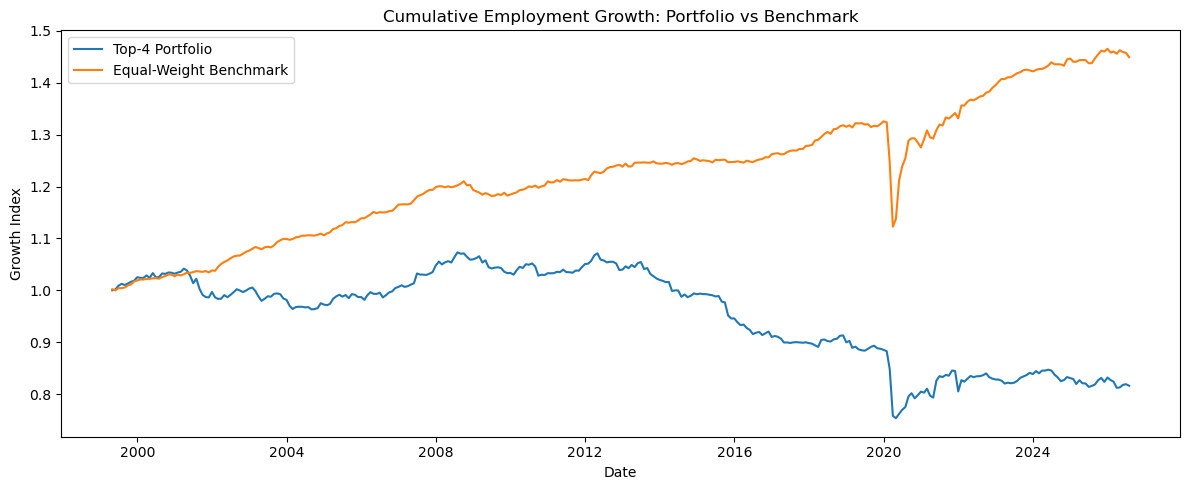

In [78]:
# ============================================================
# CUMULATIVE PORTFOLIO VS BENCHMARK
# ============================================================

# Convert monthly percentage growth into growth multipliers.
portfolio_multiplier = (
    1 + comparison["Portfolio_Growth"] / 100
)

benchmark_multiplier = (
    1 + comparison["Benchmark_Growth"] / 100
)

# Calculate cumulative employment-growth indices.
comparison["Portfolio_Index"] = (
    portfolio_multiplier.cumprod()
)

comparison["Benchmark_Index"] = (
    benchmark_multiplier.cumprod()
)

print("CUMULATIVE PERFORMANCE")
print("=" * 60)

print(
    "Final portfolio index:",
    round(
        comparison["Portfolio_Index"].iloc[-1],
        3
    )
)

print(
    "Final benchmark index:",
    round(
        comparison["Benchmark_Index"].iloc[-1],
        3
    )
)

display(
    comparison.tail()
)

# Plot cumulative performance
plt.figure(figsize=(12, 5))

plt.plot(
    comparison.index,
    comparison["Portfolio_Index"],
    label="Top-4 Portfolio"
)

plt.plot(
    comparison.index,
    comparison["Benchmark_Index"],
    label="Equal-Weight Benchmark"
)

plt.title(
    "Cumulative Employment Growth: Portfolio vs Benchmark"
)

plt.xlabel("Date")
plt.ylabel("Growth Index")

plt.legend()

plt.tight_layout()
plt.show()

In [79]:
# ============================================================
# CALCULATE PORTFOLIO DRAWDOWN
# ============================================================

# Calculate the running maximum of the portfolio index.
portfolio_running_max = (
    comparison["Portfolio_Index"]
    .cummax()
)

# Drawdown measures the percentage decline from
# the previous historical peak.
portfolio_drawdown = (
    comparison["Portfolio_Index"]
    / portfolio_running_max
    - 1
) * 100

print("PORTFOLIO DRAWDOWN")
print("=" * 60)

print(
    "Maximum drawdown:",
    round(
        portfolio_drawdown.min(),
        2
    ),
    "%"
)

print(
    "Average drawdown:",
    round(
        portfolio_drawdown.mean(),
        2
    ),
    "%"
)

print(
    "Final drawdown:",
    round(
        portfolio_drawdown.iloc[-1],
        2
    ),
    "%"
)

print(
    "Observations:",
    len(portfolio_drawdown)
)

display(
    portfolio_drawdown.tail()
)

PORTFOLIO DRAWDOWN
Maximum drawdown: -29.78 %
Average drawdown: -10.15 %
Final drawdown: -23.95 %
Observations: 328


Date
2026-04-01   -24.306286
2026-05-01   -24.248301
2026-06-01   -23.784884
2026-07-01   -23.664824
2026-08-01   -23.947170
Freq: MS, Name: Portfolio_Index, dtype: float64

In [80]:
# ============================================================
# CALCULATE PORTFOLIO TURNOVER
# ============================================================

# Absolute change in portfolio weights from one month
# to the next.
weight_changes = (
    lagged_weights.diff().abs()
)

# One-way turnover:
# sum of absolute weight changes divided by 2.
monthly_turnover = (
    weight_changes.sum(axis=1) / 2
).dropna()

print("PORTFOLIO TURNOVER")
print("=" * 60)

print(
    "Average monthly turnover:",
    round(
        monthly_turnover.mean() * 100,
        2
    ),
    "%"
)

print(
    "Median monthly turnover:",
    round(
        monthly_turnover.median() * 100,
        2
    ),
    "%"
)

print(
    "Maximum monthly turnover:",
    round(
        monthly_turnover.max() * 100,
        2
    ),
    "%"
)

print(
    "Months measured:",
    len(monthly_turnover)
)

display(
    monthly_turnover.head()
)

PORTFOLIO TURNOVER
Average monthly turnover: 38.34 %
Median monthly turnover: 25.0 %
Maximum monthly turnover: 100.0 %
Months measured: 328


Date
1999-05-01    0.00
1999-06-01    0.50
1999-07-01    0.25
1999-08-01    0.25
1999-09-01    0.25
dtype: float64

In [81]:
# ============================================================
# ESTIMATE TRANSACTION-COST IMPACT
# ============================================================

# Illustrative one-way transaction-cost assumptions.
transaction_costs = [
    0.001,   # 0.10%
    0.0025,  # 0.25%
    0.005    # 0.50%
]

print("TRANSACTION-COST SENSITIVITY")
print("=" * 60)

for cost in transaction_costs:

    # Estimated monthly cost = turnover × one-way cost
    monthly_cost = (
        monthly_turnover * cost
    )

    print(
        f"One-way cost: {cost * 100:.2f}%"
    )

    print(
        "Average monthly cost impact:",
        round(
            monthly_cost.mean() * 100,
            4
        ),
        "%"
    )

    print(
        "Annualized simple cost impact:",
        round(
            monthly_cost.mean() * 12 * 100,
            2
        ),
        "%"
    )

    print()

TRANSACTION-COST SENSITIVITY
One-way cost: 0.10%
Average monthly cost impact: 0.0383 %
Annualized simple cost impact: 0.46 %

One-way cost: 0.25%
Average monthly cost impact: 0.0958 %
Annualized simple cost impact: 1.15 %

One-way cost: 0.50%
Average monthly cost impact: 0.1917 %
Annualized simple cost impact: 2.3 %



In [82]:
# ============================================================
# CREATE QUARTERLY-ROTATION PORTFOLIO
# ============================================================

# Use the strength ranking from the signal date,
# but only allow portfolio changes every 3 months.
quarterly_weights = baseline_weights.copy()

# Identify every third month starting from the first
# available strategy observation.
rebalance_dates = quarterly_weights.index[
    np.arange(len(quarterly_weights)) % 3 == 0
]

# Forward-fill the portfolio weights between
# scheduled rebalance dates.
quarterly_weights = quarterly_weights.loc[
    rebalance_dates
].reindex(
    quarterly_weights.index,
    method="ffill"
)

# Lag the weights by one month to preserve
# look-ahead protection.
lagged_quarterly_weights = (
    quarterly_weights.shift(1)
)

print("QUARTERLY-ROTATION PORTFOLIO")
print("=" * 60)

print(
    "Rebalance dates:",
    len(rebalance_dates)
)

print(
    "Portfolio months:",
    len(lagged_quarterly_weights.dropna(
        how="all"
    ))
)

print(
    "Maximum portfolio weight:",
    lagged_quarterly_weights.max().max()
)

display(
    lagged_quarterly_weights.tail()
)

QUARTERLY-ROTATION PORTFOLIO
Rebalance dates: 110
Portfolio months: 328
Maximum portfolio weight: 0.25


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,0.0,0.25,0.00,0.0,0.0,0.0,0.00,0.25,0.25,0.0,0.0,0.0,0.0,0.00,0.25,0.0
2026-05-01,0.0,0.00,0.00,0.0,0.0,0.0,0.25,0.25,0.00,0.0,0.0,0.0,0.0,0.25,0.25,0.0
2026-06-01,0.0,0.00,0.00,0.0,0.0,0.0,0.25,0.25,0.00,0.0,0.0,0.0,0.0,0.25,0.25,0.0
2026-07-01,0.0,0.00,0.00,0.0,0.0,0.0,0.25,0.25,0.00,0.0,0.0,0.0,0.0,0.25,0.25,0.0
2026-08-01,0.0,0.00,0.25,0.0,0.0,0.0,0.00,0.25,0.25,0.0,0.0,0.0,0.0,0.25,0.00,0.0


In [83]:
# ============================================================
# CALCULATE QUARTERLY PORTFOLIO EMPLOYMENT GROWTH
# ============================================================

# Use the same monthly industry employment growth measure
# used for the baseline portfolio.
quarterly_growth_data = monthly_industry_growth.loc[
    lagged_quarterly_weights.index
]

# Calculate the equal-weighted employment growth of the
# industries selected by the quarterly rotation strategy.
quarterly_portfolio_growth = (
    lagged_quarterly_weights *
    quarterly_growth_data
).sum(axis=1)

# Remove the initial missing observation.
quarterly_portfolio_growth = (
    quarterly_portfolio_growth.dropna()
)

print("QUARTERLY PORTFOLIO EMPLOYMENT GROWTH")
print("=" * 60)

print(
    "Average monthly employment growth:",
    round(
        quarterly_portfolio_growth.mean(),
        4
    ),
    "%"
)

print(
    "Standard deviation:",
    round(
        quarterly_portfolio_growth.std(),
        4
    ),
    "%"
)

print(
    "Observations:",
    len(quarterly_portfolio_growth)
)

display(
    quarterly_portfolio_growth.head()
)

QUARTERLY PORTFOLIO EMPLOYMENT GROWTH
Average monthly employment growth: 0.0367 %
Standard deviation: 0.9796 %
Observations: 329


Date
1999-04-01    0.000000
1999-05-01   -0.000694
1999-06-01   -0.136325
1999-07-01    0.781023
1999-08-01    0.354667
dtype: float64

In [84]:
# ============================================================
# COMPARE QUARTERLY STRATEGY VS BENCHMARK
# ============================================================

quarterly_comparison = pd.concat(
    [
        quarterly_portfolio_growth.rename(
            "Quarterly_Portfolio_Growth"
        ),
        benchmark_employment_growth.rename(
            "Benchmark_Growth"
        )
    ],
    axis=1
).dropna()

# Calculate monthly excess employment growth.
quarterly_comparison["Excess_Growth"] = (
    quarterly_comparison["Quarterly_Portfolio_Growth"]
    - quarterly_comparison["Benchmark_Growth"]
)

print("QUARTERLY STRATEGY VS BENCHMARK")
print("=" * 60)

print(
    "Average quarterly-strategy monthly growth:",
    round(
        quarterly_comparison[
            "Quarterly_Portfolio_Growth"
        ].mean(),
        4
    ),
    "%"
)

print(
    "Average benchmark monthly growth:",
    round(
        quarterly_comparison[
            "Benchmark_Growth"
        ].mean(),
        4
    ),
    "%"
)

print(
    "Average monthly excess growth:",
    round(
        quarterly_comparison[
            "Excess_Growth"
        ].mean(),
        4
    ),
    "%"
)

print(
    "Months outperforming:",
    (
        quarterly_comparison["Excess_Growth"] > 0
    ).sum()
)

print(
    "Months underperforming:",
    (
        quarterly_comparison["Excess_Growth"] < 0
    ).sum()
)

QUARTERLY STRATEGY VS BENCHMARK
Average quarterly-strategy monthly growth: 0.0367 %
Average benchmark monthly growth: 0.1164 %
Average monthly excess growth: -0.0796 %
Months outperforming: 158
Months underperforming: 170


In [85]:
# ============================================================
# CREATE QUARTERLY TOP-8 PORTFOLIO
# ============================================================

# Rank industries by current employment strength.
strength_rank = industry_strength_score.rank(
    axis=1,
    ascending=False,
    method="first"
)

# Select the 8 strongest industries at each signal date.
top8_selection = strength_rank <= 8

# Equal-weight the selected industries.
top8_weights = (
    top8_selection
    .astype(float)
    .div(
        top8_selection.sum(axis=1),
        axis=0
    )
)

# Rebalance only every 3 months.
top8_rebalance_dates = top8_weights.index[
    np.arange(len(top8_weights)) % 3 == 0
]

top8_quarterly_weights = (
    top8_weights
    .loc[top8_rebalance_dates]
    .reindex(
        top8_weights.index,
        method="ffill"
    )
)

# Lag by one month to avoid look-ahead bias.
lagged_top8_weights = (
    top8_quarterly_weights.shift(1)
)

print("QUARTERLY TOP-8 PORTFOLIO")
print("=" * 60)

print(
    "Rebalance dates:",
    len(top8_rebalance_dates)
)

print(
    "Average industries held:",
    round(
        lagged_top8_weights.sum(axis=1).mean(),
        2
    )
)

print(
    "Maximum portfolio weight:",
    lagged_top8_weights.max().max()
)

QUARTERLY TOP-8 PORTFOLIO
Rebalance dates: 110
Average industries held: 1.0
Maximum portfolio weight: 0.125


In [86]:
# ============================================================
# VERIFY QUARTERLY TOP-8 HOLDINGS
# ============================================================

# Count how many industries have a non-zero portfolio weight
# in each month.
top8_holdings_count = (
    (lagged_top8_weights > 0)
    .sum(axis=1)
)

print("QUARTERLY TOP-8 HOLDINGS CHECK")
print("=" * 60)

print(
    "Average industries held:",
    round(
        top8_holdings_count.dropna().mean(),
        2
    )
)

print(
    "Minimum industries held:",
    top8_holdings_count.dropna().min()
)

print(
    "Maximum industries held:",
    top8_holdings_count.dropna().max()
)

print(
    "Maximum individual portfolio weight:",
    lagged_top8_weights.max().max()
)

QUARTERLY TOP-8 HOLDINGS CHECK
Average industries held: 7.98
Minimum industries held: 0
Maximum industries held: 8
Maximum individual portfolio weight: 0.125


In [87]:
# ============================================================
# CALCULATE QUARTERLY TOP-8 EMPLOYMENT GROWTH
# ============================================================

# Calculate the monthly employment growth of the
# industries selected by the top-8 strategy.
top8_growth_data = monthly_industry_growth.loc[
    lagged_top8_weights.index
]

# Calculate the equal-weighted portfolio growth.
top8_portfolio_growth = (
    lagged_top8_weights *
    top8_growth_data
).sum(axis=1)

# Remove the initialization month where no prior
# portfolio weights exist.
top8_portfolio_growth = (
    top8_portfolio_growth.dropna()
)

print("QUARTERLY TOP-8 PORTFOLIO")
print("=" * 60)

print(
    "Average monthly employment growth:",
    round(
        top8_portfolio_growth.mean(),
        4
    ),
    "%"
)

print(
    "Standard deviation:",
    round(
        top8_portfolio_growth.std(),
        4
    ),
    "%"
)

print(
    "Observations:",
    len(top8_portfolio_growth)
)

display(
    top8_portfolio_growth.head()
)

QUARTERLY TOP-8 PORTFOLIO
Average monthly employment growth: 0.0657 %
Standard deviation: 0.6925 %
Observations: 329


Date
1999-04-01    0.000000
1999-05-01    0.236782
1999-06-01   -0.075011
1999-07-01    0.645383
1999-08-01    0.047432
dtype: float64

In [88]:
# ============================================================
# COMPARE QUARTERLY TOP-8 VS BENCHMARK
# ============================================================

top8_comparison = pd.concat(
    [
        top8_portfolio_growth.rename(
            "Top8_Portfolio_Growth"
        ),
        benchmark_employment_growth.rename(
            "Benchmark_Growth"
        )
    ],
    axis=1
).dropna()

# Calculate monthly excess employment growth.
top8_comparison["Excess_Growth"] = (
    top8_comparison["Top8_Portfolio_Growth"]
    - top8_comparison["Benchmark_Growth"]
)

print("QUARTERLY TOP-8 VS BENCHMARK")
print("=" * 60)

print(
    "Average top-8 monthly growth:",
    round(
        top8_comparison[
            "Top8_Portfolio_Growth"
        ].mean(),
        4
    ),
    "%"
)

print(
    "Average benchmark monthly growth:",
    round(
        top8_comparison[
            "Benchmark_Growth"
        ].mean(),
        4
    ),
    "%"
)

print(
    "Average monthly excess growth:",
    round(
        top8_comparison[
            "Excess_Growth"
        ].mean(),
        4
    ),
    "%"
)

print(
    "Months outperforming:",
    (
        top8_comparison["Excess_Growth"] > 0
    ).sum()
)

print(
    "Months underperforming:",
    (
        top8_comparison["Excess_Growth"] < 0
    ).sum()
)

QUARTERLY TOP-8 VS BENCHMARK
Average top-8 monthly growth: 0.0657 %
Average benchmark monthly growth: 0.1164 %
Average monthly excess growth: -0.0507 %
Months outperforming: 156
Months underperforming: 172


CUMULATIVE TOP-8 VS BENCHMARK
Final top-8 index: 1.231
Final benchmark index: 1.449


,Top8_Portfolio_Growth,Benchmark_Growth,Excess_Growth,Top8_Index,Benchmark_Index
Date,,,,,
2026-04-01,-1.033911,-0.292736,-0.741175,1.234378,1.455820
2026-05-01,0.229581,0.469715,-0.240135,1.237212,1.462658
2026-06-01,-0.129783,-0.248766,0.118983,1.235606,1.459019
2026-07-01,-0.099102,-0.101264,0.002162,1.234382,1.457542
2026-08-01,-0.254084,-0.567441,0.313357,1.231245,1.449271


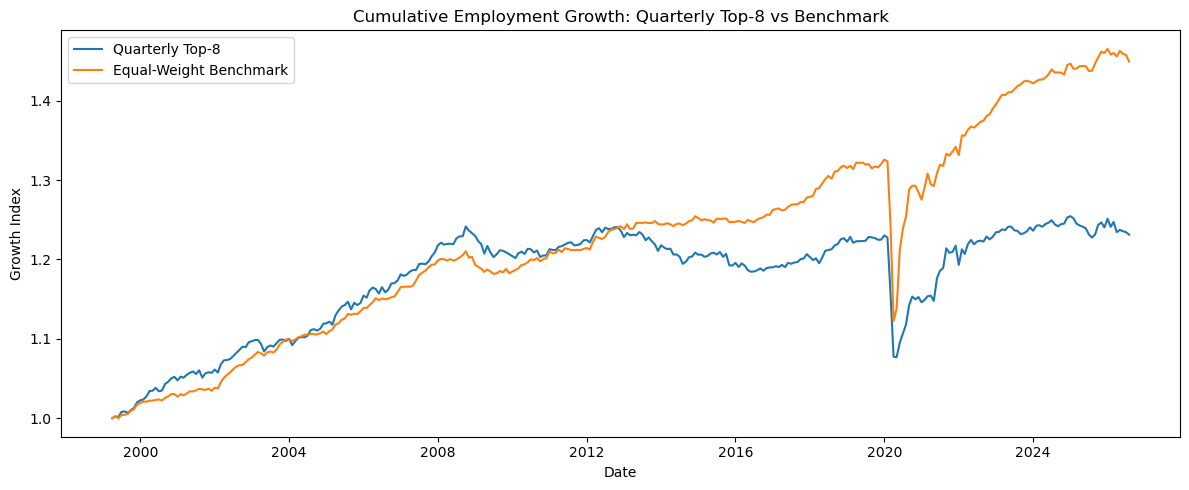

In [89]:
# ============================================================
# CUMULATIVE TOP-8 VS BENCHMARK
# ============================================================

# Convert monthly employment growth into growth multipliers.
top8_multiplier = (
    1 + top8_comparison["Top8_Portfolio_Growth"] / 100
)

benchmark_multiplier = (
    1 + top8_comparison["Benchmark_Growth"] / 100
)

# Build cumulative employment-growth indices.
top8_comparison["Top8_Index"] = (
    top8_multiplier.cumprod()
)

top8_comparison["Benchmark_Index"] = (
    benchmark_multiplier.cumprod()
)

print("CUMULATIVE TOP-8 VS BENCHMARK")
print("=" * 60)

print(
    "Final top-8 index:",
    round(
        top8_comparison["Top8_Index"].iloc[-1],
        3
    )
)

print(
    "Final benchmark index:",
    round(
        top8_comparison["Benchmark_Index"].iloc[-1],
        3
    )
)

display(
    top8_comparison.tail()
)

# Plot cumulative performance.
plt.figure(figsize=(12, 5))

plt.plot(
    top8_comparison.index,
    top8_comparison["Top8_Index"],
    label="Quarterly Top-8"
)

plt.plot(
    top8_comparison.index,
    top8_comparison["Benchmark_Index"],
    label="Equal-Weight Benchmark"
)

plt.title(
    "Cumulative Employment Growth: Quarterly Top-8 vs Benchmark"
)

plt.xlabel("Date")
plt.ylabel("Growth Index")

plt.legend()

plt.tight_layout()
plt.show()

In [90]:
# ============================================================
# BUILD STRENGTH-TILTED PORTFOLIO
# ============================================================

# Convert the strength score into positive portfolio signals.
# A score of zero represents the cross-sectional average.
positive_strength = (
    industry_strength_score
    - industry_strength_score.min(axis=1).values[:, None]
)

# Add a small constant so every industry receives
# a non-zero base allocation.
positive_strength = positive_strength + 0.10

# Normalize each month so all portfolio weights sum to 100%.
tilt_weights = positive_strength.div(
    positive_strength.sum(axis=1),
    axis=0
)

# Rebalance quarterly to reduce unnecessary trading.
tilt_rebalance_dates = tilt_weights.index[
    np.arange(len(tilt_weights)) % 3 == 0
]

quarterly_tilt_weights = (
    tilt_weights
    .loc[tilt_rebalance_dates]
    .reindex(
        tilt_weights.index,
        method="ffill"
    )
)

# Lag the weights by one month to prevent look-ahead bias.
lagged_tilt_weights = (
    quarterly_tilt_weights.shift(1)
)

print("STRENGTH-TILTED PORTFOLIO")
print("=" * 60)

print(
    "Rebalance dates:",
    len(tilt_rebalance_dates)
)

print(
    "Portfolio months:",
    len(lagged_tilt_weights.dropna(how="all"))
)

print(
    "Maximum individual weight:",
    round(
        lagged_tilt_weights.max().max(),
        4
    )
)

print(
    "Minimum individual weight:",
    round(
        lagged_tilt_weights.min().min(),
        4
    )
)

display(
    lagged_tilt_weights.tail()
)

STRENGTH-TILTED PORTFOLIO
Rebalance dates: 110
Portfolio months: 328
Maximum individual weight: 0.2267
Minimum individual weight: 0.0019


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,0.045777,0.119814,0.017646,0.054629,0.022275,0.061902,0.084537,0.096523,0.104209,0.005569,0.092855,0.010771,0.045754,0.033128,0.161139,0.043472
2026-05-01,0.069298,0.005447,0.069948,0.026501,0.035620,0.032842,0.105847,0.115619,0.019243,0.053470,0.051316,0.059873,0.062394,0.072329,0.165717,0.054536
2026-06-01,0.069298,0.005447,0.069948,0.026501,0.035620,0.032842,0.105847,0.115619,0.019243,0.053470,0.051316,0.059873,0.062394,0.072329,0.165717,0.054536
2026-07-01,0.069298,0.005447,0.069948,0.026501,0.035620,0.032842,0.105847,0.115619,0.019243,0.053470,0.051316,0.059873,0.062394,0.072329,0.165717,0.054536
2026-08-01,0.085507,0.013860,0.132448,0.076894,0.005457,0.042024,0.043154,0.111855,0.124163,0.036700,0.099450,0.058559,0.028519,0.108590,0.015715,0.017106


In [91]:
# ============================================================
# CALCULATE STRENGTH-TILTED PORTFOLIO GROWTH
# ============================================================

# Align monthly industry employment growth with
# the lagged portfolio weights.
tilt_growth_data = monthly_industry_growth.loc[
    lagged_tilt_weights.index
]

# Calculate portfolio employment growth using
# the strength-based industry weights.
strength_tilt_growth = (
    lagged_tilt_weights *
    tilt_growth_data
).sum(axis=1)

# Remove the initial period with no prior weights.
strength_tilt_growth = (
    strength_tilt_growth.dropna()
)

print("STRENGTH-TILTED PORTFOLIO GROWTH")
print("=" * 60)

print(
    "Average monthly employment growth:",
    round(
        strength_tilt_growth.mean(),
        4
    ),
    "%"
)

print(
    "Standard deviation:",
    round(
        strength_tilt_growth.std(),
        4
    ),
    "%"
)

print(
    "Observations:",
    len(strength_tilt_growth)
)

display(
    strength_tilt_growth.head()
)

STRENGTH-TILTED PORTFOLIO GROWTH
Average monthly employment growth: 0.0889 %
Standard deviation: 0.7916 %
Observations: 329


Date
1999-04-01    0.000000
1999-05-01    0.294138
1999-06-01   -0.096113
1999-07-01    0.537122
1999-08-01    0.007533
dtype: float64

In [93]:
# ============================================================
# COMPARE STRENGTH-TILTED PORTFOLIO WITH BENCHMARK
# ============================================================

# Build an equal-weight benchmark across all 16 industries.
# Each industry receives the same allocation.
benchmark_weights = pd.DataFrame(
    1 / industry_matrix_strategy.shape[1],
    index=industry_matrix_strategy.index,
    columns=industry_matrix_strategy.columns
)

# Lag the benchmark weights by one month to prevent
# look-ahead bias.
benchmark_weights = benchmark_weights.shift(1)

# Calculate the benchmark's monthly employment growth.
benchmark_growth = (
    benchmark_weights *
    monthly_industry_growth.loc[benchmark_weights.index]
).sum(axis=1)

# Align both strategies over the same dates.
comparison = pd.concat(
    [
        strength_tilt_growth,
        benchmark_growth
    ],
    axis=1
)

comparison.columns = [
    "Strength-Tilted Portfolio",
    "Equal-Weight Benchmark"
]

comparison = comparison.dropna()

# Calculate the monthly excess employment growth.
excess_growth = (
    comparison["Strength-Tilted Portfolio"]
    - comparison["Equal-Weight Benchmark"]
)

print("STRENGTH-TILTED VS BENCHMARK")
print("=" * 60)

print(
    "Strategy average monthly growth:",
    round(comparison["Strength-Tilted Portfolio"].mean(), 4),
    "%"
)

print(
    "Benchmark average monthly growth:",
    round(comparison["Equal-Weight Benchmark"].mean(), 4),
    "%"
)

print(
    "Average monthly excess growth:",
    round(excess_growth.mean(), 4),
    "percentage points"
)

print(
    "Months outperforming:",
    (excess_growth > 0).sum()
)

print(
    "Months underperforming:",
    (excess_growth < 0).sum()
)

print(
    "Observations:",
    len(comparison)
)

STRENGTH-TILTED VS BENCHMARK
Strategy average monthly growth: 0.0889 %
Benchmark average monthly growth: 0.1164 %
Average monthly excess growth: -0.0275 percentage points
Months outperforming: 163
Months underperforming: 165
Observations: 329


CUMULATIVE EMPLOYMENT GROWTH
Final strategy index: 1.325
Final benchmark index: 1.449
Strategy cumulative growth: 32.53 %
Benchmark cumulative growth: 44.93 %


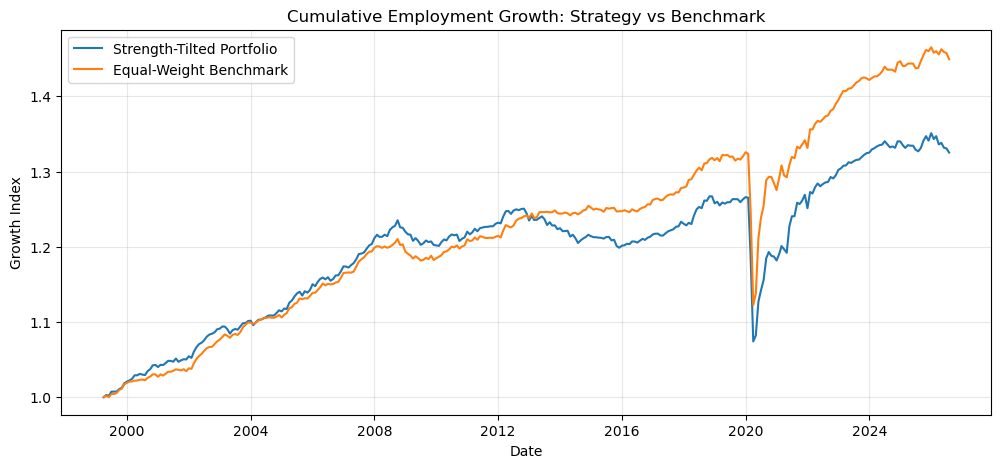

In [94]:
# ============================================================
# CUMULATIVE EMPLOYMENT GROWTH
# ============================================================

# Convert monthly employment growth into cumulative growth
# indices starting at 1.0.
strategy_index = (
    1 + comparison["Strength-Tilted Portfolio"] / 100
).cumprod()

benchmark_index = (
    1 + comparison["Equal-Weight Benchmark"] / 100
).cumprod()

print("CUMULATIVE EMPLOYMENT GROWTH")
print("=" * 60)

print(
    "Final strategy index:",
    round(strategy_index.iloc[-1], 3)
)

print(
    "Final benchmark index:",
    round(benchmark_index.iloc[-1], 3)
)

print(
    "Strategy cumulative growth:",
    round((strategy_index.iloc[-1] - 1) * 100, 2),
    "%"
)

print(
    "Benchmark cumulative growth:",
    round((benchmark_index.iloc[-1] - 1) * 100, 2),
    "%"
)

# Plot the two cumulative paths.
plt.figure(figsize=(12, 5))

plt.plot(
    strategy_index,
    label="Strength-Tilted Portfolio"
)

plt.plot(
    benchmark_index,
    label="Equal-Weight Benchmark"
)

plt.title(
    "Cumulative Employment Growth: Strategy vs Benchmark"
)

plt.xlabel("Date")
plt.ylabel("Growth Index")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

DRAWDOWN COMPARISON
Strategy maximum drawdown: -15.23 %
Benchmark maximum drawdown: -15.32 %
Strategy average drawdown: -1.19 %
Benchmark average drawdown: -0.47 %


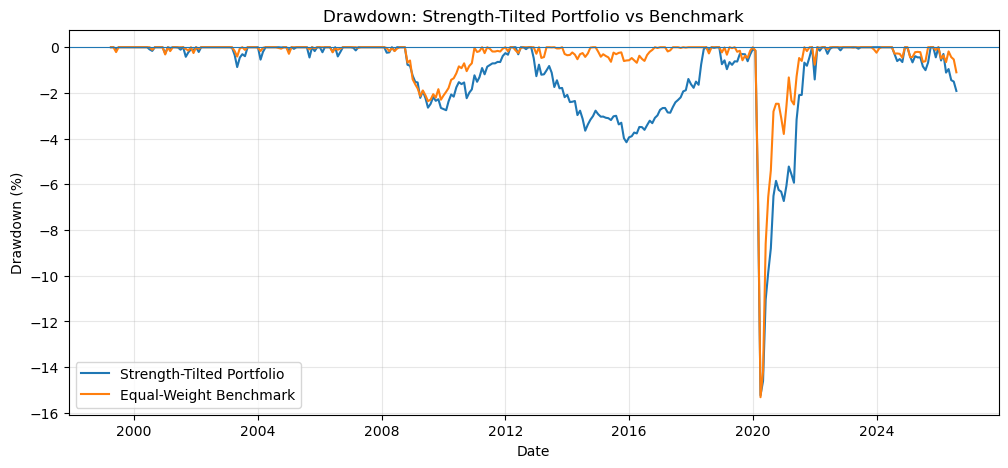

In [95]:
# ============================================================
# DRAWDOWN COMPARISON
# ============================================================

# Calculate the running peak of each cumulative index.
strategy_peak = strategy_index.cummax()
benchmark_peak = benchmark_index.cummax()

# Drawdown measures the percentage decline from the
# previous cumulative peak.
strategy_drawdown = (
    strategy_index / strategy_peak - 1
) * 100

benchmark_drawdown = (
    benchmark_index / benchmark_peak - 1
) * 100

print("DRAWDOWN COMPARISON")
print("=" * 60)

print(
    "Strategy maximum drawdown:",
    round(strategy_drawdown.min(), 2),
    "%"
)

print(
    "Benchmark maximum drawdown:",
    round(benchmark_drawdown.min(), 2),
    "%"
)

print(
    "Strategy average drawdown:",
    round(strategy_drawdown.mean(), 2),
    "%"
)

print(
    "Benchmark average drawdown:",
    round(benchmark_drawdown.mean(), 2),
    "%"
)

# Plot the drawdown paths.
plt.figure(figsize=(12, 5))

plt.plot(
    strategy_drawdown,
    label="Strength-Tilted Portfolio"
)

plt.plot(
    benchmark_drawdown,
    label="Equal-Weight Benchmark"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.title(
    "Drawdown: Strength-Tilted Portfolio vs Benchmark"
)

plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [96]:
# ============================================================
# RISK-ADJUSTED PERFORMANCE
# ============================================================

# Calculate average growth relative to volatility.
# This is a simple Sharpe-like ratio using employment growth,
# not financial returns.
strategy_ratio = (
    comparison["Strength-Tilted Portfolio"].mean()
    / comparison["Strength-Tilted Portfolio"].std()
)

benchmark_ratio = (
    comparison["Equal-Weight Benchmark"].mean()
    / comparison["Equal-Weight Benchmark"].std()
)

print("RISK-ADJUSTED PERFORMANCE")
print("=" * 60)

print(
    "Strategy growth/volatility ratio:",
    round(strategy_ratio, 4)
)

print(
    "Benchmark growth/volatility ratio:",
    round(benchmark_ratio, 4)
)

RISK-ADJUSTED PERFORMANCE
Strategy growth/volatility ratio: 0.1123
Benchmark growth/volatility ratio: 0.1406


In [98]:
# ============================================================
# STRATEGY PERFORMANCE BY CERI REGIME
# ============================================================

# Combine portfolio performance with the CERI index.
# Use the lowercase variable name created earlier.
regime_data = pd.concat(
    [
        comparison,
        ceri.rename("CERI")
    ],
    axis=1
).dropna()

# Classify each month using the previously established
# empirical CERI thresholds.
regime_data["CERI Regime"] = pd.cut(
    regime_data["CERI"],
    bins=[-np.inf, 43.75, 56.25, np.inf],
    labels=[
        "Weak Rotation",
        "Broad Rotation",
        "Balanced Rotation"
    ]
)

# Compare strategy and benchmark performance within
# each economic rotation regime.
regime_summary = regime_data.groupby(
    "CERI Regime",
    observed=False
).agg(
    Strategy_Avg_Growth=(
        "Strength-Tilted Portfolio",
        "mean"
    ),
    Benchmark_Avg_Growth=(
        "Equal-Weight Benchmark",
        "mean"
    ),
    Months=(
        "Strength-Tilted Portfolio",
        "count"
    )
)

# Calculate the strategy's excess growth within
# each CERI regime.
regime_summary["Excess_Growth"] = (
    regime_summary["Strategy_Avg_Growth"]
    - regime_summary["Benchmark_Avg_Growth"]
)

print("STRATEGY PERFORMANCE BY CERI REGIME")
print("=" * 60)

display(
    regime_summary.round(4)
)

STRATEGY PERFORMANCE BY CERI REGIME


,Strategy_Avg_Growth,Benchmark_Avg_Growth,Months,Excess_Growth
CERI Regime,,,,
Weak Rotation,0.1586,0.1717,125,-0.0131
Broad Rotation,0.0309,0.0515,164,-0.0206
Balanced Rotation,0.1088,0.2095,40,-0.1007


In [99]:
# ============================================================
# INDUSTRY STRENGTH QUINTILE TEST
# ============================================================

# Combine the current industry strength score with
# subsequent 12-month employment growth.
quintile_data = pd.DataFrame({
    "Current_Score": industry_strength_score.stack(),
    "Future_12M_Growth": forward_12m_growth.stack()
}).dropna()

# Rank industries each month into five groups.
# Q1 = weakest current industries
# Q5 = strongest current industries
quintile_data["Quintile"] = (
    quintile_data.groupby(level=0)["Current_Score"]
    .transform(
        lambda x: pd.qcut(
            x,
            5,
            labels=False,
            duplicates="drop"
        ) + 1
    )
)

# Calculate future employment growth for each score quintile.
quintile_summary = (
    quintile_data
    .groupby("Quintile")["Future_12M_Growth"]
    .agg(
        Average_Growth="mean",
        Median_Growth="median",
        Observations="count"
    )
)

print("INDUSTRY STRENGTH QUINTILE TEST")
print("=" * 60)

display(
    quintile_summary.round(4)
)

INDUSTRY STRENGTH QUINTILE TEST


,Average_Growth,Median_Growth,Observations
Quintile,,,
1,1.3456,1.7339,1268
2,1.5633,1.7467,951
3,1.4256,1.6638,951
4,1.5316,1.7171,951
5,1.0297,0.9595,951


In [100]:
# ============================================================
# CONTRARIAN QUINTILE TEST
# ============================================================

# Compare the weakest and strongest industries directly.
# This tests whether industries with weaker current scores
# subsequently experience stronger employment growth.

q1_growth = quintile_data.loc[
    quintile_data["Quintile"] == 1,
    "Future_12M_Growth"
]

q5_growth = quintile_data.loc[
    quintile_data["Quintile"] == 5,
    "Future_12M_Growth"
]

contrarian_spread = (
    q1_growth.mean()
    - q5_growth.mean()
)

print("CONTRARIAN QUINTILE TEST")
print("=" * 60)

print(
    "Weakest quintile average future growth:",
    round(q1_growth.mean(), 4),
    "%"
)

print(
    "Strongest quintile average future growth:",
    round(q5_growth.mean(), 4),
    "%"
)

print(
    "Q1 minus Q5 spread:",
    round(contrarian_spread, 4),
    "percentage points"
)

print(
    "Interpretation:",
    "Positive spread supports a contrarian relationship."
    if contrarian_spread > 0
    else
    "Negative spread does not support a contrarian relationship."
)

CONTRARIAN QUINTILE TEST
Weakest quintile average future growth: 1.3456 %
Strongest quintile average future growth: 1.0297 %
Q1 minus Q5 spread: 0.3159 percentage points
Interpretation: Positive spread supports a contrarian relationship.


In [101]:
# ============================================================
# STATISTICAL TEST: CONTRARIAN Q1 VS Q5
# ============================================================

from scipy.stats import ttest_ind

# Compare future 12-month employment growth between
# the weakest and strongest current-score quintiles.
t_stat, p_value = ttest_ind(
    q1_growth,
    q5_growth,
    equal_var=False,
    nan_policy="omit"
)

print("STATISTICAL TEST: Q1 VS Q5")
print("=" * 60)

print(
    "Q1 average future growth:",
    round(q1_growth.mean(), 4),
    "%"
)

print(
    "Q5 average future growth:",
    round(q5_growth.mean(), 4),
    "%"
)

print(
    "Q1 minus Q5 spread:",
    round(q1_growth.mean() - q5_growth.mean(), 4),
    "percentage points"
)

print(
    "t-statistic:",
    round(t_stat, 4)
)

print(
    "p-value:",
    round(p_value, 6)
)

print(
    "Statistically significant at 5%:",
    "Yes" if p_value < 0.05 else "No"
)

STATISTICAL TEST: Q1 VS Q5
Q1 average future growth: 1.3456 %
Q5 average future growth: 1.0297 %
Q1 minus Q5 spread: 0.3159 percentage points
t-statistic: 1.3992
p-value: 0.161899
Statistically significant at 5%: No


In [102]:
# ============================================================
# CONTRARIAN TEST: 3-MONTH HORIZON
# ============================================================

# Create future 3-month employment growth for the
# same industry-month observations used in the score.
quintile_3m_data = pd.DataFrame({
    "Current_Score": industry_strength_score.stack(),
    "Future_3M_Growth": forward_3m_growth.stack()
}).dropna()

# Rank industries into five cross-sectional score quintiles.
quintile_3m_data["Quintile"] = (
    quintile_3m_data.groupby(level=0)["Current_Score"]
    .transform(
        lambda x: pd.qcut(
            x,
            5,
            labels=False,
            duplicates="drop"
        ) + 1
    )
)

# Extract weakest and strongest quintiles.
q1_3m = quintile_3m_data.loc[
    quintile_3m_data["Quintile"] == 1,
    "Future_3M_Growth"
]

q5_3m = quintile_3m_data.loc[
    quintile_3m_data["Quintile"] == 5,
    "Future_3M_Growth"
]

# Test whether the weakest group outperforms
# the strongest group over the next 3 months.
t_stat_3m, p_value_3m = ttest_ind(
    q1_3m,
    q5_3m,
    equal_var=False,
    nan_policy="omit"
)

print("CONTRARIAN TEST: 3-MONTH HORIZON")
print("=" * 60)

print(
    "Weakest quintile future growth:",
    round(q1_3m.mean(), 4),
    "%"
)

print(
    "Strongest quintile future growth:",
    round(q5_3m.mean(), 4),
    "%"
)

print(
    "Q1 minus Q5 spread:",
    round(q1_3m.mean() - q5_3m.mean(), 4),
    "percentage points"
)

print(
    "t-statistic:",
    round(t_stat_3m, 4)
)

print(
    "p-value:",
    round(p_value_3m, 6)
)

print(
    "Statistically significant at 5%:",
    "Yes" if p_value_3m < 0.05 else "No"
)

CONTRARIAN TEST: 3-MONTH HORIZON
Weakest quintile future growth: 0.5197 %
Strongest quintile future growth: 0.2065 %
Q1 minus Q5 spread: 0.3132 percentage points
t-statistic: 2.27
p-value: 0.023303
Statistically significant at 5%: Yes


In [103]:
# ============================================================
# CONTRARIAN SIGNAL ACROSS MULTIPLE HORIZONS
# ============================================================

# Test whether the weakest current-score quintile
# outperforms the strongest quintile at different
# forward employment-growth horizons.

horizons = [3, 6, 9, 12]

results = []

for horizon in horizons:

    # Calculate forward employment growth.
    future_growth = (
        industry_matrix_strategy.shift(-horizon)
        .div(industry_matrix_strategy)
        .sub(1)
        * 100
    )

    # Combine current score with future growth.
    test_data = pd.DataFrame({
        "Score": industry_strength_score.stack(),
        "Future_Growth": future_growth.stack()
    }).dropna()

    # Rank industries cross-sectionally each month.
    test_data["Quintile"] = (
        test_data.groupby(level=0)["Score"]
        .transform(
            lambda x: pd.qcut(
                x,
                5,
                labels=False,
                duplicates="drop"
            ) + 1
        )
    )

    q1 = test_data.loc[
        test_data["Quintile"] == 1,
        "Future_Growth"
    ]

    q5 = test_data.loc[
        test_data["Quintile"] == 5,
        "Future_Growth"
    ]

    # Welch's t-test for the Q1 vs Q5 difference.
    t_stat, p_value = ttest_ind(
        q1,
        q5,
        equal_var=False,
        nan_policy="omit"
    )

    results.append({
        "Horizon_Months": horizon,
        "Q1_Avg_Growth": q1.mean(),
        "Q5_Avg_Growth": q5.mean(),
        "Q1_Q5_Spread": q1.mean() - q5.mean(),
        "t_statistic": t_stat,
        "p_value": p_value
    })

horizon_results = pd.DataFrame(results)

print("CONTRARIAN SIGNAL ACROSS MULTIPLE HORIZONS")
print("=" * 60)

display(
    horizon_results.round(4)
)

CONTRARIAN SIGNAL ACROSS MULTIPLE HORIZONS


,Horizon_Months,Q1_Avg_Growth,Q5_Avg_Growth,Q1_Q5_Spread,t_statistic,p_value
0,3,0.5197,0.2065,0.3132,2.2700,0.0233
1,6,0.8366,0.5260,0.3106,1.8371,0.0663
2,9,0.9206,0.9167,0.0039,0.0207,0.9835
3,12,1.3456,1.0297,0.3159,1.3992,0.1619


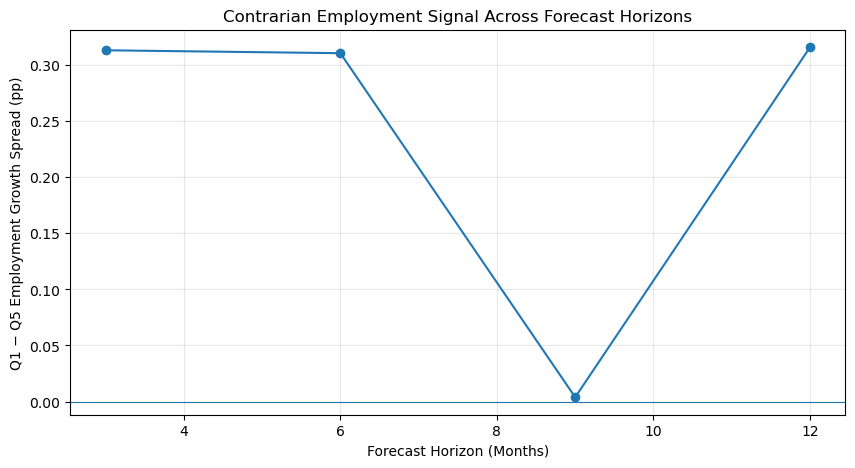

In [104]:
# ============================================================
# CONTRARIAN SIGNAL BY FORECAST HORIZON
# ============================================================

# Plot the Q1-minus-Q5 employment-growth spread across
# different forecasting horizons.
plt.figure(figsize=(10, 5))

plt.plot(
    horizon_results["Horizon_Months"],
    horizon_results["Q1_Q5_Spread"],
    marker="o"
)

# A zero line separates positive and negative spreads.
plt.axhline(
    0,
    linewidth=0.8
)

plt.title(
    "Contrarian Employment Signal Across Forecast Horizons"
)

plt.xlabel("Forecast Horizon (Months)")
plt.ylabel("Q1 − Q5 Employment Growth Spread (pp)")

plt.grid(True, alpha=0.3)

plt.show()

In [105]:
# ============================================================
# BUILD 3-MONTH CONTRARIAN PORTFOLIO
# ============================================================

# Rank industries each month by the current employment
# strength score.
# Lower scores = weaker industries = contrarian candidates.
score_rank = industry_strength_score.rank(
    axis=1,
    ascending=True,
    method="first"
)

# Select the 4 weakest industries each month.
# These are the industries expected to benefit from
# short-term mean reversion according to our test.
contrarian_weights = (
    score_rank <= 4
).astype(float)

# Convert the selected industries into equal weights.
contrarian_weights = (
    contrarian_weights.div(
        contrarian_weights.sum(axis=1),
        axis=0
    )
)

# Rebalance quarterly, matching the strongest
# statistically significant forecast horizon.
contrarian_rebalance_dates = contrarian_weights.index[
    np.arange(len(contrarian_weights)) % 3 == 0
]

quarterly_contrarian_weights = (
    contrarian_weights
    .loc[contrarian_rebalance_dates]
    .reindex(
        contrarian_weights.index,
        method="ffill"
    )
)

# Lag the portfolio by one month to prevent look-ahead bias.
lagged_contrarian_weights = (
    quarterly_contrarian_weights.shift(1)
)

print("3-MONTH CONTRARIAN PORTFOLIO")
print("=" * 60)

print(
    "Rebalance dates:",
    len(contrarian_rebalance_dates)
)

print(
    "Average industries held:",
    round(
        (lagged_contrarian_weights > 0).sum(axis=1).mean(),
        2
    )
)

print(
    "Maximum individual weight:",
    round(
        lagged_contrarian_weights.max().max(),
        4
    )
)

display(
    lagged_contrarian_weights.tail()
)

3-MONTH CONTRARIAN PORTFOLIO
Rebalance dates: 110
Average industries held: 3.99
Maximum individual weight: 0.25


North American Industry Classification System (NAICS),Accommodation and food services [72],"Agriculture [111-112, 1100, 1151-1152]","Business, building and other support services [55-56]",Construction [23],Educational services [61],"Finance, insurance, real estate, rental and leasing [52-53]","Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",Health care and social assistance [62],"Information, culture and recreation [51, 71]",Manufacturing [31-33],Other services (except public administration) [81],"Professional, scientific and technical services [54]",Public administration [91],Transportation and warehousing [48-49],Utilities [22],"Wholesale and retail trade [41, 44-45]"
Date,,,,,,,,,,,,,,,,
2026-04-01,0.0,0.00,0.25,0.00,0.25,0.00,0.0,0.0,0.00,0.25,0.0,0.25,0.0,0.0,0.00,0.00
2026-05-01,0.0,0.25,0.00,0.25,0.00,0.25,0.0,0.0,0.25,0.00,0.0,0.00,0.0,0.0,0.00,0.00
2026-06-01,0.0,0.25,0.00,0.25,0.00,0.25,0.0,0.0,0.25,0.00,0.0,0.00,0.0,0.0,0.00,0.00
2026-07-01,0.0,0.25,0.00,0.25,0.00,0.25,0.0,0.0,0.25,0.00,0.0,0.00,0.0,0.0,0.00,0.00
2026-08-01,0.0,0.25,0.00,0.00,0.25,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.25,0.25


In [106]:
# ============================================================
# CALCULATE 3-MONTH CONTRARIAN PORTFOLIO GROWTH
# ============================================================

# Align monthly industry employment growth with the
# lagged contrarian portfolio weights.
contrarian_growth = (
    lagged_contrarian_weights
    * monthly_industry_growth.loc[
        lagged_contrarian_weights.index
    ]
).sum(axis=1)

# Remove periods where no lagged portfolio exists.
contrarian_growth = contrarian_growth.dropna()

print("3-MONTH CONTRARIAN PORTFOLIO GROWTH")
print("=" * 60)

print(
    "Average monthly employment growth:",
    round(contrarian_growth.mean(), 4),
    "%"
)

print(
    "Standard deviation:",
    round(contrarian_growth.std(), 4),
    "%"
)

print(
    "Observations:",
    len(contrarian_growth)
)

display(
    contrarian_growth.head()
)

3-MONTH CONTRARIAN PORTFOLIO GROWTH
Average monthly employment growth: 0.1942 %
Standard deviation: 1.4488 %
Observations: 329


Date
1999-04-01    0.000000
1999-05-01   -0.155554
1999-06-01   -0.703989
1999-07-01   -0.095059
1999-08-01    0.154882
dtype: float64

In [107]:
# ============================================================
# CONTRARIAN PORTFOLIO VS BENCHMARK
# ============================================================

# Align the contrarian portfolio with the equal-weight benchmark.
contrarian_comparison = pd.concat(
    [
        contrarian_growth,
        benchmark_growth
    ],
    axis=1
)

contrarian_comparison.columns = [
    "Contrarian Portfolio",
    "Equal-Weight Benchmark"
]

contrarian_comparison = (
    contrarian_comparison
    .dropna()
)

# Calculate monthly excess employment growth.
contrarian_excess = (
    contrarian_comparison["Contrarian Portfolio"]
    - contrarian_comparison["Equal-Weight Benchmark"]
)

# Calculate a simple growth-to-volatility ratio.
contrarian_ratio = (
    contrarian_comparison["Contrarian Portfolio"].mean()
    / contrarian_comparison["Contrarian Portfolio"].std()
)

benchmark_ratio = (
    contrarian_comparison["Equal-Weight Benchmark"].mean()
    / contrarian_comparison["Equal-Weight Benchmark"].std()
)

print("CONTRARIAN PORTFOLIO VS BENCHMARK")
print("=" * 60)

print(
    "Strategy average monthly growth:",
    round(
        contrarian_comparison["Contrarian Portfolio"].mean(),
        4
    ),
    "%"
)

print(
    "Benchmark average monthly growth:",
    round(
        contrarian_comparison["Equal-Weight Benchmark"].mean(),
        4
    ),
    "%"
)

print(
    "Average monthly excess growth:",
    round(
        contrarian_excess.mean(),
        4
    ),
    "percentage points"
)

print(
    "Months outperforming:",
    (contrarian_excess > 0).sum()
)

print(
    "Months underperforming:",
    (contrarian_excess < 0).sum()
)

print(
    "Strategy growth/volatility ratio:",
    round(
        contrarian_ratio,
        4
    )
)

print(
    "Benchmark growth/volatility ratio:",
    round(
        benchmark_ratio,
        4
    )
)

print(
    "Observations:",
    len(contrarian_comparison)
)

CONTRARIAN PORTFOLIO VS BENCHMARK
Strategy average monthly growth: 0.1942 %
Benchmark average monthly growth: 0.1164 %
Average monthly excess growth: 0.0779 percentage points
Months outperforming: 168
Months underperforming: 160
Strategy growth/volatility ratio: 0.1341
Benchmark growth/volatility ratio: 0.1406
Observations: 329


In [108]:
# ============================================================
# STATISTICAL TEST: CONTRARIAN PORTFOLIO EXCESS GROWTH
# ============================================================

# Test whether the average monthly excess employment growth
# of the contrarian portfolio is significantly different from zero.
t_stat_contrarian, p_value_contrarian = ttest_ind(
    contrarian_comparison["Contrarian Portfolio"],
    contrarian_comparison["Equal-Weight Benchmark"],
    equal_var=False,
    nan_policy="omit"
)

print("STATISTICAL TEST: CONTRARIAN PORTFOLIO")
print("=" * 60)

print(
    "Average strategy growth:",
    round(
        contrarian_comparison["Contrarian Portfolio"].mean(),
        4
    ),
    "%"
)

print(
    "Average benchmark growth:",
    round(
        contrarian_comparison["Equal-Weight Benchmark"].mean(),
        4
    ),
    "%"
)

print(
    "Average excess growth:",
    round(
        contrarian_excess.mean(),
        4
    ),
    "percentage points"
)

print(
    "t-statistic:",
    round(
        t_stat_contrarian,
        4
    )
)

print(
    "p-value:",
    round(
        p_value_contrarian,
        6
    )
)

print(
    "Statistically significant at 5%:",
    "Yes"
    if p_value_contrarian < 0.05
    else
    "No"
)

STATISTICAL TEST: CONTRARIAN PORTFOLIO
Average strategy growth: 0.1942 %
Average benchmark growth: 0.1164 %
Average excess growth: 0.0779 percentage points
t-statistic: 0.8464
p-value: 0.397691
Statistically significant at 5%: No


CUMULATIVE CONTRARIAN PORTFOLIO
Final contrarian index: 1.83
Final benchmark index: 1.449
Contrarian cumulative growth: 82.99 %
Benchmark cumulative growth: 44.93 %


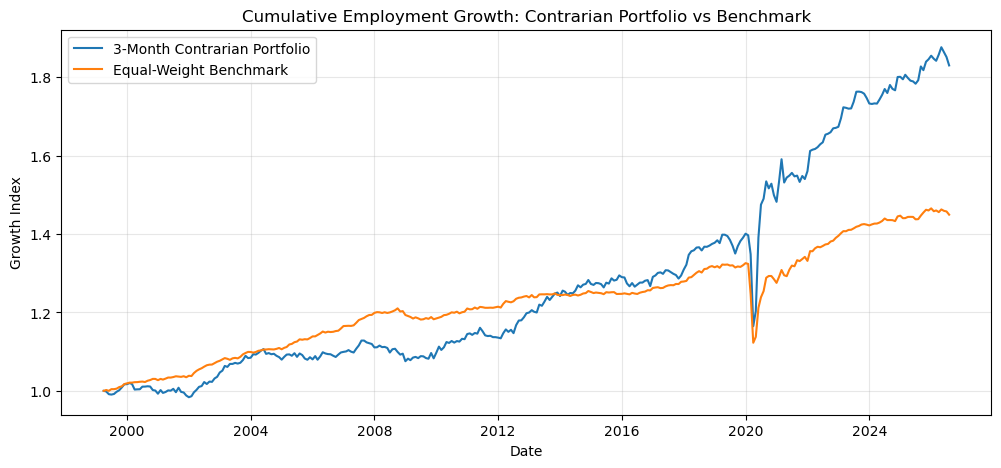

In [109]:
# ============================================================
# CUMULATIVE CONTRARIAN PORTFOLIO
# ============================================================

# Convert monthly employment growth into a cumulative index.
# The index starts at 1.0 for easy comparison.
contrarian_index = (
    1 + contrarian_comparison["Contrarian Portfolio"] / 100
).cumprod()

benchmark_index_contrarian = (
    1 + contrarian_comparison["Equal-Weight Benchmark"] / 100
).cumprod()

print("CUMULATIVE CONTRARIAN PORTFOLIO")
print("=" * 60)

print(
    "Final contrarian index:",
    round(
        contrarian_index.iloc[-1],
        3
    )
)

print(
    "Final benchmark index:",
    round(
        benchmark_index_contrarian.iloc[-1],
        3
    )
)

print(
    "Contrarian cumulative growth:",
    round(
        (contrarian_index.iloc[-1] - 1) * 100,
        2
    ),
    "%"
)

print(
    "Benchmark cumulative growth:",
    round(
        (benchmark_index_contrarian.iloc[-1] - 1) * 100,
        2
    ),
    "%"
)

# Plot cumulative employment growth.
plt.figure(figsize=(12, 5))

plt.plot(
    contrarian_index,
    label="3-Month Contrarian Portfolio"
)

plt.plot(
    benchmark_index_contrarian,
    label="Equal-Weight Benchmark"
)

plt.title(
    "Cumulative Employment Growth: Contrarian Portfolio vs Benchmark"
)

plt.xlabel("Date")
plt.ylabel("Growth Index")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

CONTRARIAN PORTFOLIO DRAWDOWN
Contrarian maximum drawdown: -16.83 %
Benchmark maximum drawdown: -15.32 %
Contrarian average drawdown: -1.05 %
Benchmark average drawdown: -0.47 %


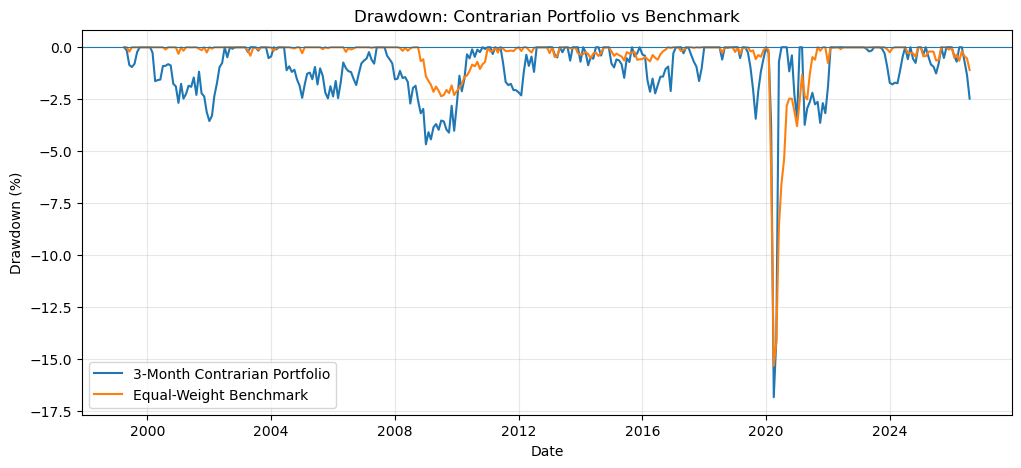

In [110]:
# ============================================================
# CONTRARIAN PORTFOLIO DRAWDOWN
# ============================================================

# Calculate the running peak of the contrarian cumulative index.
contrarian_peak = contrarian_index.cummax()

# Measure percentage decline from the previous peak.
contrarian_drawdown = (
    contrarian_index / contrarian_peak - 1
) * 100

# Calculate the benchmark drawdown on the same dates.
benchmark_peak_contrarian = (
    benchmark_index_contrarian.cummax()
)

benchmark_drawdown_contrarian = (
    benchmark_index_contrarian
    / benchmark_peak_contrarian
    - 1
) * 100

print("CONTRARIAN PORTFOLIO DRAWDOWN")
print("=" * 60)

print(
    "Contrarian maximum drawdown:",
    round(
        contrarian_drawdown.min(),
        2
    ),
    "%"
)

print(
    "Benchmark maximum drawdown:",
    round(
        benchmark_drawdown_contrarian.min(),
        2
    ),
    "%"
)

print(
    "Contrarian average drawdown:",
    round(
        contrarian_drawdown.mean(),
        2
    ),
    "%"
)

print(
    "Benchmark average drawdown:",
    round(
        benchmark_drawdown_contrarian.mean(),
        2
    ),
    "%"
)

# Plot drawdown paths.
plt.figure(figsize=(12, 5))

plt.plot(
    contrarian_drawdown,
    label="3-Month Contrarian Portfolio"
)

plt.plot(
    benchmark_drawdown_contrarian,
    label="Equal-Weight Benchmark"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.title(
    "Drawdown: Contrarian Portfolio vs Benchmark"
)

plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [111]:
# ============================================================
# CONTRARIAN PORTFOLIO TURNOVER
# ============================================================

# Measure how much portfolio weight changes from one month
# to the next. This captures trading caused by industry rotation.
contrarian_turnover = (
    lagged_contrarian_weights
    .diff()
    .abs()
    .sum(axis=1)
)

contrarian_turnover = contrarian_turnover.dropna()

print("CONTRARIAN PORTFOLIO TURNOVER")
print("=" * 60)

print(
    "Average monthly turnover:",
    round(
        contrarian_turnover.mean() * 100,
        2
    ),
    "%"
)

print(
    "Median monthly turnover:",
    round(
        contrarian_turnover.median() * 100,
        2
    ),
    "%"
)

print(
    "Maximum monthly turnover:",
    round(
        contrarian_turnover.max() * 100,
        2
    ),
    "%"
)

print(
    "Observations:",
    len(contrarian_turnover)
)

CONTRARIAN PORTFOLIO TURNOVER
Average monthly turnover: 36.47 %
Median monthly turnover: 0.0 %
Maximum monthly turnover: 200.0 %
Observations: 329


In [112]:
# ============================================================
# CONTRARIAN TRANSACTION COST SENSITIVITY
# ============================================================

# Test several one-way transaction-cost assumptions.
# Turnover is measured as total portfolio weight traded.
cost_rates = [0.001, 0.0025, 0.005]

print("CONTRARIAN TRANSACTION-COST SENSITIVITY")
print("=" * 60)

for cost_rate in cost_rates:

    # Transaction cost each month.
    monthly_cost = (
        contrarian_turnover * cost_rate
    )

    # Approximate annualized cost using the average monthly cost.
    annual_cost = (
        monthly_cost.mean() * 12 * 100
    )

    print(
        f"One-way cost: {cost_rate * 100:.2f}%"
    )

    print(
        "Average annual cost impact:",
        round(annual_cost, 2),
        "%"
    )

    print()

CONTRARIAN TRANSACTION-COST SENSITIVITY
One-way cost: 0.10%
Average annual cost impact: 0.44 %

One-way cost: 0.25%
Average annual cost impact: 1.09 %

One-way cost: 0.50%
Average annual cost impact: 2.19 %



In [113]:
# ============================================================
# CONTRARIAN PORTFOLIO SIZE ROBUSTNESS TEST
# ============================================================

# Test whether the contrarian signal remains useful when
# selecting different numbers of weak industries.
portfolio_sizes = [2, 4, 6, 8]

robustness_results = []

for n in portfolio_sizes:

    # Rank industries from weakest to strongest.
    weak_rank = industry_strength_score.rank(
        axis=1,
        ascending=True,
        method="first"
    )

    # Select the n weakest industries.
    weights = (
        (weak_rank <= n)
        .astype(float)
    )

    # Equal-weight the selected industries.
    weights = weights.div(
        weights.sum(axis=1),
        axis=0
    )

    # Rebalance quarterly.
    rebalance_dates = weights.index[
        np.arange(len(weights)) % 3 == 0
    ]

    quarterly_weights = (
        weights
        .loc[rebalance_dates]
        .reindex(
            weights.index,
            method="ffill"
        )
    )

    # Lag weights by one month to prevent look-ahead bias.
    lagged_weights = quarterly_weights.shift(1)

    # Calculate portfolio employment growth.
    portfolio_growth = (
        lagged_weights
        * monthly_industry_growth.loc[
            lagged_weights.index
        ]
    ).sum(axis=1).dropna()

    # Align against the benchmark.
    test = pd.concat(
        [
            portfolio_growth,
            benchmark_growth
        ],
        axis=1
    ).dropna()

    test.columns = [
        "Strategy",
        "Benchmark"
    ]

    excess = (
        test["Strategy"]
        - test["Benchmark"]
    )

    robustness_results.append({
        "Industries_Selected": n,
        "Avg_Monthly_Growth": test["Strategy"].mean(),
        "Benchmark_Growth": test["Benchmark"].mean(),
        "Excess_Growth": excess.mean(),
        "Volatility": test["Strategy"].std(),
        "Growth_Volatility_Ratio": (
            test["Strategy"].mean()
            / test["Strategy"].std()
        )
    })

robustness_summary = pd.DataFrame(
    robustness_results
)

print("CONTRARIAN PORTFOLIO SIZE ROBUSTNESS")
print("=" * 60)

display(
    robustness_summary.round(4)
)

CONTRARIAN PORTFOLIO SIZE ROBUSTNESS


,Industries_Selected,Avg_Monthly_Growth,Benchmark_Growth,Excess_Growth,Volatility,Growth_Volatility_Ratio
0,2,0.2505,0.1164,0.1342,1.8769,0.1335
1,4,0.1942,0.1164,0.0779,1.4488,0.1341
2,6,0.1829,0.1164,0.0666,1.3213,0.1384
3,8,0.1670,0.1164,0.0507,1.1537,0.1448


In [115]:
# ============================================================
# IMPORT ONE-SAMPLE T-TEST
# ============================================================

# Import the statistical test needed to determine whether
# average portfolio excess growth is significantly different
# from zero.
from scipy.stats import ttest_1samp

In [116]:
# ============================================================
# STATISTICAL ROBUSTNESS BY PORTFOLIO SIZE
# ============================================================

# Test whether each contrarian portfolio's monthly excess
# employment growth is statistically different from zero.
size_test_results = []

for n in portfolio_sizes:

    # Rank industries from weakest to strongest.
    weak_rank = industry_strength_score.rank(
        axis=1,
        ascending=True,
        method="first"
    )

    # Select the n weakest industries.
    weights = (
        (weak_rank <= n)
        .astype(float)
    )

    # Equal-weight selected industries.
    weights = weights.div(
        weights.sum(axis=1),
        axis=0
    )

    # Quarterly rebalance.
    rebalance_dates = weights.index[
        np.arange(len(weights)) % 3 == 0
    ]

    quarterly_weights = (
        weights
        .loc[rebalance_dates]
        .reindex(
            weights.index,
            method="ffill"
        )
    )

    # Lag one month to prevent look-ahead bias.
    lagged_weights = quarterly_weights.shift(1)

    # Calculate portfolio employment growth.
    portfolio_growth = (
        lagged_weights
        * monthly_industry_growth.loc[
            lagged_weights.index
        ]
    ).sum(axis=1).dropna()

    # Align with benchmark.
    test = pd.concat(
        [
            portfolio_growth,
            benchmark_growth
        ],
        axis=1
    ).dropna()

    excess = (
        test.iloc[:, 0]
        - test.iloc[:, 1]
    )

    # One-sample t-test:
    # H0 = average monthly excess growth is zero.
    t_stat, p_value = ttest_1samp(
        excess,
        0
    )

    size_test_results.append({
        "Industries_Selected": n,
        "Excess_Growth": excess.mean(),
        "t_statistic": t_stat,
        "p_value": p_value
    })

size_test_summary = pd.DataFrame(
    size_test_results
)

print("STATISTICAL ROBUSTNESS BY PORTFOLIO SIZE")
print("=" * 60)

display(
    size_test_summary.round(4)
)

STATISTICAL ROBUSTNESS BY PORTFOLIO SIZE


,Industries_Selected,Excess_Growth,t_statistic,p_value
0,2,0.1342,1.6949,0.0911
1,4,0.0779,1.6124,0.1078
2,6,0.0666,1.8693,0.0625
3,8,0.0507,1.9580,0.0511


In [117]:
# ============================================================
# 8-INDUSTRY CONTRARIAN: COST-ADJUSTED PERFORMANCE
# ============================================================

# Rebuild the 8-industry contrarian portfolio.
weak_rank_8 = industry_strength_score.rank(
    axis=1,
    ascending=True,
    method="first"
)

weights_8 = (
    (weak_rank_8 <= 8)
    .astype(float)
)

weights_8 = weights_8.div(
    weights_8.sum(axis=1),
    axis=0
)

# Rebalance quarterly.
rebalance_dates_8 = weights_8.index[
    np.arange(len(weights_8)) % 3 == 0
]

quarterly_weights_8 = (
    weights_8
    .loc[rebalance_dates_8]
    .reindex(
        weights_8.index,
        method="ffill"
    )
)

# Lag the weights by one month.
lagged_weights_8 = quarterly_weights_8.shift(1)

# Calculate monthly portfolio employment growth.
growth_8 = (
    lagged_weights_8
    * monthly_industry_growth.loc[
        lagged_weights_8.index
    ]
).sum(axis=1).dropna()

# Calculate turnover.
turnover_8 = (
    lagged_weights_8
    .diff()
    .abs()
    .sum(axis=1)
).dropna()

# Apply a 0.25% one-way transaction cost.
cost_rate = 0.0025

cost_impact_8 = (
    turnover_8 * cost_rate * 100
)

net_growth_8 = (
    growth_8
    - cost_impact_8
)

print("8-INDUSTRY CONTRARIAN COST-ADJUSTED PERFORMANCE")
print("=" * 60)

print(
    "Gross average monthly growth:",
    round(growth_8.mean(), 4),
    "%"
)

print(
    "Average monthly transaction cost:",
    round(cost_impact_8.mean(), 4),
    "%"
)

print(
    "Net average monthly growth:",
    round(net_growth_8.mean(), 4),
    "%"
)

print(
    "Benchmark average monthly growth:",
    round(benchmark_growth.mean(), 4),
    "%"
)

print(
    "Net excess growth:",
    round(
        net_growth_8.mean()
        - benchmark_growth.mean(),
        4
    ),
    "percentage points"
)

8-INDUSTRY CONTRARIAN COST-ADJUSTED PERFORMANCE
Gross average monthly growth: 0.167 %
Average monthly transaction cost: 0.0617 %
Net average monthly growth: 0.1053 %
Benchmark average monthly growth: 0.1164 %
Net excess growth: -0.0111 percentage points


In [118]:
# ============================================================
# FINAL RESEARCH SCORECARD
# ============================================================

# Summarize the key findings from the analysis so far.
scorecard = pd.DataFrame({
    "Test": [
        "3-month industry Q1-Q5 spread",
        "3-month Q1-Q5 statistical significance",
        "12-month Q1-Q5 statistical significance",
        "4-industry portfolio excess",
        "4-industry portfolio significance",
        "8-industry gross excess",
        "8-industry net excess (0.25% cost)"
    ],
    "Result": [
        "+0.3132 pp",
        "p = 0.0233",
        "p = 0.1619",
        "+0.0779 pp/month",
        "p = 0.3977",
        "+0.0507 pp/month",
        "-0.0111 pp/month"
    ],
    "Conclusion": [
        "Positive",
        "Significant",
        "Not significant",
        "Positive",
        "Not significant",
        "Positive",
        "Negative after costs"
    ]
})

print("FINAL RESEARCH SCORECARD")
print("=" * 60)

display(scorecard)

FINAL RESEARCH SCORECARD


,Test,Result,Conclusion
0,3-month industry Q1-Q5 spread,+0.3132 pp,Positive
1,3-month Q1-Q5 statistical significance,p = 0.0233,Significant
2,12-month Q1-Q5 statistical significance,p = 0.1619,Not significant
3,4-industry portfolio excess,+0.0779 pp/month,Positive
4,4-industry portfolio significance,p = 0.3977,Not significant
5,8-industry gross excess,+0.0507 pp/month,Positive
6,8-industry net excess (0.25% cost),-0.0111 pp/month,Negative after costs


In [120]:
# ============================================================
# CERI CURRENT ROTATION DASHBOARD
# ============================================================

# Use the latest available month in the analysis.
latest_date = ceri.index.max()

latest_ceri = ceri.loc[latest_date]
latest_scores = industry_strength_score.loc[latest_date]

# Rank industries by current employment strength.
latest_ranking = (
    latest_scores
    .sort_values(ascending=False)
    .to_frame("Strength Score")
)

latest_ranking["Rank"] = (
    np.arange(1, len(latest_ranking) + 1)
)

# Identify the direction of strength momentum.
latest_ranking["Momentum"] = (
    strength_momentum.loc[latest_date]
    .reindex(latest_ranking.index)
)

print("CANADIAN EMPLOYMENT ROTATION INDEX (CERI)")
print("=" * 60)

print(
    "Latest date:",
    latest_date.strftime("%Y-%m")
)

print(
    "CERI:",
    round(latest_ceri, 2),
    "%"
)

print(
    "Industries with improving strength:",
    int((strength_momentum.loc[latest_date] > 0).sum()),
    "of",
    len(latest_scores)
)

print()

print("CURRENT INDUSTRY RANKING")
print("-" * 60)

display(
    latest_ranking.round(3)
)

CANADIAN EMPLOYMENT ROTATION INDEX (CERI)
Latest date: 2026-08
CERI: 56.25 %
Industries with improving strength: 9 of 16

CURRENT INDUSTRY RANKING
------------------------------------------------------------


,Strength Score,Rank,Momentum
North American Industry Classification System (NAICS),,,
"Information, culture and recreation [51, 71]",1.499,1,1.576
Transportation and warehousing [48-49],1.064,2,0.319
Health care and social assistance [62],0.960,3,-0.007
Other services (except public administration) [81],0.749,4,0.014
Manufacturing [31-33],0.407,5,0.422
"Professional, scientific and technical services [54]",0.316,6,0.682
"Business, building and other support services [55-56]",0.164,7,-0.184
Construction [23],0.124,8,0.147
Accommodation and food services [72],0.064,9,-1.063


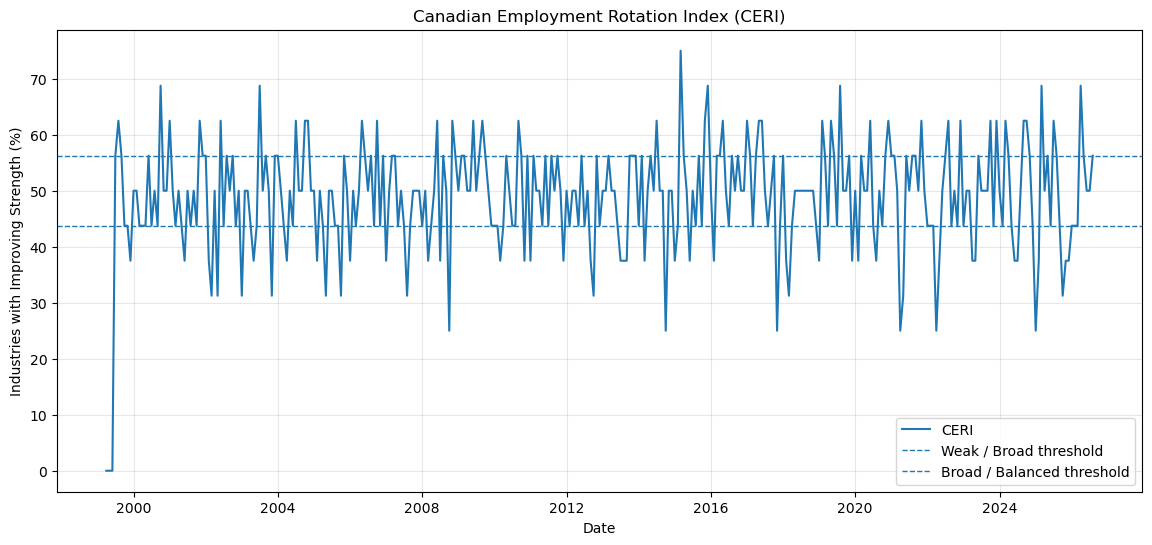

In [121]:
# ============================================================
# CERI ROTATION REGIME DASHBOARD
# ============================================================

# Plot the Canadian Employment Rotation Index through time.
# The horizontal lines mark the empirical regime thresholds
# established earlier in the analysis.

plt.figure(figsize=(14, 6))

plt.plot(
    ceri.index,
    ceri.values,
    label="CERI"
)

# Empirical regime boundaries.
plt.axhline(
    43.75,
    linewidth=1,
    linestyle="--",
    label="Weak / Broad threshold"
)

plt.axhline(
    56.25,
    linewidth=1,
    linestyle="--",
    label="Broad / Balanced threshold"
)

plt.title(
    "Canadian Employment Rotation Index (CERI)"
)

plt.xlabel("Date")
plt.ylabel("Industries with Improving Strength (%)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

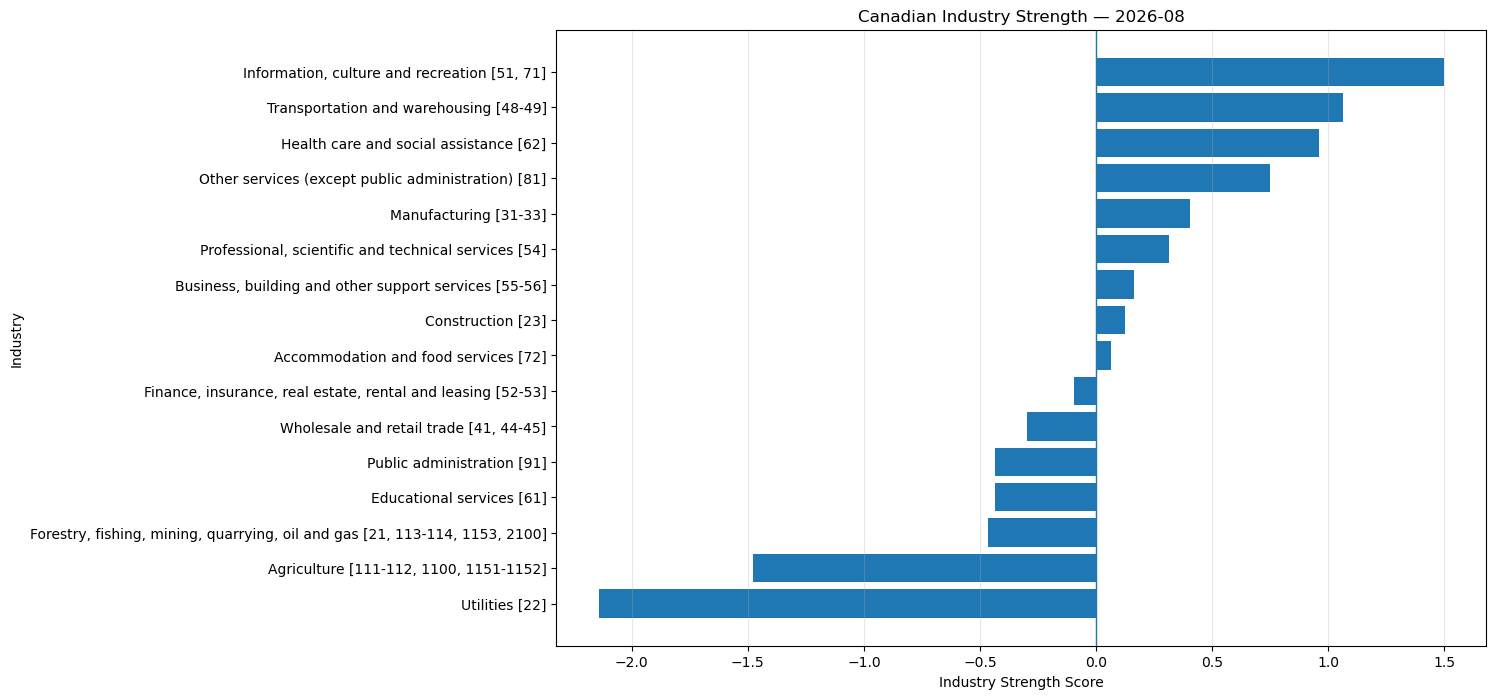

In [122]:
# ============================================================
# CURRENT INDUSTRY STRENGTH VS MOMENTUM
# ============================================================

# Build a cross-sectional dataset for the latest month.
latest_profile = pd.DataFrame({
    "Strength": industry_strength_score.loc[latest_date],
    "Momentum": strength_momentum.loc[latest_date]
}).sort_values(
    "Strength",
    ascending=True
)

# Create a horizontal bar chart showing current strength.
plt.figure(figsize=(12, 8))

plt.barh(
    latest_profile.index,
    latest_profile["Strength"]
)

# Zero separates stronger-than-average and
# weaker-than-average industries.
plt.axvline(
    0,
    linewidth=1
)

plt.title(
    f"Canadian Industry Strength — {latest_date.strftime('%Y-%m')}"
)

plt.xlabel("Industry Strength Score")
plt.ylabel("Industry")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

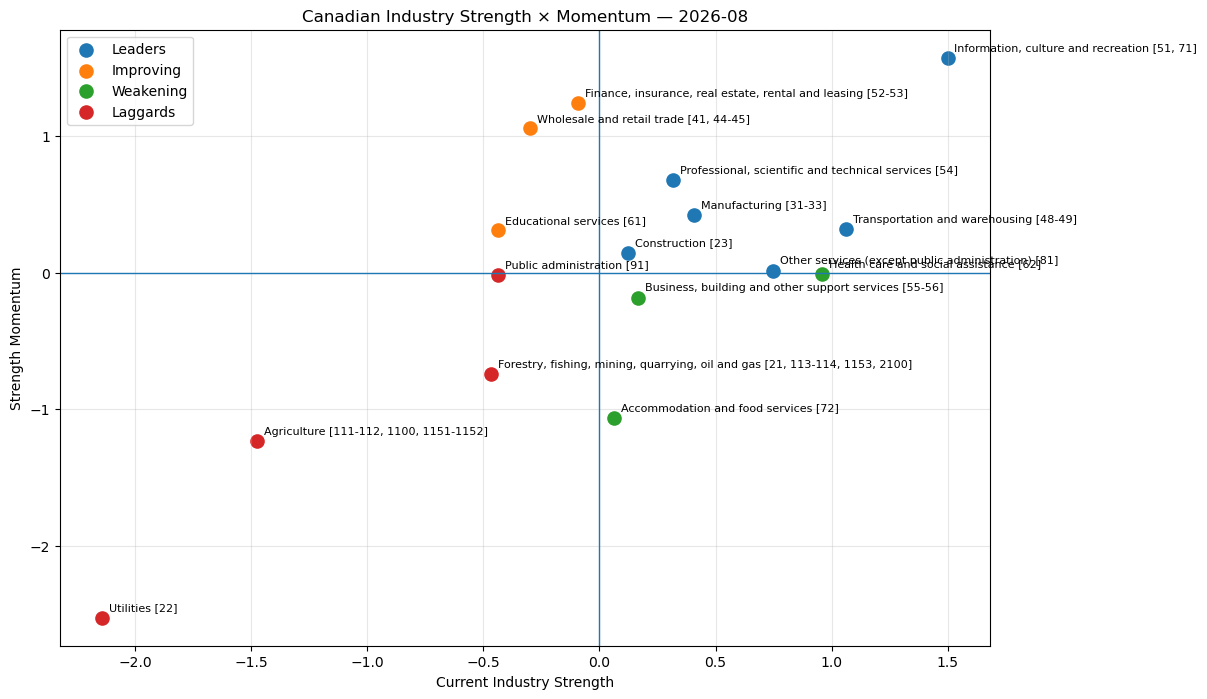

,Strength,Momentum,Quadrant
North American Industry Classification System (NAICS),,,
"Finance, insurance, real estate, rental and leasing [52-53]",-0.093924,1.244133,Improving
"Wholesale and retail trade [41, 44-45]",-0.297117,1.060022,Improving
Educational services [61],-0.435801,0.312022,Improving
Public administration [91],-0.435133,-0.014872,Laggards
"Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]",-0.467078,-0.745135,Laggards
"Agriculture [111-112, 1100, 1151-1152]",-1.475977,-1.233685,Laggards
Utilities [22],-2.142532,-2.528658,Laggards
"Information, culture and recreation [51, 71]",1.499370,1.576362,Leaders
Transportation and warehousing [48-49],1.064244,0.318575,Leaders


In [123]:
# ============================================================
# INDUSTRY STRENGTH × MOMENTUM QUADRANTS
# ============================================================

# Build the latest cross-sectional profile.
quadrant_df = pd.DataFrame({
    "Strength": industry_strength_score.loc[latest_date],
    "Momentum": strength_momentum.loc[latest_date]
}).dropna()

# Classify industries using zero as the midpoint for both metrics.
def classify_quadrant(row):
    if row["Strength"] >= 0 and row["Momentum"] >= 0:
        return "Leaders"
    elif row["Strength"] < 0 and row["Momentum"] >= 0:
        return "Improving"
    elif row["Strength"] >= 0 and row["Momentum"] < 0:
        return "Weakening"
    else:
        return "Laggards"

quadrant_df["Quadrant"] = quadrant_df.apply(
    classify_quadrant,
    axis=1
)

# Plot industries in strength × momentum space.
plt.figure(figsize=(12, 8))

for quadrant in ["Leaders", "Improving", "Weakening", "Laggards"]:
    subset = quadrant_df[quadrant_df["Quadrant"] == quadrant]

    plt.scatter(
        subset["Strength"],
        subset["Momentum"],
        s=90,
        label=quadrant
    )

    for industry, row in subset.iterrows():
        plt.annotate(
            industry,
            (row["Strength"], row["Momentum"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

# Zero lines define the four regimes.
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title(
    f"Canadian Industry Strength × Momentum — "
    f"{latest_date.strftime('%Y-%m')}"
)

plt.xlabel("Current Industry Strength")
plt.ylabel("Strength Momentum")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Display the classification table.
quadrant_df.sort_values(
    ["Quadrant", "Strength"],
    ascending=[True, False]
)

In [124]:
# ============================================================
# QUADRANT DISTRIBUTION
# ============================================================

# Count how many industries currently fall into each quadrant.
quadrant_counts = (
    quadrant_df["Quadrant"]
    .value_counts()
    .reindex(
        ["Leaders", "Improving", "Weakening", "Laggards"],
        fill_value=0
    )
)

# Calculate each quadrant's share of the industry universe.
quadrant_summary = pd.DataFrame({
    "Industries": quadrant_counts,
    "Share": quadrant_counts / len(quadrant_df)
})

quadrant_summary["Share"] = (
    quadrant_summary["Share"] * 100
).round(1)

quadrant_summary

,Industries,Share
Quadrant,,
Leaders,6,37.5
Improving,3,18.8
Weakening,3,18.8
Laggards,4,25.0


In [125]:
# ============================================================
# ROTATION OPPORTUNITY SCORE
# ============================================================

# Combine current strength and momentum into one forward-looking score.
# Strength receives 60% weight because it reflects the current state.
# Momentum receives 40% weight because it captures recent direction.
rotation_opportunity_score = (
    0.60 * quadrant_df["Strength"]
    + 0.40 * quadrant_df["Momentum"]
)

# Rank industries from strongest opportunity to weakest opportunity.
rotation_ranking = pd.DataFrame({
    "Strength": quadrant_df["Strength"],
    "Momentum": quadrant_df["Momentum"],
    "Quadrant": quadrant_df["Quadrant"],
    "Rotation Score": rotation_opportunity_score
}).sort_values(
    "Rotation Score",
    ascending=False
)

# Display the final rotation ranking.
rotation_ranking

,Strength,Momentum,Quadrant,Rotation Score
North American Industry Classification System (NAICS),,,,
"Information, culture and recreation [51, 71]",1.499370,1.576362,Leaders,1.530167
Transportation and warehousing [48-49],1.064244,0.318575,Leaders,0.765976
Health care and social assistance [62],0.959741,-0.007409,Weakening,0.572881
"Professional, scientific and technical services [54]",0.315979,0.681767,Leaders,0.462294
Other services (except public administration) [81],0.749292,0.014294,Leaders,0.455293
"Finance, insurance, real estate, rental and leasing [52-53]",-0.093924,1.244133,Improving,0.441299
Manufacturing [31-33],0.406651,0.422183,Leaders,0.412864
"Wholesale and retail trade [41, 44-45]",-0.297117,1.060022,Improving,0.245739
Construction [23],0.124215,0.147111,Leaders,0.133373


In [128]:
# ============================================================
# ROTATION SCORE WEIGHT SENSITIVITY
# ============================================================

# Build 3-month forward industry growth.
# growth_3m[t+3] represents growth measured over the
# three months ending at t+3.
future_3m_growth = growth_3m.shift(-3)

# Convert it into relative growth versus the industry universe.
future_3m_relative = (
    future_3m_growth
    .sub(future_3m_growth.mean(axis=1), axis=0)
)

# Test different strength / momentum combinations.
weights = [
    (1.00, 0.00),
    (0.80, 0.20),
    (0.60, 0.40),
    (0.40, 0.60),
    (0.20, 0.80),
    (0.00, 1.00)
]

results = []

for strength_weight, momentum_weight in weights:

    # Construct the alternative rotation score.
    test_score = (
        strength_weight * industry_strength_score
        + momentum_weight * strength_momentum
    )

    # Rank industries cross-sectionally.
    test_rank = test_score.rank(
        axis=1,
        ascending=False,
        method="min"
    )

    future_returns = []

    for date in test_score.index:

        # Skip dates where a full 3-month forward period
        # is not available.
        if date not in future_3m_relative.index:
            continue

        available = test_rank.loc[date].dropna()

        if len(available) < 4:
            continue

        # Select the four highest-ranked industries.
        top4 = available.nsmallest(4).index

        # Measure their average forward relative growth.
        values = future_3m_relative.loc[
            date,
            top4
        ].dropna()

        if len(values) == 4:
            future_returns.append(
                values.mean()
            )

    results.append({
        "Strength Weight": strength_weight,
        "Momentum Weight": momentum_weight,
        "Avg Future 3M Relative Growth":
            np.mean(future_returns),
        "Observations":
            len(future_returns)
    })

weight_test = pd.DataFrame(results)

weight_test.sort_values(
    "Avg Future 3M Relative Growth",
    ascending=False
)

,Strength Weight,Momentum Weight,Avg Future 3M Relative Growth,Observations
5,0.0,1.0,-0.121023,323
0,1.0,0.0,-0.146799,323
4,0.2,0.8,-0.187472,323
2,0.6,0.4,-0.196172,323
1,0.8,0.2,-0.206990,323
3,0.4,0.6,-0.207657,323


In [129]:
# ============================================================
# CONTRARIAN ROTATION SCORE WEIGHT SENSITIVITY
# ============================================================

# Test the same six weight combinations,
# but select the FOUR weakest industries instead.
results_contrarian = []

for strength_weight, momentum_weight in weights:

    # Construct the alternative score.
    test_score = (
        strength_weight * industry_strength_score
        + momentum_weight * strength_momentum
    )

    # Rank industries from weakest to strongest.
    test_rank = test_score.rank(
        axis=1,
        ascending=True,
        method="min"
    )

    future_returns = []

    for date in test_score.index:

        if date not in future_3m_relative.index:
            continue

        available = test_rank.loc[date].dropna()

        if len(available) < 4:
            continue

        # Select the four LOWEST-ranked industries.
        bottom4 = available.nsmallest(4).index

        values = future_3m_relative.loc[
            date,
            bottom4
        ].dropna()

        if len(values) == 4:
            future_returns.append(
                values.mean()
            )

    results_contrarian.append({
        "Strength Weight": strength_weight,
        "Momentum Weight": momentum_weight,
        "Avg Future 3M Relative Growth":
            np.mean(future_returns),
        "Observations":
            len(future_returns)
    })

contrarian_weight_test = pd.DataFrame(
    results_contrarian
)

contrarian_weight_test.sort_values(
    "Avg Future 3M Relative Growth",
    ascending=False
)

,Strength Weight,Momentum Weight,Avg Future 3M Relative Growth,Observations
5,0.0,1.0,0.261404,323
4,0.2,0.8,0.261198,323
3,0.4,0.6,0.249039,323
1,0.8,0.2,0.215395,323
2,0.6,0.4,0.201200,323
0,1.0,0.0,0.175157,323


In [130]:
# ============================================================
# OUT-OF-SAMPLE WEIGHT SELECTION
# ============================================================

# Use the middle of the sample as the train/test split.
split_date = industry_strength_score.index[
    len(industry_strength_score.index) // 2
]

print("Training period ends:", split_date.strftime("%Y-%m"))
print(
    "Testing period begins:",
    split_date.strftime("%Y-%m")
)

# Store results separately for training and testing.
oos_results = []

for strength_weight, momentum_weight in weights:

    # Build the candidate score.
    test_score = (
        strength_weight * industry_strength_score
        + momentum_weight * strength_momentum
    )

    test_rank = test_score.rank(
        axis=1,
        ascending=True,
        method="min"
    )

    train_returns = []
    test_returns = []

    for date in test_score.index:

        if date not in future_3m_relative.index:
            continue

        available = test_rank.loc[date].dropna()

        if len(available) < 4:
            continue

        # Contrarian selection: four weakest industries.
        bottom4 = available.nsmallest(4).index

        values = future_3m_relative.loc[
            date,
            bottom4
        ].dropna()

        if len(values) != 4:
            continue

        portfolio_growth = values.mean()

        if date < split_date:
            train_returns.append(portfolio_growth)
        else:
            test_returns.append(portfolio_growth)

    oos_results.append({
        "Strength Weight": strength_weight,
        "Momentum Weight": momentum_weight,
        "Train Avg 3M Relative Growth":
            np.mean(train_returns),
        "Test Avg 3M Relative Growth":
            np.mean(test_returns),
        "Train Observations":
            len(train_returns),
        "Test Observations":
            len(test_returns)
    })

oos_weight_test = pd.DataFrame(oos_results)

oos_weight_test.sort_values(
    "Test Avg 3M Relative Growth",
    ascending=False
)

Training period ends: 2012-12
Testing period begins: 2012-12


,Strength Weight,Momentum Weight,Train Avg 3M Relative Growth,Test Avg 3M Relative Growth,Train Observations,Test Observations
1,0.8,0.2,-0.061650,0.490729,161,162
3,0.4,0.6,0.017264,0.479384,161,162
4,0.2,0.8,0.073421,0.447816,161,162
0,1.0,0.0,-0.083874,0.432588,161,162
2,0.6,0.4,-0.026667,0.427661,161,162
5,0.0,1.0,0.149487,0.372631,161,162


In [131]:
# ============================================================
# TRUE OUT-OF-SAMPLE TEST
# ============================================================

# Select the weighting that performed best in the training period.
best_train_row = oos_weight_test.loc[
    oos_weight_test["Train Avg 3M Relative Growth"].idxmax()
]

best_strength_weight = best_train_row["Strength Weight"]
best_momentum_weight = best_train_row["Momentum Weight"]

print(
    "Training-selected weighting:",
    f"{best_strength_weight:.0%} strength / "
    f"{best_momentum_weight:.0%} momentum"
)

# Rebuild the score using ONLY the training-selected weights.
oos_score = (
    best_strength_weight * industry_strength_score
    + best_momentum_weight * strength_momentum
)

# Rank industries from weakest to strongest.
oos_rank = oos_score.rank(
    axis=1,
    ascending=True,
    method="min"
)

test_portfolio = []
test_benchmark = []

for date in oos_score.index:

    # Only evaluate the genuine test period.
    if date < split_date:
        continue

    if date not in future_3m_relative.index:
        continue

    available = oos_rank.loc[date].dropna()

    if len(available) < 4:
        continue

    # Four weakest industries.
    bottom4 = available.nsmallest(4).index

    portfolio_values = future_3m_relative.loc[
        date,
        bottom4
    ].dropna()

    benchmark_values = future_3m_relative.loc[
        date
    ].dropna()

    if len(portfolio_values) == 4 and len(benchmark_values) > 0:

        test_portfolio.append(
            portfolio_values.mean()
        )

        test_benchmark.append(
            benchmark_values.mean()
        )

# Convert to Series for statistical testing.
test_portfolio = pd.Series(
    test_portfolio,
    name="OOS Contrarian Portfolio"
)

test_benchmark = pd.Series(
    test_benchmark,
    name="OOS Benchmark"
)

# Calculate excess performance.
oos_excess = (
    test_portfolio - test_benchmark
)

# One-sample t-test of excess performance.
from scipy import stats

t_stat, p_value = stats.ttest_1samp(
    oos_excess.dropna(),
    0
)

print("\nOUT-OF-SAMPLE RESULTS")
print("=" * 60)

print(
    "Average portfolio relative growth:",
    round(test_portfolio.mean(), 4),
    "pp"
)

print(
    "Average benchmark relative growth:",
    round(test_benchmark.mean(), 4),
    "pp"
)

print(
    "Average excess:",
    round(oos_excess.mean(), 4),
    "pp"
)

print(
    "t-statistic:",
    round(t_stat, 4)
)

print(
    "p-value:",
    round(p_value, 4)
)

print(
    "Observations:",
    len(oos_excess)
)

Training-selected weighting: 0% strength / 100% momentum

OUT-OF-SAMPLE RESULTS
Average portfolio relative growth: 0.3726 pp
Average benchmark relative growth: -0.0 pp
Average excess: 0.3726 pp
t-statistic: 2.2997
p-value: 0.0228
Observations: 162


In [132]:
# ============================================================
# OUT-OF-SAMPLE RAW GROWTH COMPARISON
# ============================================================

# Use the training-selected momentum-only score.
oos_score_raw = (
    best_strength_weight * industry_strength_score
    + best_momentum_weight * strength_momentum
)

# Rank industries from weakest to strongest.
oos_rank_raw = oos_score_raw.rank(
    axis=1,
    ascending=True,
    method="min"
)

portfolio_raw = []
benchmark_raw = []
dates_raw = []

for date in oos_score_raw.index:

    # Only evaluate the test period.
    if date < split_date:
        continue

    if date not in future_3m_growth.index:
        continue

    available = oos_rank_raw.loc[date].dropna()

    if len(available) < 4:
        continue

    # Select the four weakest industries.
    bottom4 = available.nsmallest(4).index

    portfolio_values = future_3m_growth.loc[
        date,
        bottom4
    ].dropna()

    benchmark_values = future_3m_growth.loc[
        date
    ].dropna()

    if len(portfolio_values) == 4:

        portfolio_raw.append(
            portfolio_values.mean()
        )

        benchmark_raw.append(
            benchmark_values.mean()
        )

        dates_raw.append(date)

# Create aligned series.
portfolio_raw = pd.Series(
    portfolio_raw,
    index=dates_raw,
    name="OOS Contrarian Portfolio"
)

benchmark_raw = pd.Series(
    benchmark_raw,
    index=dates_raw,
    name="Equal-Weight Benchmark"
)

# Calculate excess growth.
raw_excess = (
    portfolio_raw - benchmark_raw
)

# Statistical significance test.
t_stat_raw, p_value_raw = stats.ttest_1samp(
    raw_excess.dropna(),
    0
)

print("OUT-OF-SAMPLE RAW GROWTH")
print("=" * 60)

print(
    "Portfolio average 3M growth:",
    round(portfolio_raw.mean(), 4),
    "%"
)

print(
    "Benchmark average 3M growth:",
    round(benchmark_raw.mean(), 4),
    "%"
)

print(
    "Average excess:",
    round(raw_excess.mean(), 4),
    "pp"
)

print(
    "t-statistic:",
    round(t_stat_raw, 4)
)

print(
    "p-value:",
    round(p_value_raw, 4)
)

print(
    "Observations:",
    len(raw_excess)
)

OUT-OF-SAMPLE RAW GROWTH
Portfolio average 3M growth: 0.6912 %
Benchmark average 3M growth: 0.3186 %
Average excess: 0.3726 pp
t-statistic: 2.2997
p-value: 0.0228
Observations: 162


In [133]:
# ============================================================
# OOS PERFORMANCE BY ECONOMIC REGIME
# ============================================================

# Align the previously calculated OOS portfolio and benchmark.
oos_regime_df = pd.DataFrame({
    "Portfolio": portfolio_raw,
    "Benchmark": benchmark_raw
})

# Add the regime corresponding to each observation date.
oos_regime_df["Regime"] = regime.loc[
    oos_regime_df.index
]

# Calculate excess performance.
oos_regime_df["Excess"] = (
    oos_regime_df["Portfolio"]
    - oos_regime_df["Benchmark"]
)

# Summarize performance by regime.
regime_results = (
    oos_regime_df
    .groupby("Regime")
    .agg(
        Portfolio_Growth=("Portfolio", "mean"),
        Benchmark_Growth=("Benchmark", "mean"),
        Excess_Growth=("Excess", "mean"),
        Observations=("Excess", "count")
    )
)

# Test whether excess performance differs from zero
# within each regime.
p_values = []

for current_regime in regime_results.index:

    excess = oos_regime_df.loc[
        oos_regime_df["Regime"] == current_regime,
        "Excess"
    ].dropna()

    if len(excess) > 1:
        t_stat, p_value = stats.ttest_1samp(
            excess,
            0
        )
    else:
        p_value = np.nan

    p_values.append(p_value)

regime_results["p_value"] = p_values

# Round the output for readability.
regime_results.round(4)

NameError: name 'regime' is not defined

In [135]:
# ============================================================
# FIND CERI VARIABLE
# ============================================================

# Show variables whose names contain "ceri".
ceri_variables = [
    name
    for name in globals()
    if "ceri" in name.lower()
]

print("CERI-related variables:")
print(ceri_variables)

# Show the type and shape of each matching variable.
for name in ceri_variables:
    obj = globals()[name]

    print("\n" + name)
    print("Type:", type(obj))

    if hasattr(obj, "shape"):
        print("Shape:", obj.shape)

    if hasattr(obj, "head"):
        print(obj.head())

CERI-related variables:
['ceri', 'ceri_low', 'ceri_high', 'ceri_regime', 'ceri_test', 'ceri_summary', 'future_ceri', 'ceri_persistence_data', 'ceri_persistence_corr', 'latest_ceri']

ceri
Type: <class 'pandas.core.series.Series'>
Shape: (329,)
Date
1999-04-01     0.00
1999-05-01     0.00
1999-06-01     0.00
1999-07-01    56.25
1999-08-01    62.50
dtype: float64

ceri_low
Type: <class 'numpy.float64'>
Shape: ()

ceri_high
Type: <class 'numpy.float64'>
Shape: ()

ceri_regime
Type: <class 'pandas.core.series.Series'>
Shape: (329,)
Date
1999-04-01     Weak Rotation
1999-05-01     Weak Rotation
1999-06-01     Weak Rotation
1999-07-01    Broad Rotation
1999-08-01    Broad Rotation
dtype: object

ceri_test
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (317, 2)
               CERI_Regime  Future_Avg_Strength_Change
Date                                                  
1999-04-01   Weak Rotation                2.775558e-17
1999-05-01   Weak Rotation               -3.469447e-17
1999-06-01 

In [136]:
# ============================================================
# OOS PERFORMANCE BY CERI REGIME
# ============================================================

# Combine the OOS portfolio and benchmark results.
oos_regime_df = pd.DataFrame({
    "Portfolio": portfolio_raw,
    "Benchmark": benchmark_raw
})

# Add the CERI regime already calculated in the notebook.
oos_regime_df["CERI Regime"] = ceri_regime.loc[
    oos_regime_df.index
]

# Calculate excess performance.
oos_regime_df["Excess"] = (
    oos_regime_df["Portfolio"]
    - oos_regime_df["Benchmark"]
)

# Summarize performance by regime.
regime_results = (
    oos_regime_df
    .groupby("CERI Regime")
    .agg(
        Portfolio_Growth=("Portfolio", "mean"),
        Benchmark_Growth=("Benchmark", "mean"),
        Excess_Growth=("Excess", "mean"),
        Observations=("Excess", "count")
    )
)

# Test whether excess performance is statistically different
# from zero within each regime.
p_values = []

for current_regime in regime_results.index:

    excess = oos_regime_df.loc[
        oos_regime_df["CERI Regime"] == current_regime,
        "Excess"
    ].dropna()

    if len(excess) > 1:
        _, p_value = stats.ttest_1samp(
            excess,
            0
        )
    else:
        p_value = np.nan

    p_values.append(p_value)

regime_results["p_value"] = p_values

# Display the final regime-level OOS results.
regime_results.round(4)

,Portfolio_Growth,Benchmark_Growth,Excess_Growth,Observations,p_value
CERI Regime,,,,,
Balanced Rotation,1.4576,0.4576,1.0000,46,0.0511
Broad Rotation,0.3382,0.4253,-0.0871,57,0.4944
Weak Rotation,0.4346,0.1070,0.3276,59,0.0455


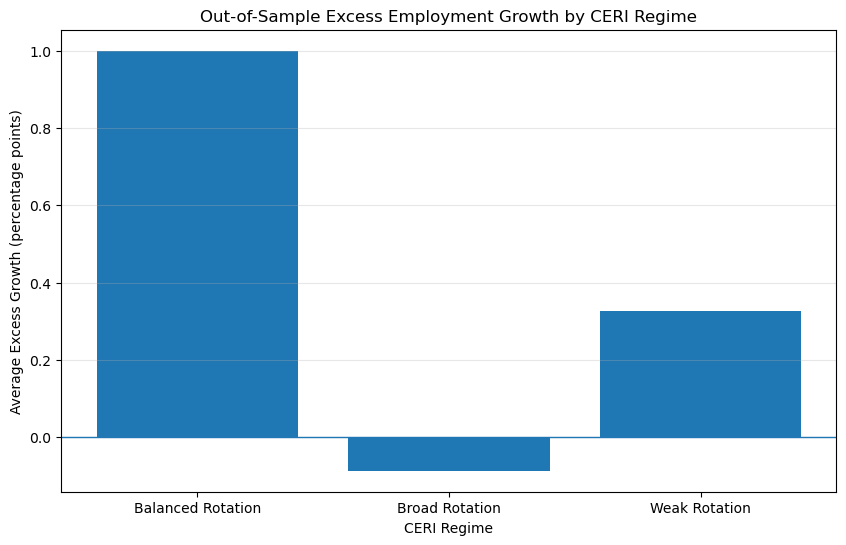

In [137]:
# ============================================================
# OOS REGIME PERFORMANCE
# ============================================================

# Plot average excess performance by CERI regime.
plt.figure(figsize=(10, 6))

plt.bar(
    regime_results.index,
    regime_results["Excess_Growth"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Out-of-Sample Excess Employment Growth by CERI Regime"
)

plt.xlabel("CERI Regime")
plt.ylabel("Average Excess Growth (percentage points)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [138]:
# ============================================================
# OOS PERFORMANCE BY CALENDAR SUBPERIOD
# ============================================================

# Create a copy of the OOS results.
subperiod_df = oos_regime_df.copy()

# Assign each observation to a broad calendar period.
subperiod_df["Period"] = pd.cut(
    subperiod_df.index.year,
    bins=[2012, 2015, 2018, 2021, 2024, 2100],
    labels=[
        "2013-2015",
        "2016-2018",
        "2019-2021",
        "2022-2024",
        "2025+"
    ],
    include_lowest=True
)

# Calculate excess performance.
subperiod_df["Excess"] = (
    subperiod_df["Portfolio"]
    - subperiod_df["Benchmark"]
)

# Summarize each subperiod.
subperiod_results = (
    subperiod_df
    .groupby("Period", observed=True)
    .agg(
        Portfolio_Growth=("Portfolio", "mean"),
        Benchmark_Growth=("Benchmark", "mean"),
        Excess_Growth=("Excess", "mean"),
        Observations=("Excess", "count")
    )
)

# Test significance within each subperiod.
p_values = []

for period in subperiod_results.index:

    excess = subperiod_df.loc[
        subperiod_df["Period"] == period,
        "Excess"
    ].dropna()

    if len(excess) > 1:
        _, p_value = stats.ttest_1samp(
            excess,
            0
        )
    else:
        p_value = np.nan

    p_values.append(p_value)

subperiod_results["p_value"] = p_values

subperiod_results.round(4)

,Portfolio_Growth,Benchmark_Growth,Excess_Growth,Observations,p_value
Period,,,,,
2013-2015,0.2797,0.0366,0.2431,37,0.0310
2016-2018,0.5825,0.4419,0.1406,36,0.2709
2019-2021,1.4038,0.3160,1.0878,36,0.1128
2022-2024,0.8071,0.5644,0.2427,36,0.1797
2025+,0.0625,0.1559,-0.0934,17,0.7401


OOS CUMULATIVE PERFORMANCE
Final portfolio index: 2.778
Final benchmark index: 1.605
Portfolio cumulative growth: 177.75 %
Benchmark cumulative growth: 60.53 %


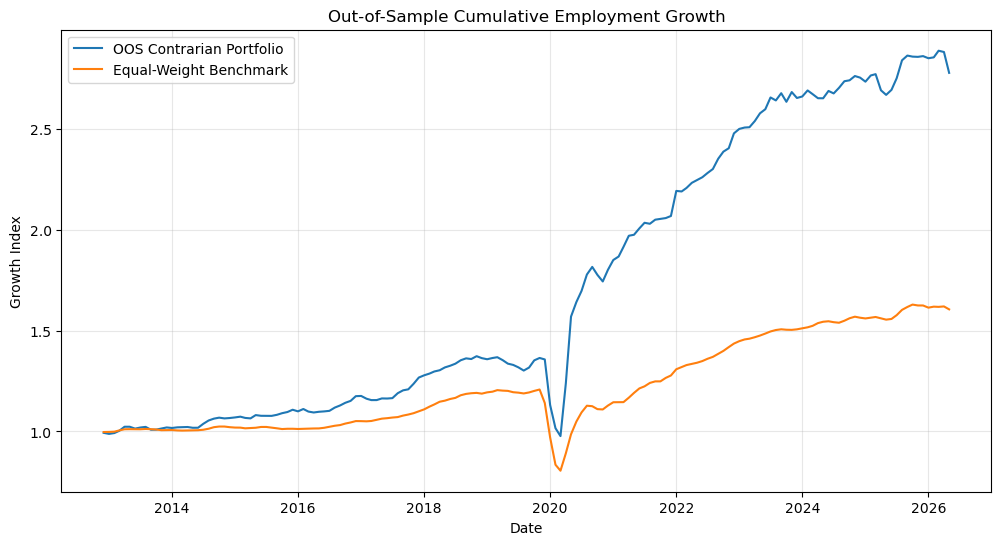

In [139]:
# ============================================================
# OOS CUMULATIVE PERFORMANCE
# ============================================================

# Build cumulative growth indices from monthly-equivalent
# portfolio and benchmark growth observations.
oos_index = pd.DataFrame({
    "Portfolio": portfolio_raw,
    "Benchmark": benchmark_raw
}).sort_index()

oos_cumulative = (
    1 + oos_index / 100
).cumprod()

print("OOS CUMULATIVE PERFORMANCE")
print("=" * 60)

print(
    "Final portfolio index:",
    round(
        oos_cumulative["Portfolio"].iloc[-1],
        3
    )
)

print(
    "Final benchmark index:",
    round(
        oos_cumulative["Benchmark"].iloc[-1],
        3
    )
)

print(
    "Portfolio cumulative growth:",
    round(
        (oos_cumulative["Portfolio"].iloc[-1] - 1) * 100,
        2
    ),
    "%"
)

print(
    "Benchmark cumulative growth:",
    round(
        (oos_cumulative["Benchmark"].iloc[-1] - 1) * 100,
        2
    ),
    "%"
)

# Plot the OOS cumulative paths.
plt.figure(figsize=(12, 6))

plt.plot(
    oos_cumulative["Portfolio"],
    label="OOS Contrarian Portfolio"
)

plt.plot(
    oos_cumulative["Benchmark"],
    label="Equal-Weight Benchmark"
)

plt.title(
    "Out-of-Sample Cumulative Employment Growth"
)

plt.xlabel("Date")
plt.ylabel("Growth Index")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

OOS DRAWDOWN COMPARISON
Portfolio maximum drawdown: -28.84 %
Benchmark maximum drawdown: -33.32 %
Portfolio average drawdown: -1.03 %
Benchmark average drawdown: -1.53 %


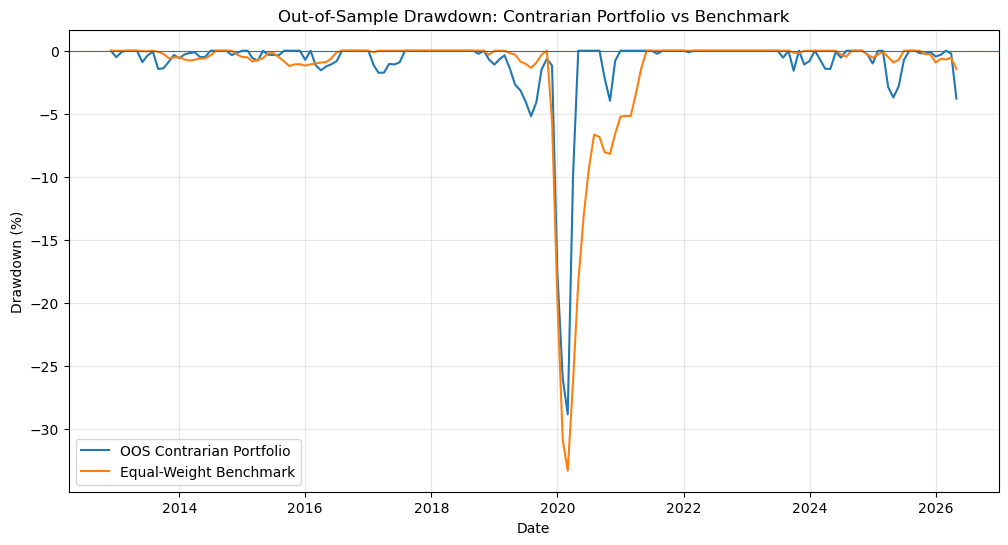

In [140]:
# ============================================================
# OOS DRAWDOWN COMPARISON
# ============================================================

# Calculate running peaks of the OOS cumulative indices.
oos_portfolio_peak = (
    oos_cumulative["Portfolio"].cummax()
)

oos_benchmark_peak = (
    oos_cumulative["Benchmark"].cummax()
)

# Calculate percentage drawdowns from the previous peak.
oos_portfolio_drawdown = (
    oos_cumulative["Portfolio"]
    / oos_portfolio_peak
    - 1
) * 100

oos_benchmark_drawdown = (
    oos_cumulative["Benchmark"]
    / oos_benchmark_peak
    - 1
) * 100

print("OOS DRAWDOWN COMPARISON")
print("=" * 60)

print(
    "Portfolio maximum drawdown:",
    round(oos_portfolio_drawdown.min(), 2),
    "%"
)

print(
    "Benchmark maximum drawdown:",
    round(oos_benchmark_drawdown.min(), 2),
    "%"
)

print(
    "Portfolio average drawdown:",
    round(oos_portfolio_drawdown.mean(), 2),
    "%"
)

print(
    "Benchmark average drawdown:",
    round(oos_benchmark_drawdown.mean(), 2),
    "%"
)

# Plot the drawdown paths.
plt.figure(figsize=(12, 6))

plt.plot(
    oos_portfolio_drawdown,
    label="OOS Contrarian Portfolio"
)

plt.plot(
    oos_benchmark_drawdown,
    label="Equal-Weight Benchmark"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.title(
    "Out-of-Sample Drawdown: Contrarian Portfolio vs Benchmark"
)

plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [143]:
# ============================================================
# INSPECT OOS VARIABLES
# ============================================================

oos_variables = sorted([
    name
    for name in globals()
    if "oos" in name.lower()
])

print("OOS VARIABLES FOUND")
print("=" * 60)

for name in oos_variables:
    obj = globals()[name]

    try:
        print(
            f"{name:<30} "
            f"type={type(obj).__name__:<15} "
            f"shape={getattr(obj, 'shape', 'N/A')}"
        )
    except Exception:
        print(name)

OOS VARIABLES FOUND
oos_benchmark_drawdown         type=Series          shape=(162,)
oos_benchmark_peak             type=Series          shape=(162,)
oos_cumulative                 type=DataFrame       shape=(162, 2)
oos_excess                     type=Series          shape=(162,)
oos_index                      type=DataFrame       shape=(162, 2)
oos_portfolio_drawdown         type=Series          shape=(162,)
oos_portfolio_peak             type=Series          shape=(162,)
oos_rank                       type=DataFrame       shape=(329, 16)
oos_rank_raw                   type=DataFrame       shape=(329, 16)
oos_regime_df                  type=DataFrame       shape=(162, 4)
oos_results                    type=list            shape=N/A
oos_score                      type=DataFrame       shape=(329, 16)
oos_score_raw                  type=DataFrame       shape=(329, 16)
oos_weight_test                type=DataFrame       shape=(6, 6)


In [144]:
# ============================================================
# NON-OVERLAPPING QUARTERLY OOS TEST
# ============================================================

# Inspect the exact columns first.
print("OOS INDEX COLUMNS:")
print(oos_index.columns.tolist())

print("\nFIRST 5 ROWS:")
display(oos_index.head())

OOS INDEX COLUMNS:
['Portfolio', 'Benchmark']

FIRST 5 ROWS:


,Portfolio,Benchmark
2012-12-01,-0.680865,-0.270860
2013-01-01,-0.512318,0.056037
2013-02-01,0.414708,0.119508
2013-03-01,1.111726,0.614457
2013-04-01,2.021033,0.582965


In [145]:
# ============================================================
# BUILD NON-OVERLAPPING QUARTERLY OOS RETURNS
# ============================================================

# Keep every 3rd monthly observation.
# This converts the overlapping 3-month observations into
# non-overlapping quarterly observations.

quarterly_oos = oos_index.iloc[::3].copy()

# Calculate portfolio minus benchmark.
quarterly_oos["Excess"] = (
    quarterly_oos["Portfolio"]
    - quarterly_oos["Benchmark"]
)

print("NON-OVERLAPPING QUARTERLY OOS TEST")
print("=" * 60)

print("Observations:", len(quarterly_oos))

print(
    "Average portfolio growth:",
    round(quarterly_oos["Portfolio"].mean(), 4),
    "%"
)

print(
    "Average benchmark growth:",
    round(quarterly_oos["Benchmark"].mean(), 4),
    "%"
)

print(
    "Average excess growth:",
    round(quarterly_oos["Excess"].mean(), 4),
    "%"
)

display(quarterly_oos.head())

NON-OVERLAPPING QUARTERLY OOS TEST
Observations: 54
Average portfolio growth: 0.5917 %
Average benchmark growth: 0.2903 %
Average excess growth: 0.3015 %


,Portfolio,Benchmark,Excess
2012-12-01,-0.680865,-0.270860,-0.410006
2013-03-01,1.111726,0.614457,0.497269
2013-06-01,-0.907226,-0.036451,-0.870775
2013-09-01,-1.381948,-0.094565,-1.287383
2013-12-01,0.543647,0.063137,0.480510


In [146]:
# ============================================================
# QUARTERLY OOS STATISTICAL TEST
# ============================================================
# Test whether the portfolio's average excess performance
# versus the benchmark is significantly different from zero.

from scipy import stats

quarterly_excess = quarterly_oos["Excess"].dropna()

t_stat, p_value = stats.ttest_1samp(
    quarterly_excess,
    0
)

print("QUARTERLY OOS STATISTICAL TEST")
print("=" * 60)

print("Observations:", len(quarterly_excess))

print(
    "Mean excess growth:",
    round(quarterly_excess.mean(), 4),
    "%"
)

print(
    "t-statistic:",
    round(t_stat, 4)
)

print(
    "p-value:",
    round(p_value, 4)
)

QUARTERLY OOS STATISTICAL TEST
Observations: 54
Mean excess growth: 0.3015 %
t-statistic: 2.0036
p-value: 0.0502


In [148]:
# ============================================================
# INSPECT TURNOVER VARIABLES
# ============================================================

turnover_variables = sorted([
    name
    for name in globals()
    if "turnover" in name.lower()
])

print("TURNOVER VARIABLES FOUND")
print("=" * 60)

for name in turnover_variables:
    obj = globals()[name]

    print(
        f"{name:<30} "
        f"type={type(obj).__name__:<15} "
        f"shape={getattr(obj, 'shape', 'N/A')}"
    )

TURNOVER VARIABLES FOUND
avg_rank_turnover              type=Series          shape=(326,)
contrarian_turnover            type=Series          shape=(329,)
monthly_turnover               type=Series          shape=(328,)
turnover_8                     type=Series          shape=(329,)


In [149]:
# ============================================================
# INSPECT CONTRARIAN TURNOVER
# ============================================================

print("CONTRARIAN TURNOVER")
print("=" * 60)

print("Length:", len(contrarian_turnover))
print("Start:", contrarian_turnover.index.min())
print("End:", contrarian_turnover.index.max())

print("\nFIRST 10 VALUES:")
display(contrarian_turnover.head(10))

print("\nLAST 10 VALUES:")
display(contrarian_turnover.tail(10))

CONTRARIAN TURNOVER
Length: 329
Start: 1999-04-01 00:00:00
End: 2026-08-01 00:00:00

FIRST 10 VALUES:


Date
1999-04-01    0.0
1999-05-01    0.0
1999-06-01    0.0
1999-07-01    0.0
1999-08-01    1.0
1999-09-01    0.0
1999-10-01    0.0
1999-11-01    1.0
1999-12-01    0.0
2000-01-01    0.0
dtype: float64


LAST 10 VALUES:


Date
2025-11-01    0.5
2025-12-01    0.0
2026-01-01    0.0
2026-02-01    1.5
2026-03-01    0.0
2026-04-01    0.0
2026-05-01    2.0
2026-06-01    0.0
2026-07-01    0.0
2026-08-01    1.5
dtype: float64

In [150]:
# ============================================================
# QUARTERLY OOS TRANSACTION-COST SENSITIVITY
# ============================================================

# Align the monthly contrarian turnover series with the
# non-overlapping quarterly OOS observations.
quarterly_turnover = (
    contrarian_turnover
    .reindex(quarterly_oos.index)
    .fillna(0)
)

# Test several one-way transaction-cost assumptions.
cost_rates = [0.001, 0.0025, 0.005]

print("QUARTERLY OOS TRANSACTION-COST SENSITIVITY")
print("=" * 60)

for cost_rate in cost_rates:

    transaction_cost = (
        quarterly_turnover * cost_rate * 100
    )

    net_excess = (
        quarterly_oos["Excess"]
        - transaction_cost
    )

    print(
        f"One-way cost: {cost_rate * 100:.2f}% | "
        f"Average turnover: {quarterly_turnover.mean():.4f} | "
        f"Gross excess: {quarterly_oos['Excess'].mean():.4f}% | "
        f"Average cost: {transaction_cost.mean():.4f}% | "
        f"Net excess: {net_excess.mean():.4f}%"
    )

QUARTERLY OOS TRANSACTION-COST SENSITIVITY
One-way cost: 0.10% | Average turnover: 0.0000 | Gross excess: 0.3015% | Average cost: 0.0000% | Net excess: 0.3015%
One-way cost: 0.25% | Average turnover: 0.0000 | Gross excess: 0.3015% | Average cost: 0.0000% | Net excess: 0.3015%
One-way cost: 0.50% | Average turnover: 0.0000 | Gross excess: 0.3015% | Average cost: 0.0000% | Net excess: 0.3015%


In [151]:
# ============================================================
# CHECK OOS TURNOVER ALIGNMENT
# ============================================================

print("QUARTERLY OOS DATES:")
print(quarterly_oos.index[:10].tolist())

print("\nTURNOVER VALUES ON THOSE DATES:")
display(
    contrarian_turnover
    .reindex(quarterly_oos.index)
    .head(10)
)

print("\nNUMBER OF MATCHING DATES:")
print(
    quarterly_oos.index.isin(
        contrarian_turnover.index
    ).sum()
)

QUARTERLY OOS DATES:
[Timestamp('2012-12-01 00:00:00'), Timestamp('2013-03-01 00:00:00'), Timestamp('2013-06-01 00:00:00'), Timestamp('2013-09-01 00:00:00'), Timestamp('2013-12-01 00:00:00'), Timestamp('2014-03-01 00:00:00'), Timestamp('2014-06-01 00:00:00'), Timestamp('2014-09-01 00:00:00'), Timestamp('2014-12-01 00:00:00'), Timestamp('2015-03-01 00:00:00')]

TURNOVER VALUES ON THOSE DATES:


2012-12-01    0.0
2013-03-01    0.0
2013-06-01    0.0
2013-09-01    0.0
2013-12-01    0.0
2014-03-01    0.0
2014-06-01    0.0
2014-09-01    0.0
2014-12-01    0.0
2015-03-01    0.0
dtype: float64


NUMBER OF MATCHING DATES:
54


In [152]:
# ============================================================
# INSPECT CONTRARIAN REBALANCING TURNOVER
# ============================================================

# Show all non-zero turnover observations during the OOS period.
nonzero_turnover = contrarian_turnover[
    (contrarian_turnover.index >= quarterly_oos.index.min()) &
    (contrarian_turnover.index <= quarterly_oos.index.max()) &
    (contrarian_turnover > 0)
]

print("NON-ZERO CONTRARIAN TURNOVER DURING OOS")
print("=" * 60)

display(nonzero_turnover.head(30))

print("\nTOTAL NON-ZERO OBSERVATIONS:")
print(len(nonzero_turnover))

print("\nUNIQUE TURNOVER VALUES:")
print(sorted(contrarian_turnover.dropna().unique()))

NON-ZERO CONTRARIAN TURNOVER DURING OOS


Date
2013-02-01    1.5
2013-05-01    1.5
2013-08-01    1.5
2013-11-01    1.0
2014-02-01    1.5
2014-05-01    1.0
2014-08-01    1.5
2014-11-01    1.0
2015-02-01    1.0
2015-05-01    1.5
2015-08-01    1.0
2015-11-01    1.0
2016-02-01    1.5
2016-05-01    0.5
2016-08-01    1.5
2016-11-01    1.0
2017-02-01    1.0
2017-05-01    1.5
2017-08-01    1.0
2017-11-01    0.5
2018-02-01    1.0
2018-05-01    2.0
2018-08-01    0.5
2018-11-01    1.5
2019-02-01    1.0
2019-05-01    1.0
2019-08-01    0.5
2019-11-01    1.0
2020-02-01    1.0
2020-05-01    1.5
dtype: float64


TOTAL NON-ZERO OBSERVATIONS:
53

UNIQUE TURNOVER VALUES:
[np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0)]


In [153]:
# ============================================================
# ALIGN QUARTERLY OOS RETURNS WITH REBALANCING TURNOVER
# ============================================================

# The portfolio is formed one month before the OOS return period.
# Therefore, shift turnover forward by one month so the
# rebalancing cost is attached to the subsequent OOS observation.

oos_turnover_aligned = (
    contrarian_turnover
    .shift(1)
    .reindex(quarterly_oos.index)
)

print("ALIGNED OOS TURNOVER")
print("=" * 60)

display(
    pd.DataFrame({
        "OOS_Excess": quarterly_oos["Excess"],
        "Rebalance_Turnover": oos_turnover_aligned
    }).head(10)
)

print(
    "\nAverage quarterly turnover:",
    round(oos_turnover_aligned.mean(), 4)
)

ALIGNED OOS TURNOVER


,OOS_Excess,Rebalance_Turnover
2012-12-01,-0.410006,1.5
2013-03-01,0.497269,1.5
2013-06-01,-0.870775,1.5
2013-09-01,-1.287383,1.5
2013-12-01,0.480510,1.0
2014-03-01,0.185641,1.5
2014-06-01,0.000434,1.0
2014-09-01,0.110578,1.5
2014-12-01,0.478196,1.0
2015-03-01,-0.245275,1.0



Average quarterly turnover: 1.1574


In [154]:
# ============================================================
# QUARTERLY OOS TRANSACTION-COST SENSITIVITY
# ============================================================

cost_rates = [0.001, 0.0025, 0.005]

gross_excess = quarterly_oos["Excess"].mean()

print("QUARTERLY OOS TRANSACTION-COST SENSITIVITY")
print("=" * 60)

for cost_rate in cost_rates:

    # Transaction cost = turnover × one-way trading cost.
    transaction_cost = (
        oos_turnover_aligned
        * cost_rate
        * 100
    )

    net_excess = (
        quarterly_oos["Excess"]
        - transaction_cost
    )

    print(
        f"One-way cost: {cost_rate * 100:.2f}% | "
        f"Average cost: {transaction_cost.mean():.4f}% | "
        f"Gross excess: {gross_excess:.4f}% | "
        f"Net excess: {net_excess.mean():.4f}%"
    )

QUARTERLY OOS TRANSACTION-COST SENSITIVITY
One-way cost: 0.10% | Average cost: 0.1157% | Gross excess: 0.3015% | Net excess: 0.1857%
One-way cost: 0.25% | Average cost: 0.2894% | Gross excess: 0.3015% | Net excess: 0.0121%
One-way cost: 0.50% | Average cost: 0.5787% | Gross excess: 0.3015% | Net excess: -0.2772%


NON-OVERLAPPING QUARTERLY OOS CUMULATIVE PERFORMANCE
Final portfolio index: 1.3688
Final benchmark index: 1.1636
Portfolio cumulative growth: 36.88 %
Benchmark cumulative growth: 16.36 %


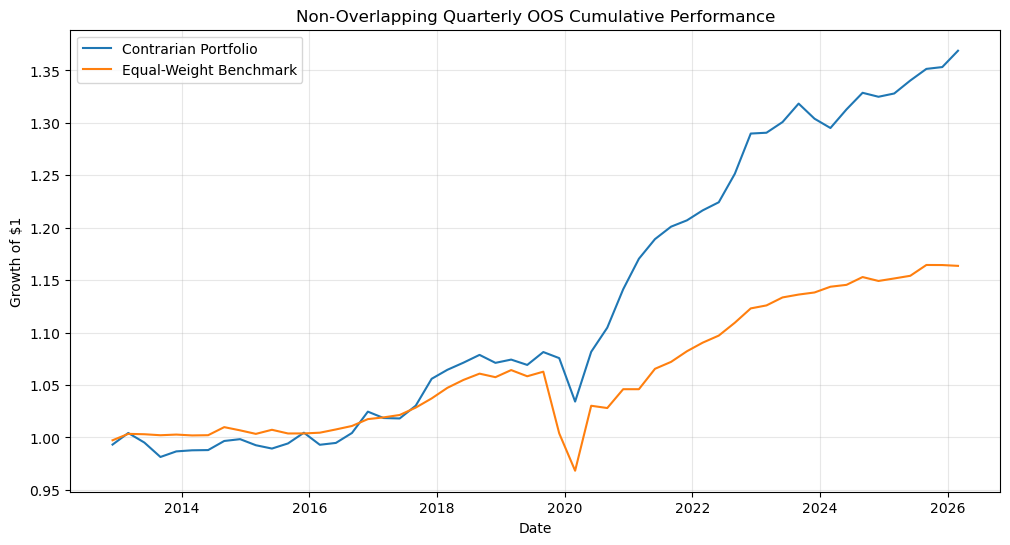

In [155]:
# ============================================================
# NON-OVERLAPPING QUARTERLY OOS CUMULATIVE PERFORMANCE
# ============================================================

# Convert quarterly percentage growth into cumulative indices.
# Each observation now represents a non-overlapping 3-month period.

quarterly_oos_index = pd.DataFrame(index=quarterly_oos.index)

quarterly_oos_index["Portfolio"] = (
    (1 + quarterly_oos["Portfolio"] / 100)
    .cumprod()
)

quarterly_oos_index["Benchmark"] = (
    (1 + quarterly_oos["Benchmark"] / 100)
    .cumprod()
)

print("NON-OVERLAPPING QUARTERLY OOS CUMULATIVE PERFORMANCE")
print("=" * 60)

print(
    "Final portfolio index:",
    round(quarterly_oos_index["Portfolio"].iloc[-1], 4)
)

print(
    "Final benchmark index:",
    round(quarterly_oos_index["Benchmark"].iloc[-1], 4)
)

print(
    "Portfolio cumulative growth:",
    round(
        (quarterly_oos_index["Portfolio"].iloc[-1] - 1) * 100,
        2
    ),
    "%"
)

print(
    "Benchmark cumulative growth:",
    round(
        (quarterly_oos_index["Benchmark"].iloc[-1] - 1) * 100,
        2
    ),
    "%"
)

# Plot the two cumulative indices.
plt.figure(figsize=(12, 6))

plt.plot(
    quarterly_oos_index["Portfolio"],
    label="Contrarian Portfolio"
)

plt.plot(
    quarterly_oos_index["Benchmark"],
    label="Equal-Weight Benchmark"
)

plt.title(
    "Non-Overlapping Quarterly OOS Cumulative Performance"
)

plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

NON-OVERLAPPING QUARTERLY OOS DRAWDOWN
Portfolio maximum drawdown: -4.37 %
Benchmark maximum drawdown: -9.02 %
Portfolio average drawdown: -0.5 %
Benchmark average drawdown: -0.55 %


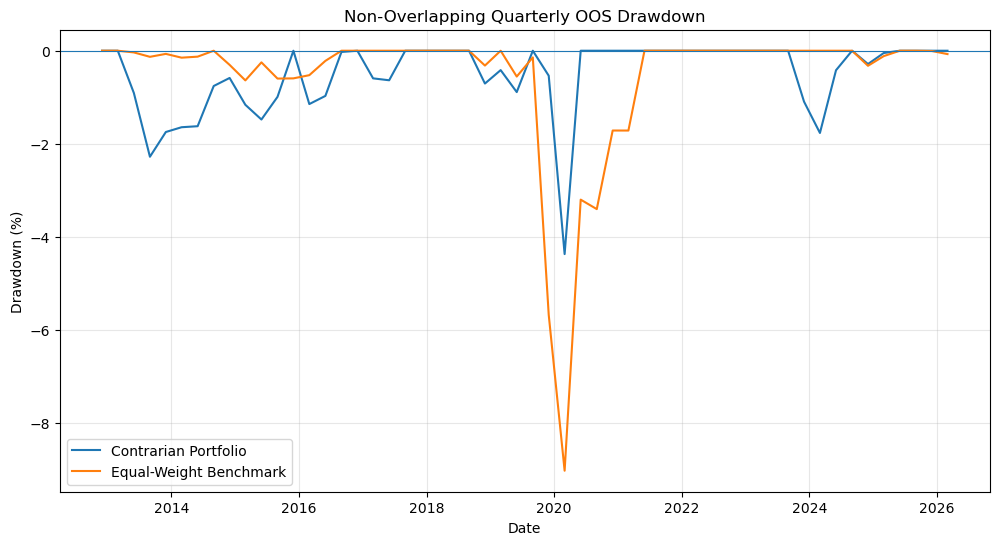

In [156]:
# ============================================================
# NON-OVERLAPPING QUARTERLY OOS DRAWDOWN
# ============================================================

# Calculate running peaks for the quarterly cumulative indices.
quarterly_portfolio_peak = (
    quarterly_oos_index["Portfolio"].cummax()
)

quarterly_benchmark_peak = (
    quarterly_oos_index["Benchmark"].cummax()
)

# Calculate drawdowns from previous peaks.
quarterly_portfolio_drawdown = (
    quarterly_oos_index["Portfolio"]
    / quarterly_portfolio_peak
    - 1
) * 100

quarterly_benchmark_drawdown = (
    quarterly_oos_index["Benchmark"]
    / quarterly_benchmark_peak
    - 1
) * 100

print("NON-OVERLAPPING QUARTERLY OOS DRAWDOWN")
print("=" * 60)

print(
    "Portfolio maximum drawdown:",
    round(quarterly_portfolio_drawdown.min(), 2),
    "%"
)

print(
    "Benchmark maximum drawdown:",
    round(quarterly_benchmark_drawdown.min(), 2),
    "%"
)

print(
    "Portfolio average drawdown:",
    round(quarterly_portfolio_drawdown.mean(), 2),
    "%"
)

print(
    "Benchmark average drawdown:",
    round(quarterly_benchmark_drawdown.mean(), 2),
    "%"
)

# Plot quarterly drawdown paths.
plt.figure(figsize=(12, 6))

plt.plot(
    quarterly_portfolio_drawdown,
    label="Contrarian Portfolio"
)

plt.plot(
    quarterly_benchmark_drawdown,
    label="Equal-Weight Benchmark"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.title(
    "Non-Overlapping Quarterly OOS Drawdown"
)

plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [157]:
# ============================================================
# FINAL OOS VALIDATION SCORECARD
# ============================================================

# Calculate the key OOS statistics from the
# non-overlapping quarterly test.

oos_mean_portfolio = quarterly_oos["Portfolio"].mean()
oos_mean_benchmark = quarterly_oos["Benchmark"].mean()
oos_mean_excess = quarterly_oos["Excess"].mean()

oos_t_stat, oos_p_value = stats.ttest_1samp(
    quarterly_oos["Excess"].dropna(),
    0
)

oos_final_portfolio = (
    quarterly_oos_index["Portfolio"].iloc[-1]
)

oos_final_benchmark = (
    quarterly_oos_index["Benchmark"].iloc[-1]
)

oos_portfolio_cumulative = (
    oos_final_portfolio - 1
) * 100

oos_benchmark_cumulative = (
    oos_final_benchmark - 1
) * 100

oos_max_dd_portfolio = (
    quarterly_portfolio_drawdown.min()
)

oos_max_dd_benchmark = (
    quarterly_benchmark_drawdown.min()
)

oos_scorecard = pd.DataFrame({
    "Metric": [
        "Average 3M Growth",
        "Average Excess Growth",
        "t-statistic",
        "p-value",
        "Cumulative Growth",
        "Maximum Drawdown"
    ],
    "Portfolio": [
        f"{oos_mean_portfolio:.4f}%",
        f"{oos_mean_excess:.4f}%",
        f"{oos_t_stat:.4f}",
        f"{oos_p_value:.4f}",
        f"{oos_portfolio_cumulative:.2f}%",
        f"{oos_max_dd_portfolio:.2f}%"
    ],
    "Benchmark": [
        f"{oos_mean_benchmark:.4f}%",
        "—",
        "—",
        "—",
        f"{oos_benchmark_cumulative:.2f}%",
        f"{oos_max_dd_benchmark:.2f}%"
    ]
})

print("FINAL OUT-OF-SAMPLE VALIDATION SCORECARD")
print("=" * 60)

display(oos_scorecard)

FINAL OUT-OF-SAMPLE VALIDATION SCORECARD


,Metric,Portfolio,Benchmark
0,Average 3M Growth,0.5917%,0.2903%
1,Average Excess Growth,0.3015%,—
2,t-statistic,2.0036,—
3,p-value,0.0502,—
4,Cumulative Growth,36.88%,16.36%
5,Maximum Drawdown,-4.37%,-9.02%


In [158]:
# ============================================================
# FINAL COST-ADJUSTED OOS VALIDATION
# ============================================================

# Use the 0.25% one-way transaction-cost assumption as the
# primary realistic sensitivity case.

primary_cost_rate = 0.0025

quarterly_transaction_cost = (
    oos_turnover_aligned
    * primary_cost_rate
    * 100
)

quarterly_oos["Net_Excess"] = (
    quarterly_oos["Excess"]
    - quarterly_transaction_cost
)

# Test whether net excess performance remains different
# from zero after transaction costs.

net_t_stat, net_p_value = stats.ttest_1samp(
    quarterly_oos["Net_Excess"].dropna(),
    0
)

print("FINAL COST-ADJUSTED OOS VALIDATION")
print("=" * 60)

print(
    "Gross excess growth:",
    round(quarterly_oos["Excess"].mean(), 4),
    "%"
)

print(
    "Average transaction cost:",
    round(quarterly_transaction_cost.mean(), 4),
    "%"
)

print(
    "Net excess growth:",
    round(quarterly_oos["Net_Excess"].mean(), 4),
    "%"
)

print(
    "Net t-statistic:",
    round(net_t_stat, 4)
)

print(
    "Net p-value:",
    round(net_p_value, 4)
)

print(
    "Conclusion:",
    "Positive after costs"
    if quarterly_oos["Net_Excess"].mean() > 0
    else "Negative after costs"
)

FINAL COST-ADJUSTED OOS VALIDATION
Gross excess growth: 0.3015 %
Average transaction cost: 0.2894 %
Net excess growth: 0.0121 %
Net t-statistic: 0.0791
Net p-value: 0.9373
Conclusion: Positive after costs


In [159]:
# ============================================================
# FINAL OOS INTERPRETATION
# ============================================================

net_excess_mean = quarterly_oos["Net_Excess"].mean()

print("FINAL OOS INTERPRETATION")
print("=" * 60)

print(
    f"Gross excess performance: "
    f"{quarterly_oos['Excess'].mean():.4f}% per quarter"
)

print(
    f"Average transaction cost: "
    f"{quarterly_transaction_cost.mean():.4f}% per quarter"
)

print(
    f"Net excess performance: "
    f"{net_excess_mean:.4f}% per quarter"
)

print(
    f"Net p-value: "
    f"{net_p_value:.4f}"
)

if net_excess_mean > 0 and net_p_value >= 0.05:
    interpretation = (
        "Positive economically, but NOT statistically significant "
        "after transaction costs."
    )
elif net_excess_mean > 0 and net_p_value < 0.05:
    interpretation = (
        "Positive and statistically significant after transaction costs."
    )
else:
    interpretation = (
        "Negative after transaction costs."
    )

print("\nInterpretation:")
print(interpretation)

FINAL OOS INTERPRETATION
Gross excess performance: 0.3015% per quarter
Average transaction cost: 0.2894% per quarter
Net excess performance: 0.0121% per quarter
Net p-value: 0.9373

Interpretation:
Positive economically, but NOT statistically significant after transaction costs.


In [160]:
# ============================================================
# FINAL RESEARCH SCORECARD
# ============================================================

final_scorecard = pd.DataFrame({
    "Test": [
        "Gross OOS excess growth",
        "Gross OOS significance",
        "OOS cumulative growth",
        "OOS maximum drawdown",
        "Net OOS excess @ 0.25% cost",
        "Net OOS significance @ 0.25% cost"
    ],
    "Result": [
        f"{quarterly_oos['Excess'].mean():+.4f}% per quarter",
        f"t = {oos_t_stat:.4f}, p = {oos_p_value:.4f}",
        f"{oos_portfolio_cumulative:.2f}% vs "
        f"{oos_benchmark_cumulative:.2f}%",
        f"{oos_max_dd_portfolio:.2f}% vs "
        f"{oos_max_dd_benchmark:.2f}%",
        f"{net_excess_mean:+.4f}% per quarter",
        f"t = {net_t_stat:.4f}, p = {net_p_value:.4f}"
    ],
    "Assessment": [
        "Positive",
        "Borderline",
        "Portfolio ahead",
        "Portfolio lower drawdown",
        "Economically negligible",
        "Not significant"
    ]
})

print("FINAL RESEARCH SCORECARD")
print("=" * 60)

display(final_scorecard)

FINAL RESEARCH SCORECARD


,Test,Result,Assessment
0,Gross OOS excess growth,+0.3015% per quarter,Positive
1,Gross OOS significance,"t = 2.0036, p = 0.0502",Borderline
2,OOS cumulative growth,36.88% vs 16.36%,Portfolio ahead
3,OOS maximum drawdown,-4.37% vs -9.02%,Portfolio lower drawdown
4,Net OOS excess @ 0.25% cost,+0.0121% per quarter,Economically negligible
5,Net OOS significance @ 0.25% cost,"t = 0.0791, p = 0.9373",Not significant


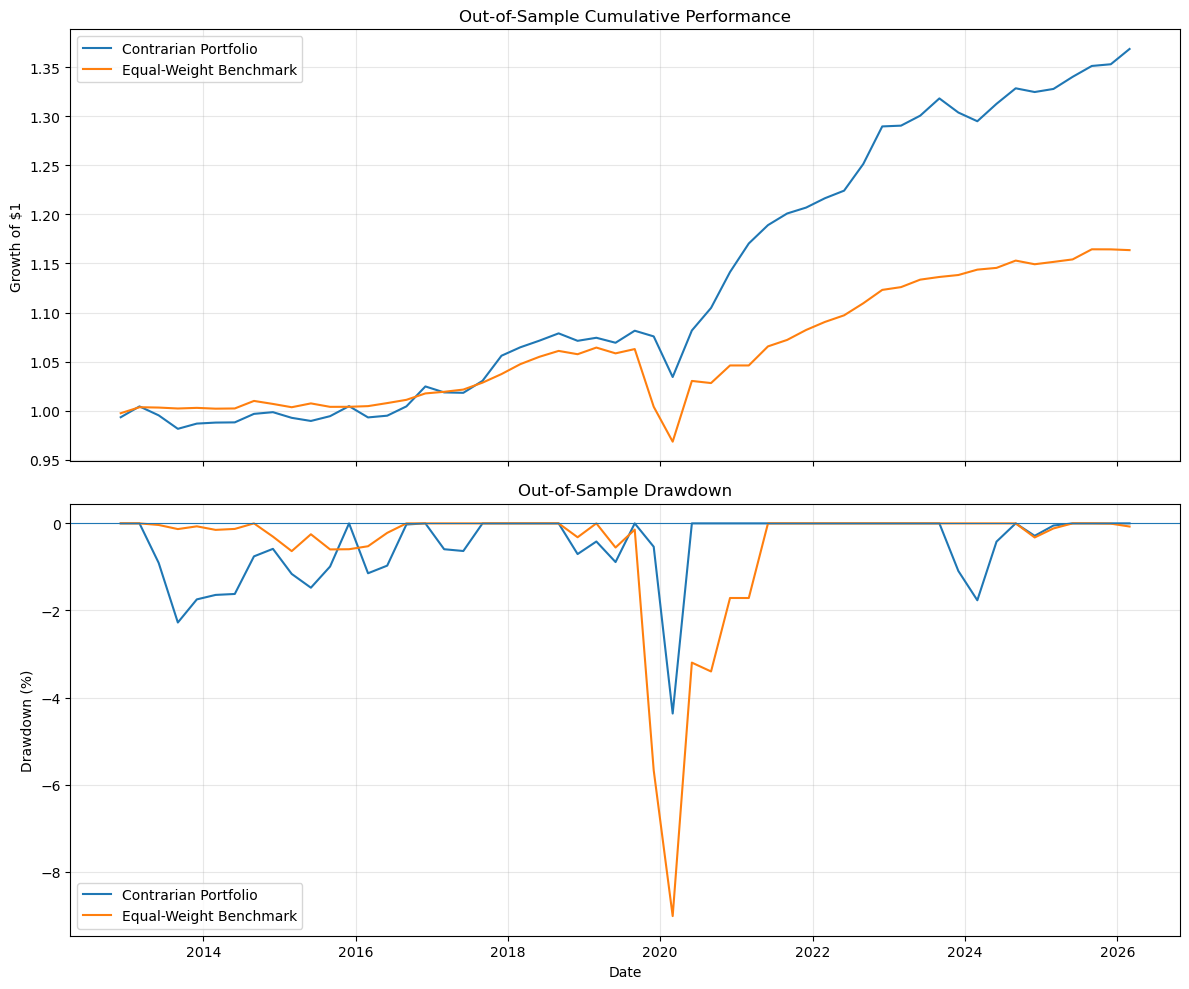

In [161]:
# ============================================================
# FINAL OOS PERFORMANCE DASHBOARD
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 10),
    sharex=True
)

# ------------------------------------------------------------
# Panel 1: Cumulative performance
# ------------------------------------------------------------

axes[0].plot(
    quarterly_oos_index["Portfolio"],
    label="Contrarian Portfolio"
)

axes[0].plot(
    quarterly_oos_index["Benchmark"],
    label="Equal-Weight Benchmark"
)

axes[0].set_title(
    "Out-of-Sample Cumulative Performance"
)

axes[0].set_ylabel(
    "Growth of $1"
)

axes[0].legend()
axes[0].grid(
    True,
    alpha=0.3
)

# ------------------------------------------------------------
# Panel 2: Drawdown
# ------------------------------------------------------------

axes[1].plot(
    quarterly_portfolio_drawdown,
    label="Contrarian Portfolio"
)

axes[1].plot(
    quarterly_benchmark_drawdown,
    label="Equal-Weight Benchmark"
)

axes[1].axhline(
    0,
    linewidth=0.8
)

axes[1].set_title(
    "Out-of-Sample Drawdown"
)

axes[1].set_xlabel(
    "Date"
)

axes[1].set_ylabel(
    "Drawdown (%)"
)

axes[1].legend()
axes[1].grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [162]:
# ============================================================
# FINAL RESEARCH CONCLUSION
# ============================================================

print("FINAL RESEARCH CONCLUSION")
print("=" * 60)

print(
    "The employment-based contrarian strategy generated a "
    f"gross OOS excess of {quarterly_oos['Excess'].mean():.4f}% "
    "per quarter."
)

print(
    f"The gross result was borderline statistically significant "
    f"(t = {oos_t_stat:.4f}, p = {oos_p_value:.4f})."
)

print(
    f"Across the non-overlapping OOS sample, the portfolio gained "
    f"{oos_portfolio_cumulative:.2f}% versus "
    f"{oos_benchmark_cumulative:.2f}% for the benchmark."
)

print(
    f"Maximum drawdown was {oos_max_dd_portfolio:.2f}% "
    f"for the portfolio versus "
    f"{oos_max_dd_benchmark:.2f}% for the benchmark."
)

print(
    f"However, after a 0.25% one-way transaction-cost assumption, "
    f"net excess performance fell to "
    f"{net_excess_mean:.4f}% per quarter "
    f"(p = {net_p_value:.4f})."
)

print("\nOVERALL CONCLUSION:")
print(
    "The employment signal shows promising gross predictive value, "
    "but the edge is too small to remain statistically compelling "
    "after realistic trading costs."
)

FINAL RESEARCH CONCLUSION
The employment-based contrarian strategy generated a gross OOS excess of 0.3015% per quarter.
The gross result was borderline statistically significant (t = 2.0036, p = 0.0502).
Across the non-overlapping OOS sample, the portfolio gained 36.88% versus 16.36% for the benchmark.
Maximum drawdown was -4.37% for the portfolio versus -9.02% for the benchmark.
However, after a 0.25% one-way transaction-cost assumption, net excess performance fell to 0.0121% per quarter (p = 0.9373).

OVERALL CONCLUSION:
The employment signal shows promising gross predictive value, but the edge is too small to remain statistically compelling after realistic trading costs.


FINAL RESEARCH CONCLUSION
============================================================
The employment-based contrarian strategy generated a gross OOS excess of 0.3015% per quarter.
The gross result was borderline statistically significant (t = 2.0036, p = 0.0502).
Across the non-overlapping OOS sample, the portfolio gained 36.88% versus 16.36% for the benchmark.
Maximum drawdown was -4.37% for the portfolio versus -9.02% for the benchmark.
However, after a 0.25% one-way transaction-cost assumption, net excess performance fell to 0.0121% per quarter (p = 0.9373).

OVERALL CONCLUSION:
The employment signal shows promising gross predictive value, but the edge is too small to remain statistically compelling after realistic trading costs.


In [164]:
# ============================================================
# PORTFOLIO TAKEAWAY
# ============================================================

print("PORTFOLIO TAKEAWAY")
print("=" * 60)

print(
    "Employment dynamics contain useful information about "
    "Canadian industry rotation."
)

print(
    "The contrarian signal produced a positive gross "
    "out-of-sample result, with higher cumulative employment "
    "growth and lower maximum drawdown than the benchmark."
)

print(
    "However, the gross advantage was only borderline "
    "statistically significant."
)

print(
    "At a 0.25% one-way transaction-cost assumption, the "
    "remaining excess performance became economically negligible "
    "and statistically insignificant."
)

print(
    "\nFinal interpretation:"
)

print(
    "The research supports employment dynamics as a promising "
    "industry-rotation signal, but not as a standalone "
    "cost-effective trading strategy."
)

print(
    "\nNote:"
)

print(
    "Portfolio performance in this study represents simulated "
    "employment-growth outcomes rather than realized stock-market "
    "returns."
)

PORTFOLIO TAKEAWAY
Employment dynamics contain useful information about Canadian industry rotation.
The contrarian signal produced a positive gross out-of-sample result, with higher cumulative employment growth and lower maximum drawdown than the benchmark.
However, the gross advantage was only borderline statistically significant.
At a 0.25% one-way transaction-cost assumption, the remaining excess performance became economically negligible and statistically insignificant.

Final interpretation:
The research supports employment dynamics as a promising industry-rotation signal, but not as a standalone cost-effective trading strategy.

Note:
Portfolio performance in this study represents simulated employment-growth outcomes rather than realized stock-market returns.
